# Analiza datelor de Zbor

**Source:** [Bureau of Transportation Statistics (BTS)](https://www.transtats.bts.gov/DL_SelectFields.asp?Table_ID=236)  
**Dataset:** On-Time Marketing Carrier Performance - 2025

**100% real data** colectate de guvernul federal al SUA de la toate companiile aeriene comerciale.

## Descrierea Coloanelor

| Coloana | Tip | Descriere |
|---|---|---|
| `YEAR` | Numeric | Anul zborului |
| `MONTH` | Numeric | Luna zborului (1-12) |
| `DAY_OF_MONTH` | Numeric | Ziua din luna (1-31) |
| `DAY_OF_WEEK` | Numeric | Ziua din saptamana (1=Luni, 7=Duminica) |
| `MKT_UNIQUE_CARRIER` | Categoric | Codul companiei aeriene (ex: AA, DL, UA) |
| `ORIGIN` | Categoric | Codul aeroportului de plecare (ex: JFK, LAX) |
| `ORIGIN_CITY_NAME` | Categoric | Numele orasului de plecare |
| `DEST` | Categoric | Codul aeroportului de destinatie |
| `DEST_CITY_NAME` | Categoric | Numele orasului de destinatie |
| `CRS_DEP_TIME` | Numeric | Ora programata de plecare (format HHMM) |
| `DEP_TIME` | Numeric | Ora reala de plecare (format HHMM) |
| `DEP_DELAY` | Numeric | Intarziere la plecare in minute (negativ = devans) |
| `DEP_DEL15` | Binar | Zborul a intarziat la plecare >15 min? (1=Da, 0=Nu) |
| `CRS_ARR_TIME` | Numeric | Ora programata de sosire (format HHMM) |
| `ARR_TIME` | Numeric | Ora reala de sosire (format HHMM) |
| `ARR_DELAY` | Numeric | Intarziere la sosire in minute (negativ = devans) |
| `ARR_DEL15` | Binar | Zborul a intarziat la sosire >15 min? (1=Da, 0=Nu) |
| `CANCELLED` | Binar | Zborul a fost anulat? (1=Da, 0=Nu) |
| `CANCELLATION_CODE` | Categoric | Motivul anularii: A=Companie, B=Vreme, C=NAS, D=Securitate |
| `DIVERTED` | Binar | Zborul a fost deviat pe alt aeroport? (1=Da, 0=Nu) |
| `ACTUAL_ELAPSED_TIME` | Numeric | Durata reala a zborului (minute) |
| `DISTANCE` | Numeric | Distanta rutei (mile) |
| `CARRIER_DELAY` | Numeric | Minute de intarziere din vina companiei |
| `WEATHER_DELAY` | Numeric | Minute de intarziere din cauza vremii |
| `NAS_DELAY` | Numeric | Minute de intarziere din cauza sistemului national de trafic |
| `SECURITY_DELAY` | Numeric | Minute de intarziere din cauza securitatii |

## 1. Importuri si incarcarea datelor

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

In [3]:
import pandas as pd
import glob

# Ia toate fisierele CSV din folder
files = glob.glob('*.csv')
print(f'Found {len(files)} CSV files:')
for f in files:
    print(f'  - {f}')

df = pd.concat([pd.read_csv(f, low_memory=False) for f in files], ignore_index=True)

print(f'\nTotal rows after merging: {df.shape[0]:,}')
print(f'Columns: {df.shape[1]}')
print(f'Months covered: {[int(m) for m in sorted(df["MONTH"].unique())]}')
print(f'Year(s): {[int(y) for y in sorted(df["YEAR"].unique())]}')
print(f'Airlines: {df["MKT_UNIQUE_CARRIER"].nunique()}')
print(f'Origin airports: {df["ORIGIN"].nunique()}')
print(f'Dest airports: {df["DEST"].nunique()}')

Found 12 CSV files:
  - T_ONTIME_MARKETING.csv
  - T_ONTIME_MARKETING_APR.csv
  - T_ONTIME_MARKETING_AUG.csv
  - T_ONTIME_MARKETING_FEB.csv
  - T_ONTIME_MARKETING_IAN.csv
  - T_ONTIME_MARKETING_IUL.csv
  - T_ONTIME_MARKETING_IUN.csv
  - T_ONTIME_MARKETING_MAR.csv
  - T_ONTIME_MARKETING_MAY.csv
  - T_ONTIME_MARKETING_NOV.csv
  - T_ONTIME_MARKETING_OCT.csv
  - T_ONTIME_MARKETING_SEPT.csv

Total rows after merging: 7,736,770
Columns: 26
Months covered: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]
Year(s): [2025]
Airlines: 10
Origin airports: 364
Dest airports: 364


## 2. Structura si calitatea datelor

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7736770 entries, 0 to 7736769
Data columns (total 26 columns):
 #   Column               Dtype  
---  ------               -----  
 0   YEAR                 int64  
 1   MONTH                int64  
 2   DAY_OF_MONTH         int64  
 3   DAY_OF_WEEK          int64  
 4   MKT_UNIQUE_CARRIER   object 
 5   ORIGIN               object 
 6   ORIGIN_CITY_NAME     object 
 7   DEST                 object 
 8   DEST_CITY_NAME       object 
 9   CRS_DEP_TIME         int64  
 10  DEP_TIME             float64
 11  DEP_DELAY            float64
 12  DEP_DEL15            float64
 13  CRS_ARR_TIME         int64  
 14  ARR_TIME             float64
 15  ARR_DELAY            float64
 16  ARR_DEL15            float64
 17  CANCELLED            float64
 18  CANCELLATION_CODE    object 
 19  DIVERTED             float64
 20  ACTUAL_ELAPSED_TIME  float64
 21  DISTANCE             float64
 22  CARRIER_DELAY        float64
 23  WEATHER_DELAY        float64
 24

In [23]:
df.tail()

,YEAR,MONTH,DAY_OF_MONTH,DAY_OF_WEEK,MKT_UNIQUE_CARRIER,ORIGIN,ORIGIN_CITY_NAME,DEST,DEST_CITY_NAME,CRS_DEP_TIME,...,ARR_DEL15,CANCELLED,CANCELLATION_CODE,DIVERTED,ACTUAL_ELAPSED_TIME,DISTANCE,CARRIER_DELAY,WEATHER_DELAY,NAS_DELAY,SECURITY_DELAY
7736765,2025,9,30,2,WN,TUS,"Tucson, AZ",SAN,"San Diego, CA",800,...,0.0,0.0,NaN,0.0,72.0,367.0,NaN,NaN,NaN,NaN
7736766,2025,9,30,2,WN,VPS,"Valparaiso, FL",BNA,"Nashville, TN",700,...,0.0,0.0,NaN,0.0,84.0,389.0,NaN,NaN,NaN,NaN
7736767,2025,9,30,2,WN,VPS,"Valparaiso, FL",BNA,"Nashville, TN",1400,...,1.0,0.0,NaN,0.0,107.0,389.0,0.0,0.0,20.0,0.0
7736768,2025,9,30,2,WN,VPS,"Valparaiso, FL",BWI,"Baltimore, MD",1035,...,0.0,0.0,NaN,0.0,131.0,819.0,NaN,NaN,NaN,NaN
7736769,2025,9,30,2,WN,VPS,"Valparaiso, FL",DAL,"Dallas, TX",1240,...,0.0,0.0,NaN,0.0,119.0,630.0,NaN,NaN,NaN,NaN


In [22]:
df.head()

,YEAR,MONTH,DAY_OF_MONTH,DAY_OF_WEEK,MKT_UNIQUE_CARRIER,ORIGIN,ORIGIN_CITY_NAME,DEST,DEST_CITY_NAME,CRS_DEP_TIME,...,ARR_DEL15,CANCELLED,CANCELLATION_CODE,DIVERTED,ACTUAL_ELAPSED_TIME,DISTANCE,CARRIER_DELAY,WEATHER_DELAY,NAS_DELAY,SECURITY_DELAY
0,2025,12,1,1,AA,ABE,"Allentown/Bethlehem/Easton, PA",CLT,"Charlotte, NC",616,...,0.0,0.0,NaN,0.0,103.0,481.0,NaN,NaN,NaN,NaN
1,2025,12,1,1,AA,ABE,"Allentown/Bethlehem/Easton, PA",CLT,"Charlotte, NC",1400,...,1.0,0.0,NaN,0.0,99.0,481.0,23.0,0.0,0.0,0.0
2,2025,12,1,1,AA,ABE,"Allentown/Bethlehem/Easton, PA",CLT,"Charlotte, NC",1710,...,1.0,0.0,NaN,0.0,111.0,481.0,1.0,0.0,0.0,0.0
3,2025,12,1,1,AA,ABI,"Abilene, TX",DFW,"Dallas/Fort Worth, TX",628,...,0.0,0.0,NaN,0.0,50.0,158.0,NaN,NaN,NaN,NaN
4,2025,12,1,1,AA,ABI,"Abilene, TX",DFW,"Dallas/Fort Worth, TX",736,...,0.0,0.0,NaN,0.0,68.0,158.0,NaN,NaN,NaN,NaN


In [26]:
df.describe().round(2)

,YEAR,MONTH,DAY_OF_MONTH,DAY_OF_WEEK,CRS_DEP_TIME,DEP_TIME,DEP_DELAY,DEP_DEL15,CRS_ARR_TIME,ARR_TIME,ARR_DELAY,ARR_DEL15,CANCELLED,DIVERTED,ACTUAL_ELAPSED_TIME,DISTANCE,CARRIER_DELAY,WEATHER_DELAY,NAS_DELAY,SECURITY_DELAY
count,7736770.0,7736770.00,7736770.00,7736770.00,7736770.00,7624028.00,7623605.00,7623605.00,7736770.00,7616702.00,7597495.00,7597495.00,7736770.00,7736770.00,7597495.00,7736770.00,1685334.00,1685334.00,1685334.00,1685334.00
mean,2025.0,6.57,15.75,4.00,1324.57,1328.88,13.52,0.22,1491.58,1460.36,8.53,0.22,0.02,0.00,139.70,803.89,23.56,4.77,15.96,0.09
std,0.0,3.40,8.78,2.01,489.43,507.89,58.33,0.41,514.38,544.08,60.53,0.42,0.12,0.05,71.81,591.23,74.68,36.03,36.81,3.21
min,2025.0,1.00,1.00,1.00,1.00,1.00,-115.00,0.00,1.00,1.00,-128.00,0.00,0.00,0.00,15.00,31.00,0.00,0.00,0.00,0.00
25%,2025.0,4.00,8.00,2.00,907.00,908.00,-6.00,0.00,1105.00,1045.00,-16.00,0.00,0.00,0.00,87.00,372.00,0.00,0.00,0.00,0.00
50%,2025.0,7.00,16.00,4.00,1317.00,1322.00,-2.00,0.00,1516.00,1501.00,-6.00,0.00,0.00,0.00,123.00,646.00,2.00,0.00,1.00,0.00
75%,2025.0,10.00,23.00,6.00,1732.00,1743.00,10.00,0.00,1922.00,1917.00,11.00,0.00,0.00,0.00,171.00,1041.00,20.00,0.00,19.00,0.00
max,2025.0,12.00,31.00,7.00,2400.00,2400.00,5923.00,1.00,2400.00,2400.00,5907.00,1.00,1.00,1.00,965.00,5095.00,5875.00,2394.00,1706.00,990.00


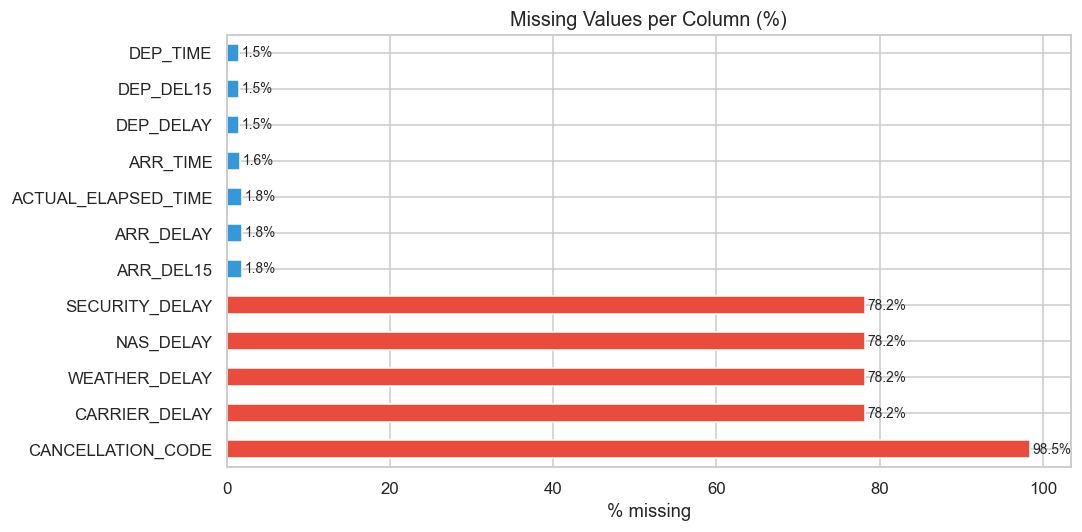

In [27]:
null_pct = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)
null_pct = null_pct[null_pct > 0]

fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#e74c3c' if x > 50 else '#f39c12' if x > 20 else '#3498db' for x in null_pct]
null_pct.plot(kind='barh', ax=ax, color=colors)
ax.set_title('Valori Lipsa per Coloana (%)', fontsize=13, fontweight='bold')
ax.set_xlabel('% lipsa')
for i, v in enumerate(null_pct):
    ax.text(v + 0.3, i, f'{v:.1f}%', va='center', fontsize=9)
plt.tight_layout()
plt.show()

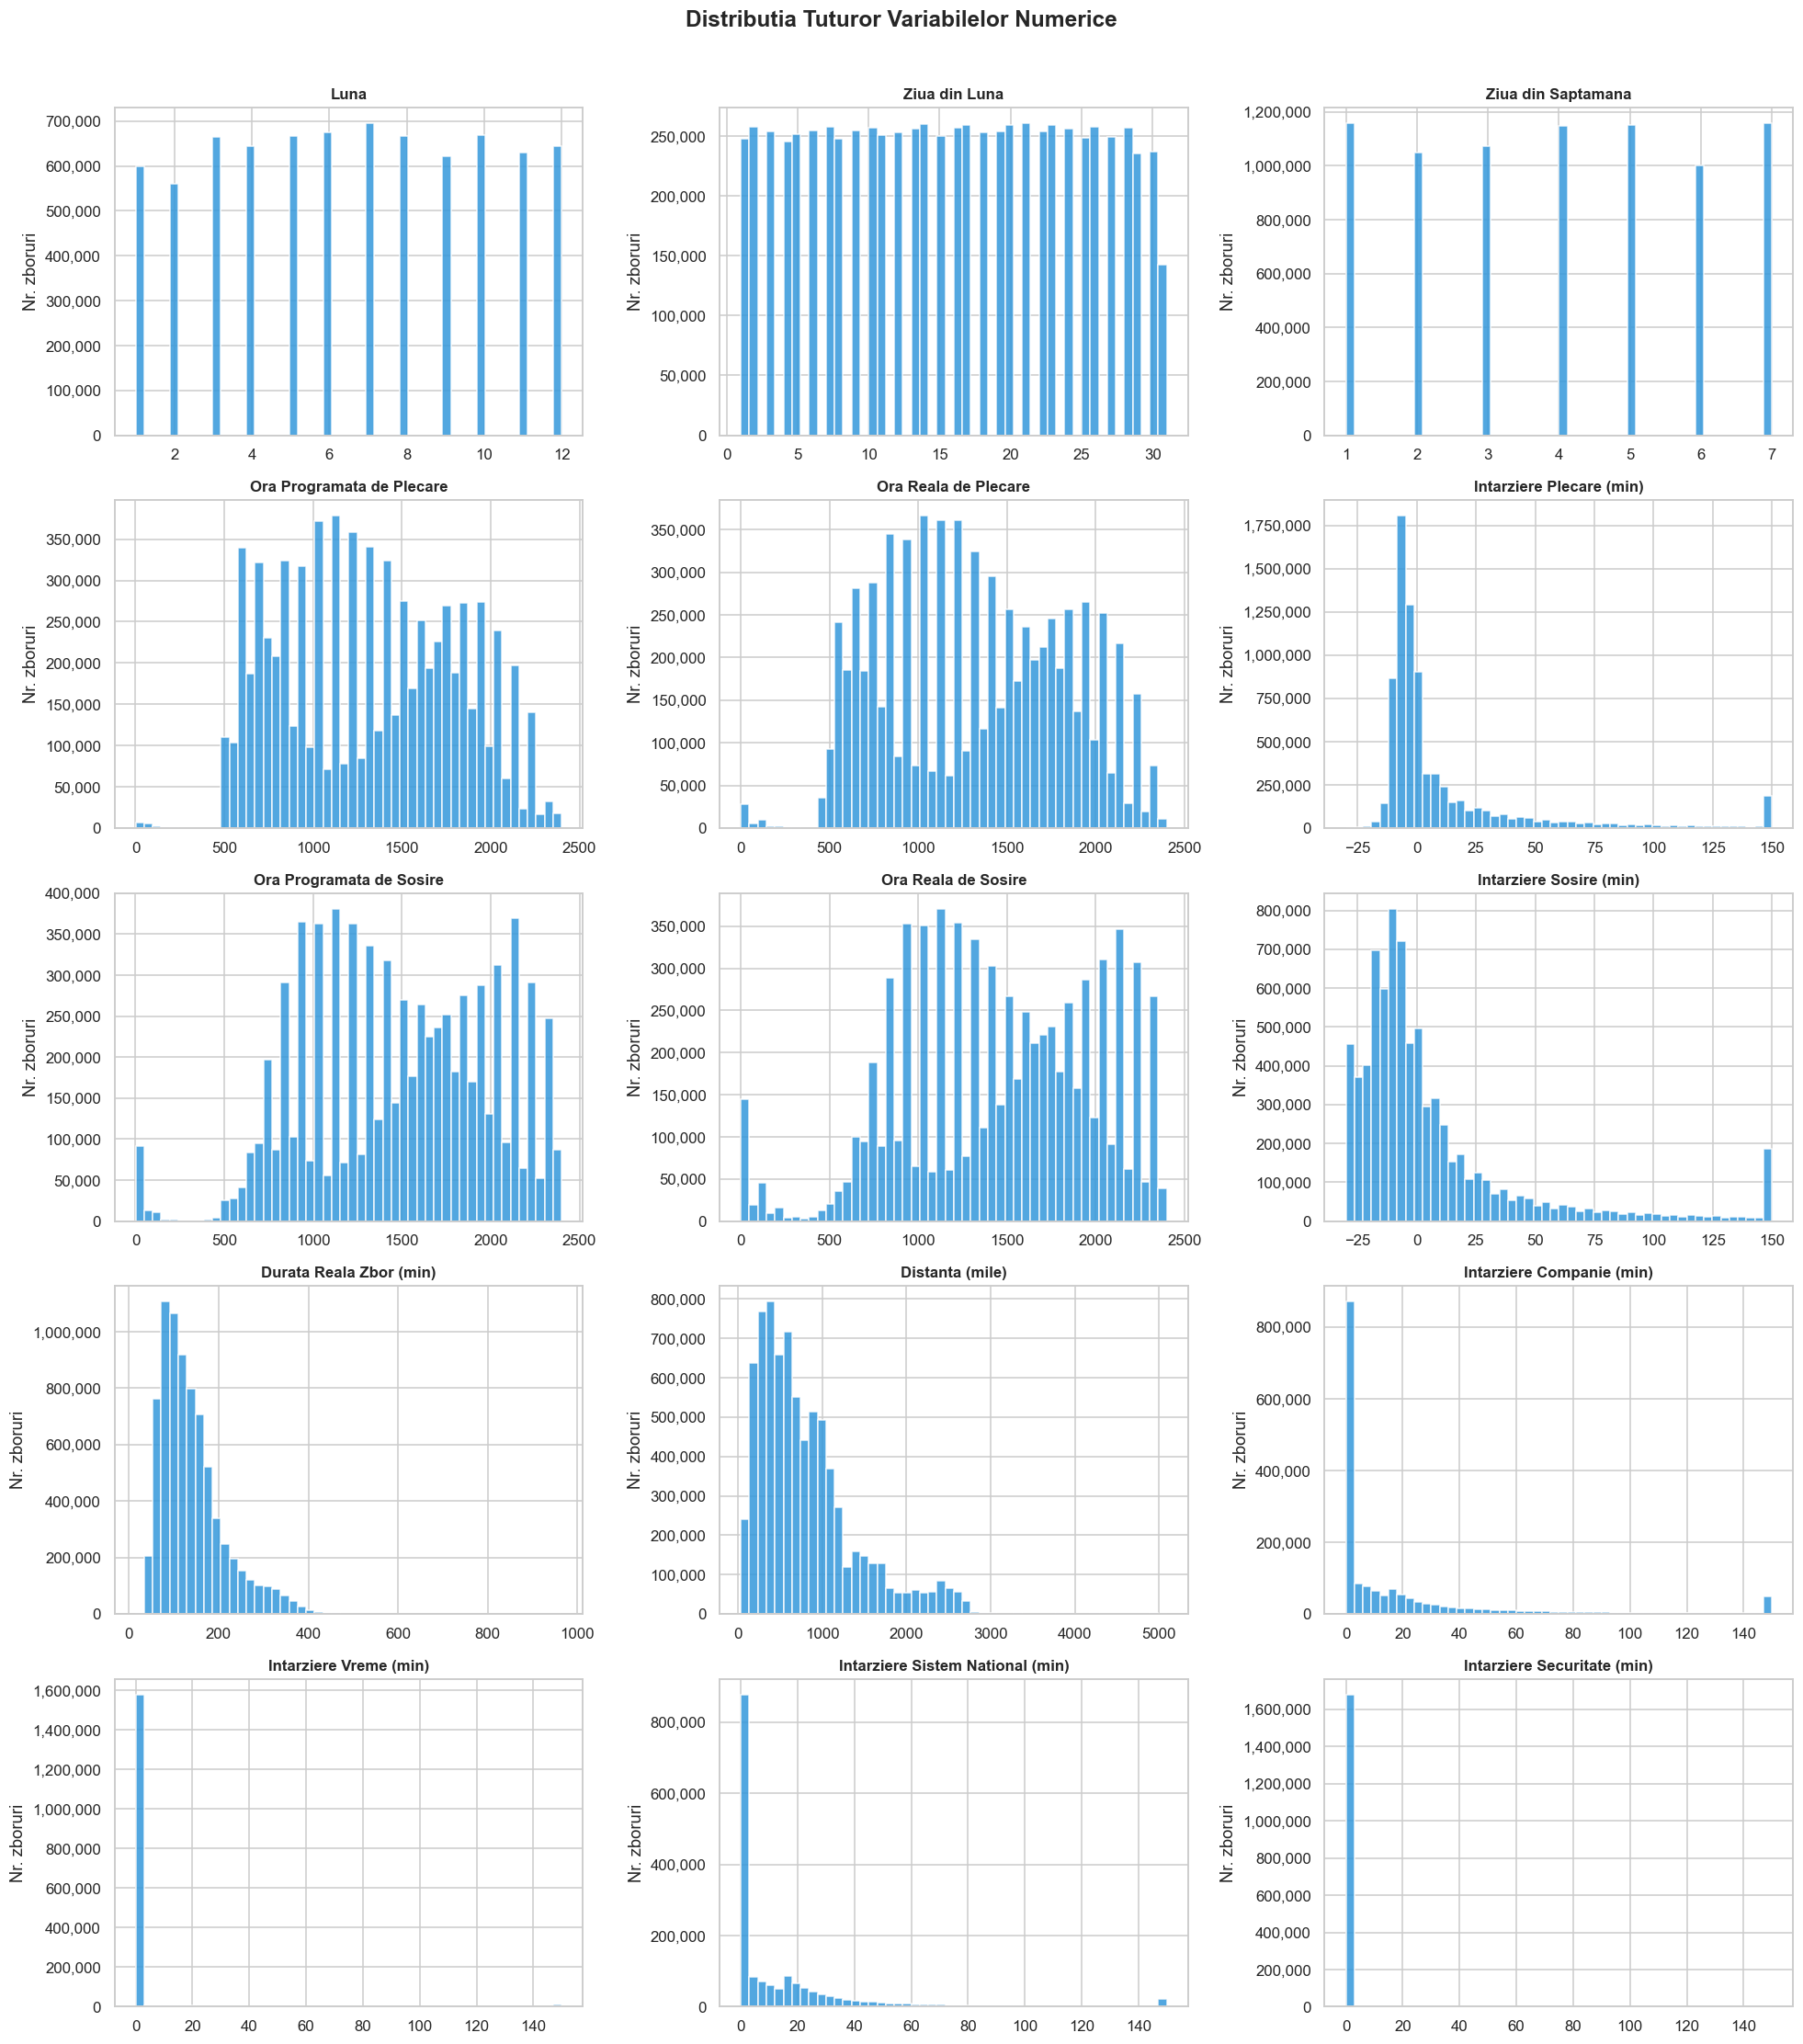

In [114]:
numeric_cols = {
    'MONTH': 'Luna',
    'DAY_OF_MONTH': 'Ziua din Luna',
    'DAY_OF_WEEK': 'Ziua din Saptamana',
    'CRS_DEP_TIME': 'Ora Programata de Plecare',
    'DEP_TIME': 'Ora Reala de Plecare',
    'DEP_DELAY': 'Intarziere Plecare (min)',
    'CRS_ARR_TIME': 'Ora Programata de Sosire',
    'ARR_TIME': 'Ora Reala de Sosire',
    'ARR_DELAY': 'Intarziere Sosire (min)',
    'ACTUAL_ELAPSED_TIME': 'Durata Reala Zbor (min)',
    'DISTANCE': 'Distanta (mile)',
    'CARRIER_DELAY': 'Intarziere Companie (min)',
    'WEATHER_DELAY': 'Intarziere Vreme (min)',
    'NAS_DELAY': 'Intarziere Sistem National (min)',
    'SECURITY_DELAY': 'Intarziere Securitate (min)',
}
numeric_cols = {k: v for k, v in numeric_cols.items() if k in df.columns}

ncols = 3
nrows = -(-len(numeric_cols) // ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(18, nrows * 4))
axes = axes.flatten()

clip_cols = ['DEP_DELAY', 'ARR_DELAY', 'CARRIER_DELAY', 'WEATHER_DELAY', 'NAS_DELAY', 'SECURITY_DELAY']

for i, (col, title) in enumerate(numeric_cols.items()):
    data = df[col].dropna()
    if col in clip_cols:
        data = data.clip(-30, 150)
    axes[i].hist(data, bins=50, color='#3498db', edgecolor='white', alpha=0.85)
    axes[i].set_title(title, fontsize=11, fontweight='bold')
    axes[i].set_ylabel('Nr. zboruri')
    axes[i].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle('Distributia Tuturor Variabilelor Numerice',
             fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## 3. Distributia intarzieriilor


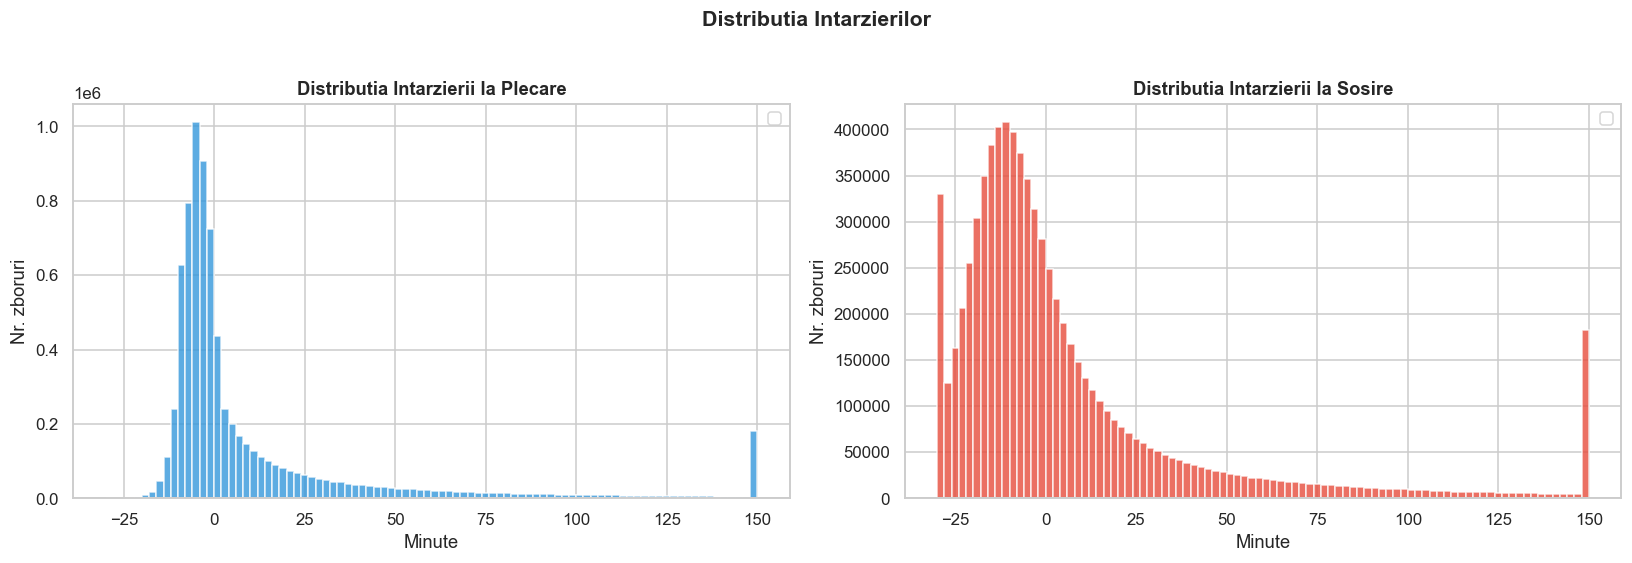

Sosiri mai devreme: 61.1%
Intarziate >15 min: 21.5%
Intarziate >60 min: 8.1%
Intarziate >3 ore:  1.64%


In [122]:
df_flown = df[df['CANCELLED'] == 0].copy()
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Intarziere plecare
dep = df_flown['DEP_DELAY'].dropna()
axes[0].hist(dep.clip(-30, 150), bins=90, color='#3498db', alpha=0.8, edgecolor='white')
axes[0].set_title('Distributia Intarzierii la Plecare', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Minute')
axes[0].set_ylabel('Nr. zboruri')
axes[0].legend()

# Intarziere sosire
arr = df_flown['ARR_DELAY'].dropna()
axes[1].hist(arr.clip(-30, 150), bins=90, color='#e74c3c', alpha=0.8, edgecolor='white')
axes[1].set_title('Distributia Intarzierii la Sosire', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Minute')
axes[1].set_ylabel('Nr. zboruri')
axes[1].legend()

plt.suptitle('Distributia Intarzierilor', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(f'Sosiri mai devreme: {(arr < 0).mean()*100:.1f}%')
print(f'Intarziate >15 min: {(arr > 15).mean()*100:.1f}%')
print(f'Intarziate >60 min: {(arr > 60).mean()*100:.1f}%')
print(f'Intarziate >3 ore:  {(arr > 180).mean()*100:.2f}%')

## 4. Performanta companiilor aeriene


In [119]:
carrier_stats = df_flown.groupby('MKT_UNIQUE_CARRIER').agg(
    total_zboruri=('ARR_DELAY', 'count'),
    intarziere_medie_sosire=('ARR_DELAY', 'mean'),
    intarziere_mediana_sosire=('ARR_DELAY', 'median'),
    pct_intarziate=('ARR_DEL15', 'mean'),
    intarziere_medie_plecare=('DEP_DELAY', 'mean'),
).round(2)

cancel_stats = df.groupby('MKT_UNIQUE_CARRIER')['CANCELLED'].mean().rename('pct_anulate')
carrier_stats = carrier_stats.join(cancel_stats).sort_values('intarziere_medie_sosire')

print(carrier_stats.to_string())

                    total_zboruri  intarziere_medie_sosire  intarziere_mediana_sosire  pct_intarziate  intarziere_medie_plecare  pct_anulate
MKT_UNIQUE_CARRIER                                                                                                                          
AS                         415810                     4.80                       -4.0            0.22                      7.76     0.013029
DL                        1600753                     5.67                       -8.0            0.19                     11.19     0.013650
WN                        1376837                     6.05                       -5.0            0.21                     12.81     0.008477
NK                         191191                     6.60                       -8.0            0.21                     12.84     0.015048
HA                          79335                     6.78                        0.0            0.17                      7.84     0.008241
UA           

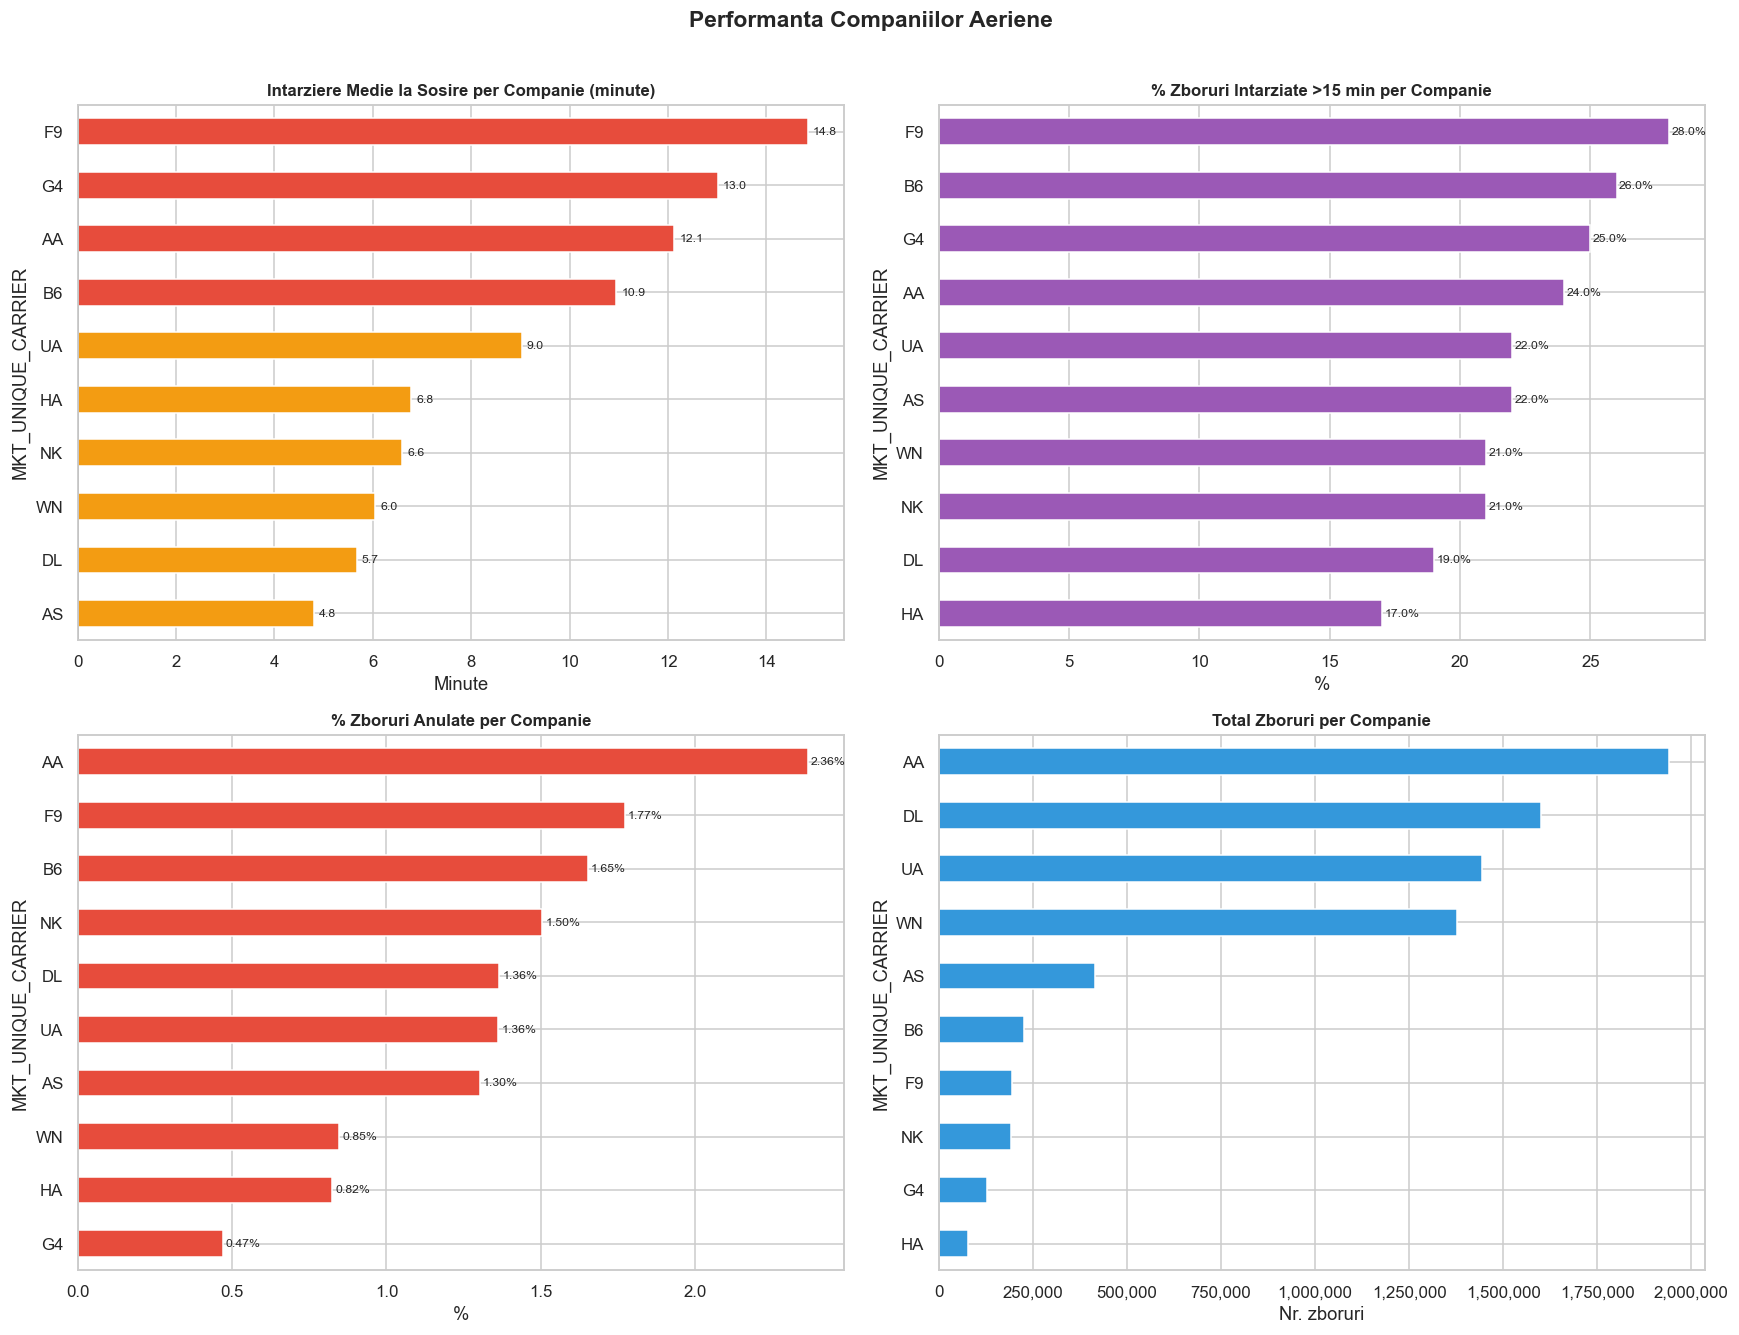

In [121]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Intarziere medie sosire
colors_c = ['#2ecc71' if x < 0 else '#e74c3c' if x > 10 else '#f39c12'
            for x in carrier_stats['intarziere_medie_sosire']]
carrier_stats['intarziere_medie_sosire'].plot(kind='barh', ax=axes[0,0], color=colors_c)
axes[0,0].axvline(0, color='black', lw=1)
axes[0,0].set_title('Intarziere Medie la Sosire per Companie (minute)', fontsize=11, fontweight='bold')
axes[0,0].set_xlabel('Minute')
for i, v in enumerate(carrier_stats['intarziere_medie_sosire']):
    axes[0,0].text(v + 0.1, i, f'{v:.1f}', va='center', fontsize=8)

# % intarziate >15min
pct_d = carrier_stats['pct_intarziate'].sort_values() * 100
pct_d.plot(kind='barh', ax=axes[0,1], color='#9b59b6')
axes[0,1].set_title('% Zboruri Intarziate >15 min per Companie', fontsize=11, fontweight='bold')
axes[0,1].set_xlabel('%')
for i, v in enumerate(pct_d):
    axes[0,1].text(v + 0.1, i, f'{v:.1f}%', va='center', fontsize=8)

# % anulate
pct_c = carrier_stats['pct_anulate'].sort_values() * 100
pct_c.plot(kind='barh', ax=axes[1,0], color='#e74c3c')
axes[1,0].set_title('% Zboruri Anulate per Companie', fontsize=11, fontweight='bold')
axes[1,0].set_xlabel('%')
for i, v in enumerate(pct_c):
    axes[1,0].text(v + 0.01, i, f'{v:.2f}%', va='center', fontsize=8)

# Total zboruri
tf = carrier_stats['total_zboruri'].sort_values()
tf.plot(kind='barh', ax=axes[1,1], color='#3498db')
axes[1,1].set_title('Total Zboruri per Companie', fontsize=11, fontweight='bold')
axes[1,1].set_xlabel('Nr. zboruri')
axes[1,1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

plt.suptitle('Performanta Companiilor Aeriene', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## 5. Performanta aeroporturilor

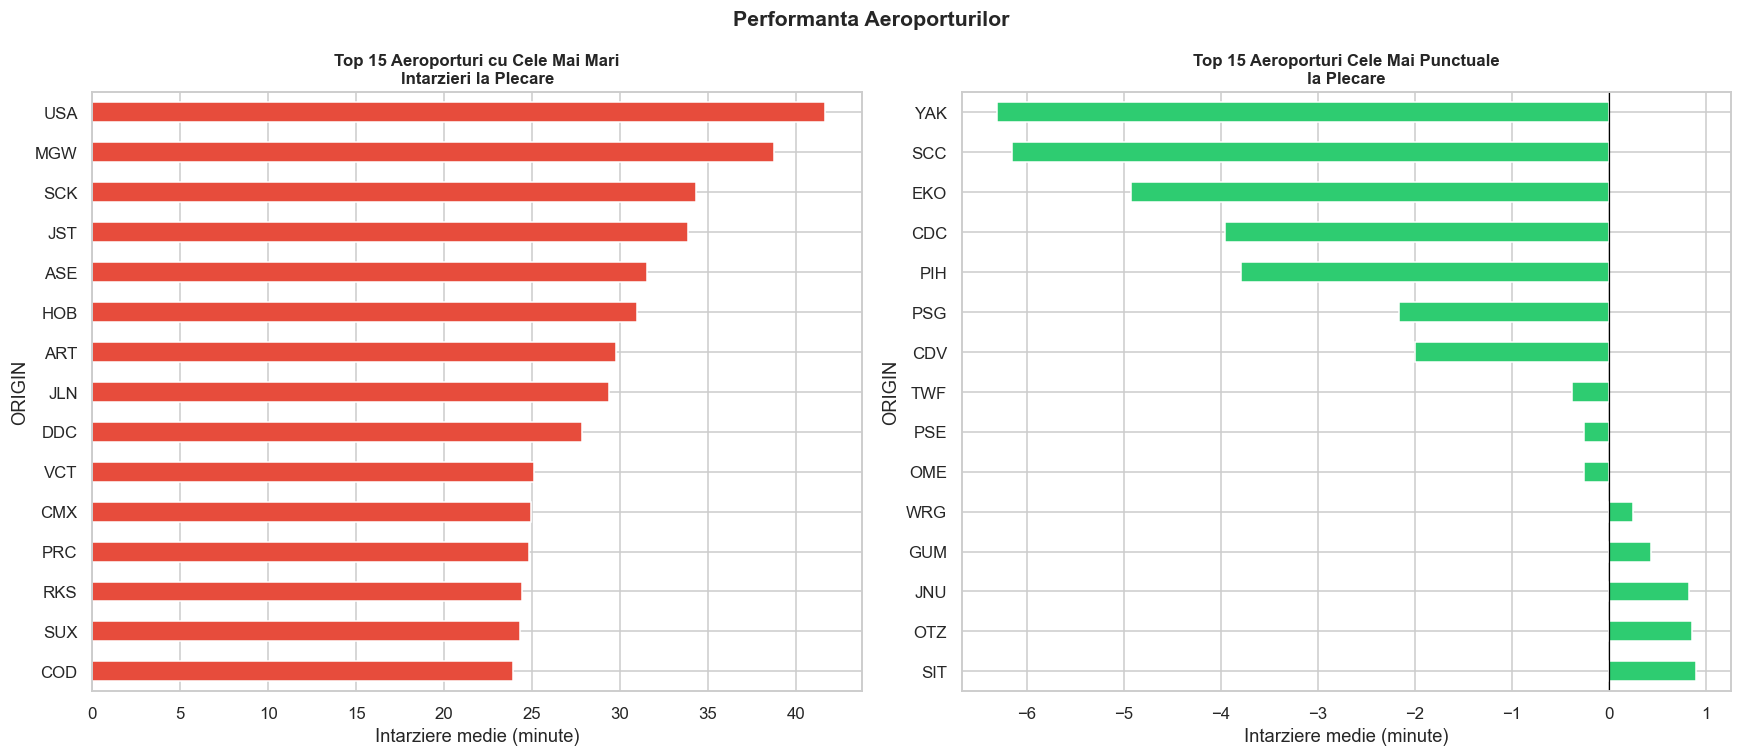

In [124]:
airport_stats = df_flown.groupby('ORIGIN').agg(
    total_plecari=('DEP_DELAY', 'count'),
    intarziere_medie_plecare=('DEP_DELAY', 'mean'),
    pct_intarziate=('DEP_DEL15', 'mean'),
).round(2)

# Doar aeroporturi cu volum semnificativ
airport_stats = airport_stats[airport_stats['total_plecari'] > 500]

top_worst = airport_stats.nlargest(15, 'intarziere_medie_plecare')
top_best  = airport_stats.nsmallest(15, 'intarziere_medie_plecare')

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

top_worst['intarziere_medie_plecare'].sort_values().plot(kind='barh', ax=axes[0], color='#e74c3c', edgecolor='white')
axes[0].set_title('Top 15 Aeroporturi cu Cele Mai Mari\nIntarzieri la Plecare', fontsize=11, fontweight='bold')
axes[0].set_xlabel('Intarziere medie (minute)')

top_best['intarziere_medie_plecare'].sort_values(ascending=False).plot(kind='barh', ax=axes[1], color='#2ecc71', edgecolor='white')
axes[1].set_title('Top 15 Aeroporturi Cele Mai Punctuale\nla Plecare', fontsize=11, fontweight='bold')
axes[1].set_xlabel('Intarziere medie (minute)')
axes[1].axvline(0, color='black', lw=0.8)

plt.suptitle('Performanta Aeroporturilor', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

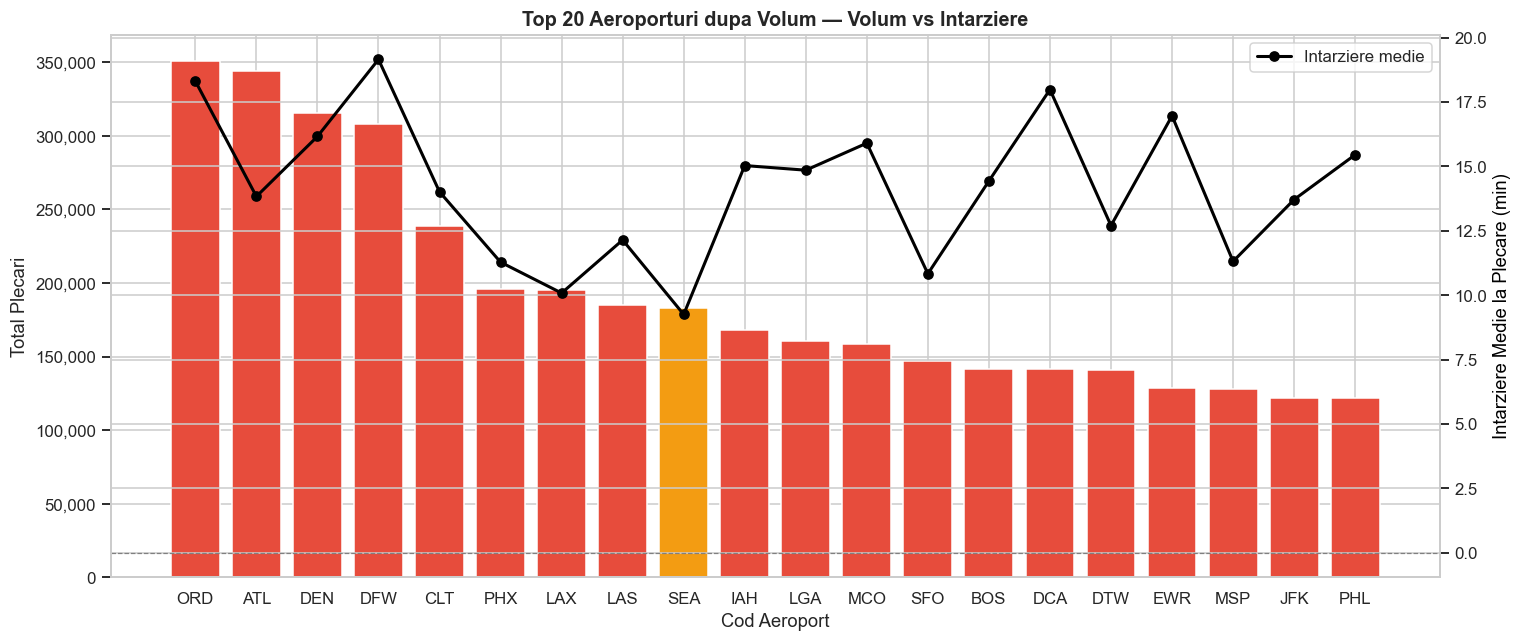

In [125]:
# Top 20 aeroporturi dupa volum
busiest = airport_stats.nlargest(20, 'total_plecari')[['total_plecari', 'intarziere_medie_plecare']]

fig, ax = plt.subplots(figsize=(14, 6))
colors_b = ['#e74c3c' if x > 10 else '#f39c12' if x > 0 else '#2ecc71'
            for x in busiest['intarziere_medie_plecare']]
bars = ax.bar(busiest.index, busiest['total_plecari'], color=colors_b, edgecolor='white')

ax2 = ax.twinx()
ax2.plot(busiest.index, busiest['intarziere_medie_plecare'], 'ko-', lw=2, ms=6, label='Intarziere medie')
ax2.axhline(0, color='gray', lw=0.8, linestyle='--')
ax2.set_ylabel('Intarziere Medie la Plecare (min)', color='black')

ax.set_title('Top 20 Aeroporturi dupa Volum — Volum vs Intarziere', fontsize=13, fontweight='bold')
ax.set_ylabel('Total Plecari')
ax.set_xlabel('Cod Aeroport')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
plt.xticks(rotation=45)
ax2.legend(loc='upper right')
plt.tight_layout()
plt.show()

## 6. Analiza Rutelor


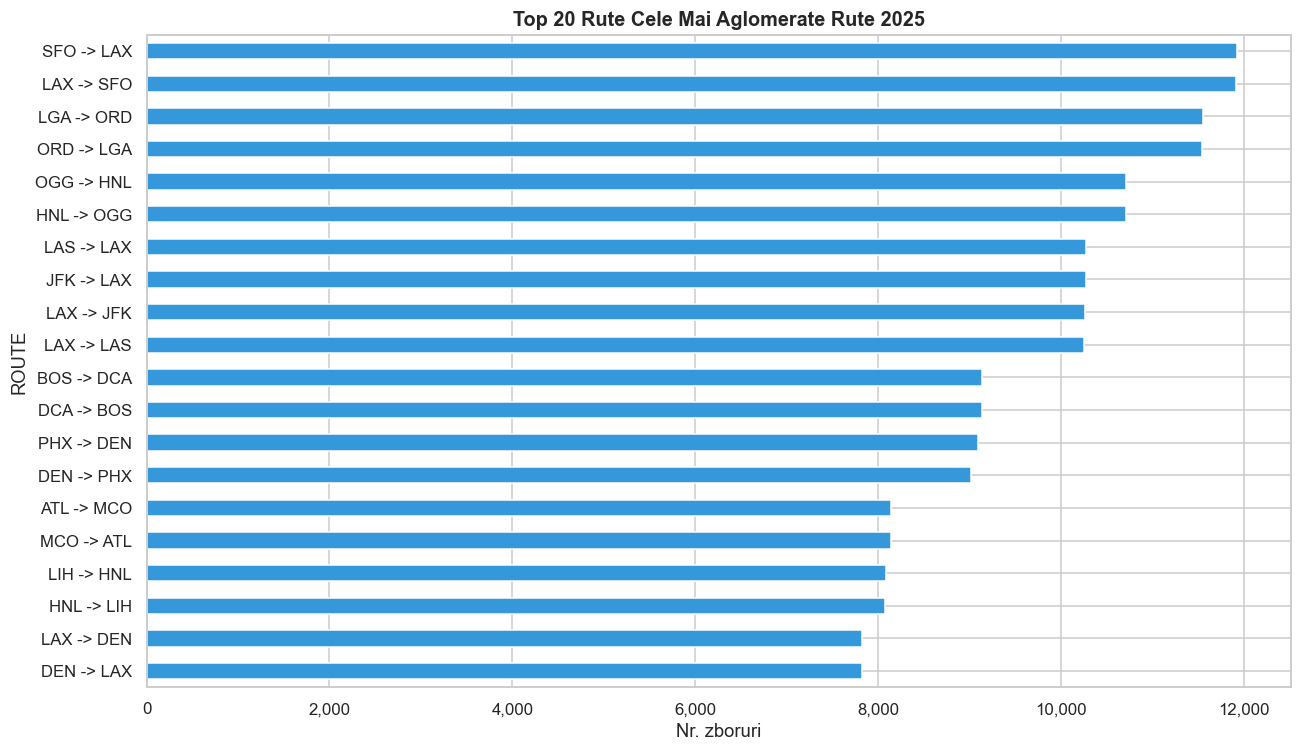

In [101]:
df['ROUTE'] = df['ORIGIN'] + ' -> ' + df['DEST']
top_routes = df['ROUTE'].value_counts().head(20)

fig, ax = plt.subplots(figsize=(12, 7))
top_routes.sort_values().plot(kind='barh', ax=ax, color='#3498db', edgecolor='white')
ax.set_title('Top 20 Rute Cele Mai Aglomerate Rute 2025', fontsize=13, fontweight='bold')
ax.set_xlabel('Nr. zboruri')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
plt.tight_layout()
plt.show()

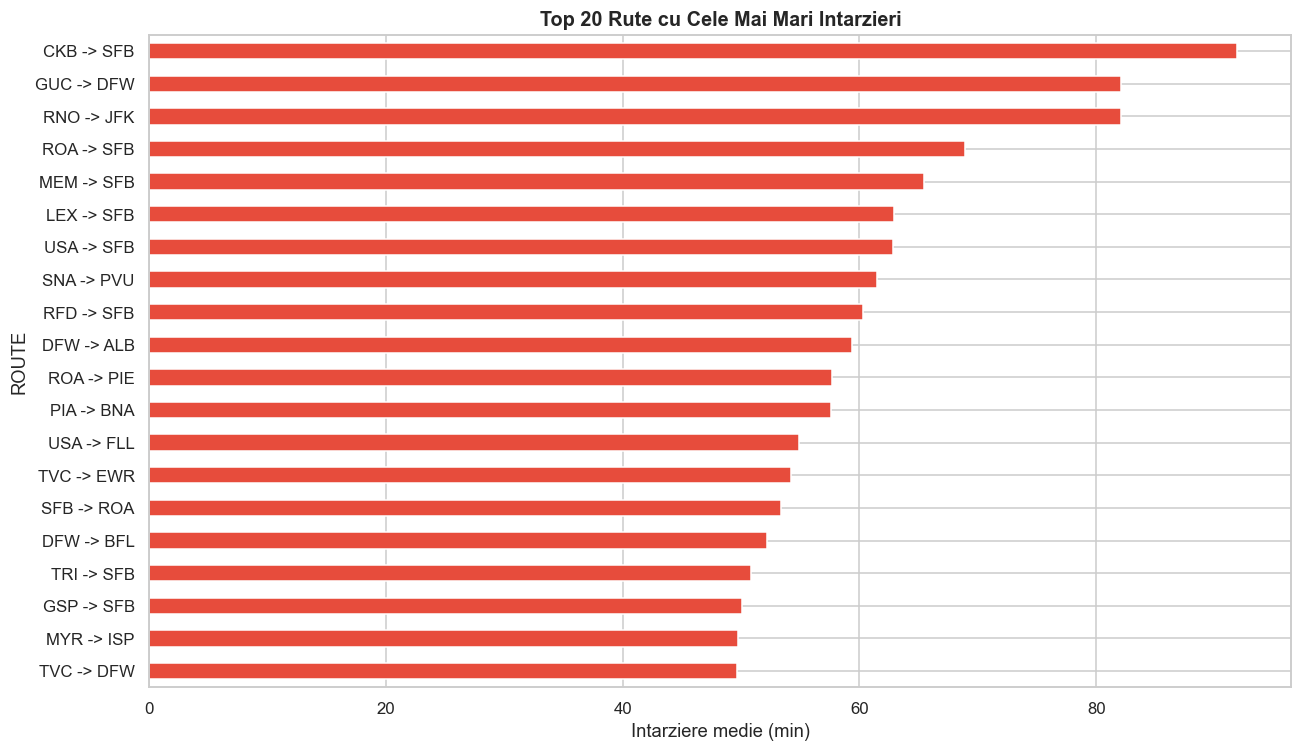

In [102]:
df_flown['ROUTE'] = df_flown['ORIGIN'] + ' -> ' + df_flown['DEST']

route_delay = df_flown.groupby('ROUTE').agg(
    mean_delay=('ARR_DELAY', 'mean'),
    total=('ARR_DELAY', 'count')
).query('total > 100').nlargest(20, 'mean_delay')

fig, ax = plt.subplots(figsize=(12, 7))
route_delay['mean_delay'].sort_values().plot(kind='barh', ax=ax, color='#e74c3c', edgecolor='white')
ax.set_title('Top 20 Rute cu Cele Mai Mari Intarzieri', fontsize=13, fontweight='bold')
ax.set_xlabel('Intarziere medie (min)')
plt.tight_layout()
plt.show()

## 7. Corelatii intre variabile

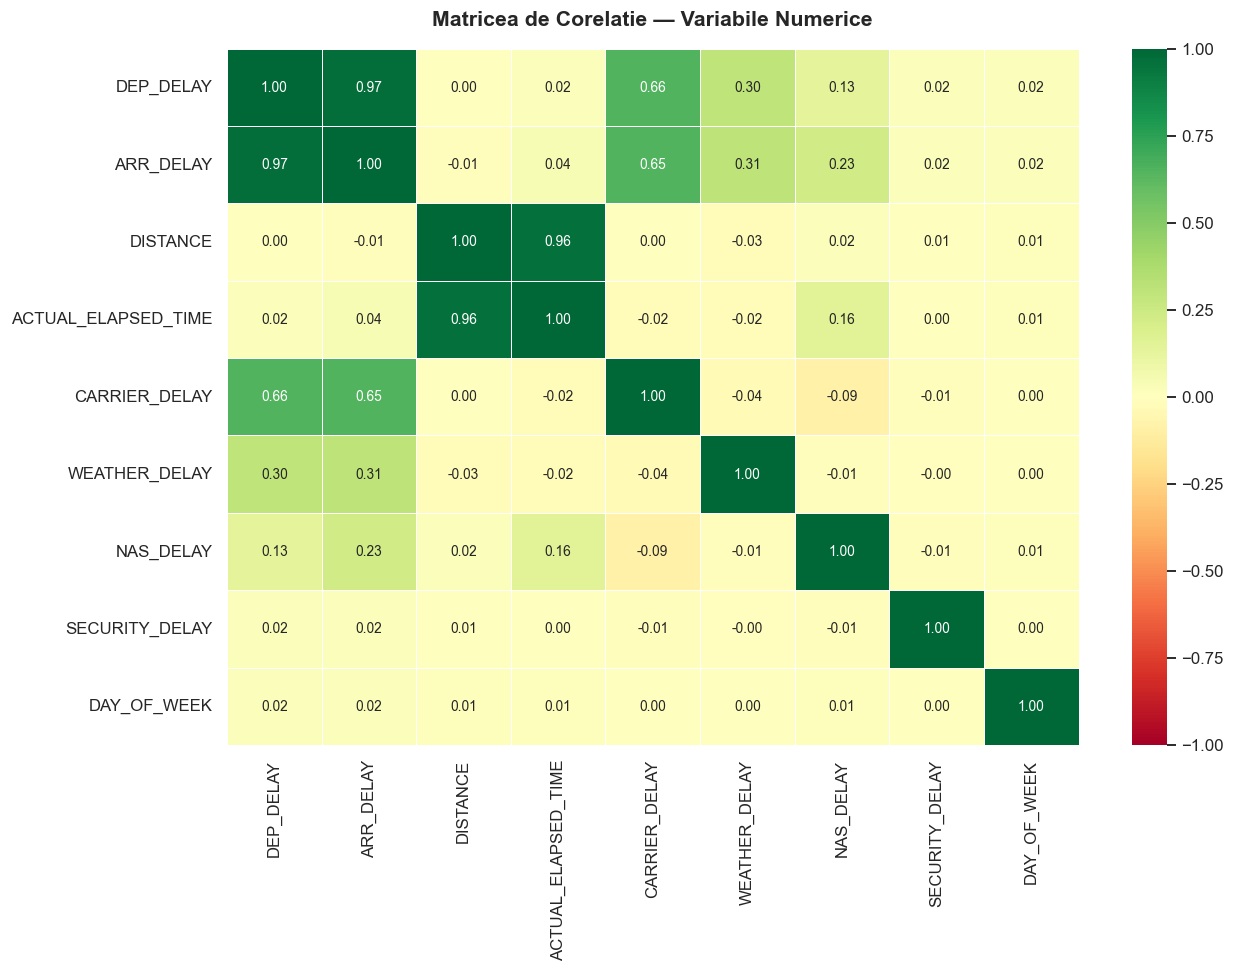

In [103]:
import pandas as pd
import numpy as np

corr_cols = ['DEP_DELAY', 'ARR_DELAY', 'DISTANCE', 'ACTUAL_ELAPSED_TIME',
             'CARRIER_DELAY', 'WEATHER_DELAY', 'NAS_DELAY', 'SECURITY_DELAY',
             'DAY_OF_WEEK']
corr_cols = [c for c in corr_cols if c in df_flown.columns]

corr_matrix = df_flown[corr_cols].corr().round(3)

fig, ax = plt.subplots(figsize=(12, 9))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdYlGn',
            vmin=-1, vmax=1, ax=ax, linewidths=0.5,
            annot_kws={'size': 9})
ax.set_title('Matricea de Corelatie - Variabile Numerice', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

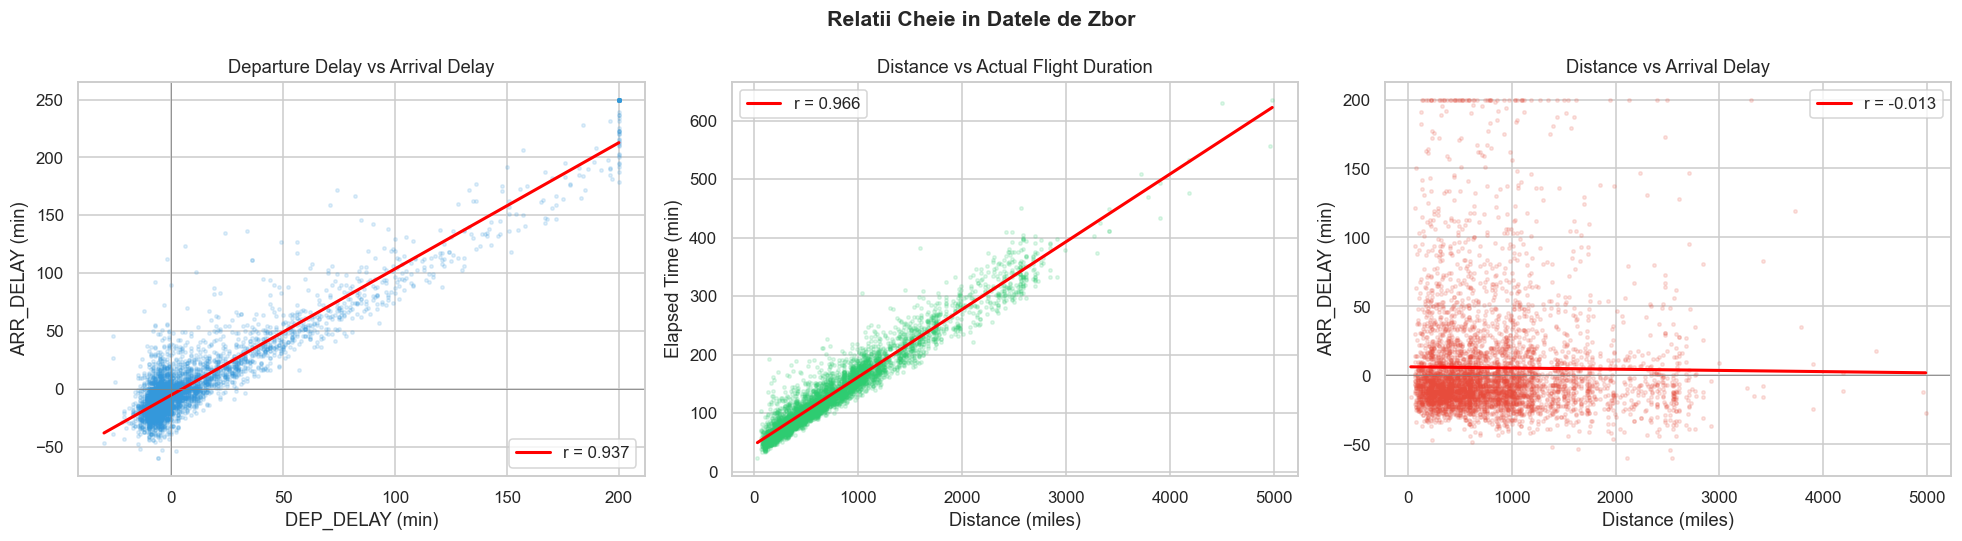

In [67]:
# Scatter plots for key correlations
sample = df_flown[['DEP_DELAY', 'ARR_DELAY', 'DISTANCE', 'ACTUAL_ELAPSED_TIME']].dropna().sample(n=5000, random_state=42)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# DEP_DELAY vs ARR_DELAY
x, y = sample['DEP_DELAY'].clip(-30, 200), sample['ARR_DELAY'].clip(-60, 250)
axes[0].scatter(x, y, alpha=0.15, s=5, color='#3498db')
m, b, r, p, _ = stats.linregress(x, y)
xl = np.linspace(x.min(), x.max(), 100)
axes[0].plot(xl, m*xl+b, 'r-', lw=2, label=f'r = {r:.3f}')
axes[0].set_title('Departure Delay vs Arrival Delay')
axes[0].set_xlabel('DEP_DELAY (min)')
axes[0].set_ylabel('ARR_DELAY (min)')
axes[0].legend()
axes[0].axhline(0, color='gray', lw=0.5)
axes[0].axvline(0, color='gray', lw=0.5)

# DISTANCE vs ELAPSED_TIME
x2, y2 = sample['DISTANCE'], sample['ACTUAL_ELAPSED_TIME']
axes[1].scatter(x2, y2, alpha=0.15, s=5, color='#2ecc71')
m2, b2, r2, p2, _ = stats.linregress(x2, y2)
xl2 = np.linspace(x2.min(), x2.max(), 100)
axes[1].plot(xl2, m2*xl2+b2, 'r-', lw=2, label=f'r = {r2:.3f}')
axes[1].set_title('Distance vs Actual Flight Duration')
axes[1].set_xlabel('Distance (miles)')
axes[1].set_ylabel('Elapsed Time (min)')
axes[1].legend()

# DISTANCE vs ARR_DELAY
x3, y3 = sample['DISTANCE'], sample['ARR_DELAY'].clip(-60, 200)
axes[2].scatter(x3, y3, alpha=0.15, s=5, color='#e74c3c')
m3, b3, r3, p3, _ = stats.linregress(x3, y3)
xl3 = np.linspace(x3.min(), x3.max(), 100)
axes[2].plot(xl3, m3*xl3+b3, 'r-', lw=2, label=f'r = {r3:.3f}')
axes[2].set_title('Distance vs Arrival Delay')
axes[2].set_xlabel('Distance (miles)')
axes[2].set_ylabel('ARR_DELAY (min)')
axes[2].axhline(0, color='gray', lw=0.5)
axes[2].legend()

plt.suptitle('Relatii Cheie in Datele de Zbor', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 8. Cauze de intarziere


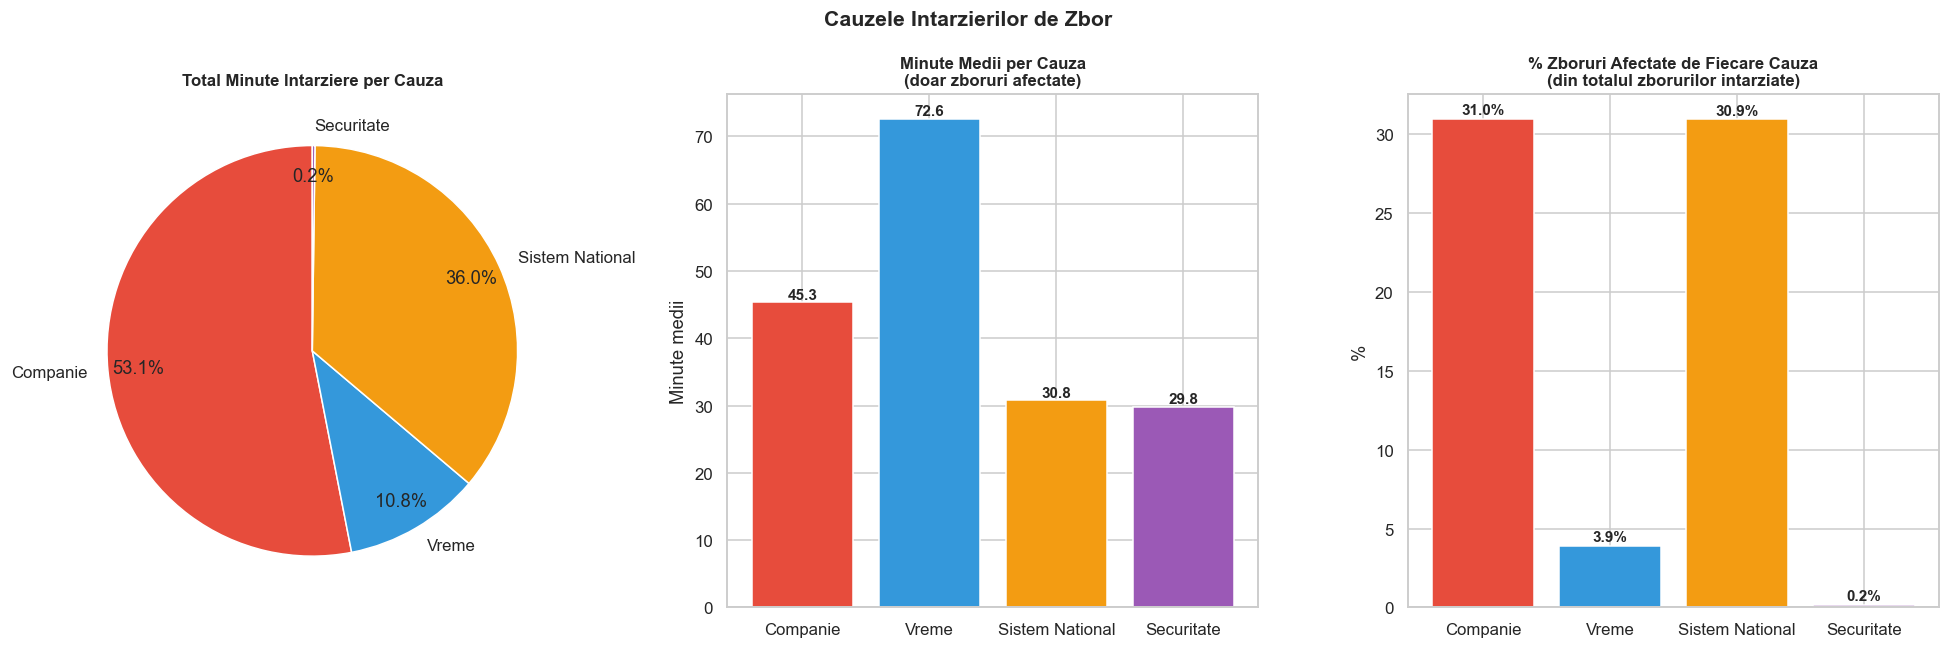

In [81]:
delay_cause_cols = ['CARRIER_DELAY', 'WEATHER_DELAY', 'NAS_DELAY', 'SECURITY_DELAY']
delay_cause_cols = [c for c in delay_cause_cols if c in df.columns]

df_delayed = df_flown[df_flown['ARR_DELAY'] > 0]

totals = df_delayed[delay_cause_cols].sum()
means  = df_delayed[delay_cause_cols].apply(lambda x: x[x>0].mean())

labels = ['Companie', 'Vreme', 'Sistem National', 'Securitate']
colors_p = ['#e74c3c', '#3498db', '#f39c12', '#9b59b6']

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Pie chart total minute
axes[0].pie(totals, labels=labels, autopct='%1.1f%%', colors=colors_p,
            startangle=90, pctdistance=0.85)
axes[0].set_title('Total Minute Intarziere per Cauza', fontsize=11, fontweight='bold')

# Bar chart minute medii
axes[1].bar(labels, means, color=colors_p, edgecolor='white')
axes[1].set_title('Minute Medii per Cauza\n(doar zboruri afectate)', fontsize=11, fontweight='bold')
axes[1].set_ylabel('Minute medii')
for i, v in enumerate(means):
    axes[1].text(i, v + 0.5, f'{v:.1f}', ha='center', fontsize=10, fontweight='bold')

# % zboruri afectate de fiecare cauza
pct_affected = [(df_delayed[c] > 0).mean() * 100 for c in delay_cause_cols]
axes[2].bar(labels, pct_affected, color=colors_p, edgecolor='white')
axes[2].set_title('% Zboruri Afectate de Fiecare Cauza\n(din totalul zborurilor intarziate)', fontsize=11, fontweight='bold')
axes[2].set_ylabel('%')
for i, v in enumerate(pct_affected):
    axes[2].text(i, v + 0.3, f'{v:.1f}%', ha='center', fontsize=10, fontweight='bold')

plt.suptitle('Cauzele Intarzierilor de Zbor', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

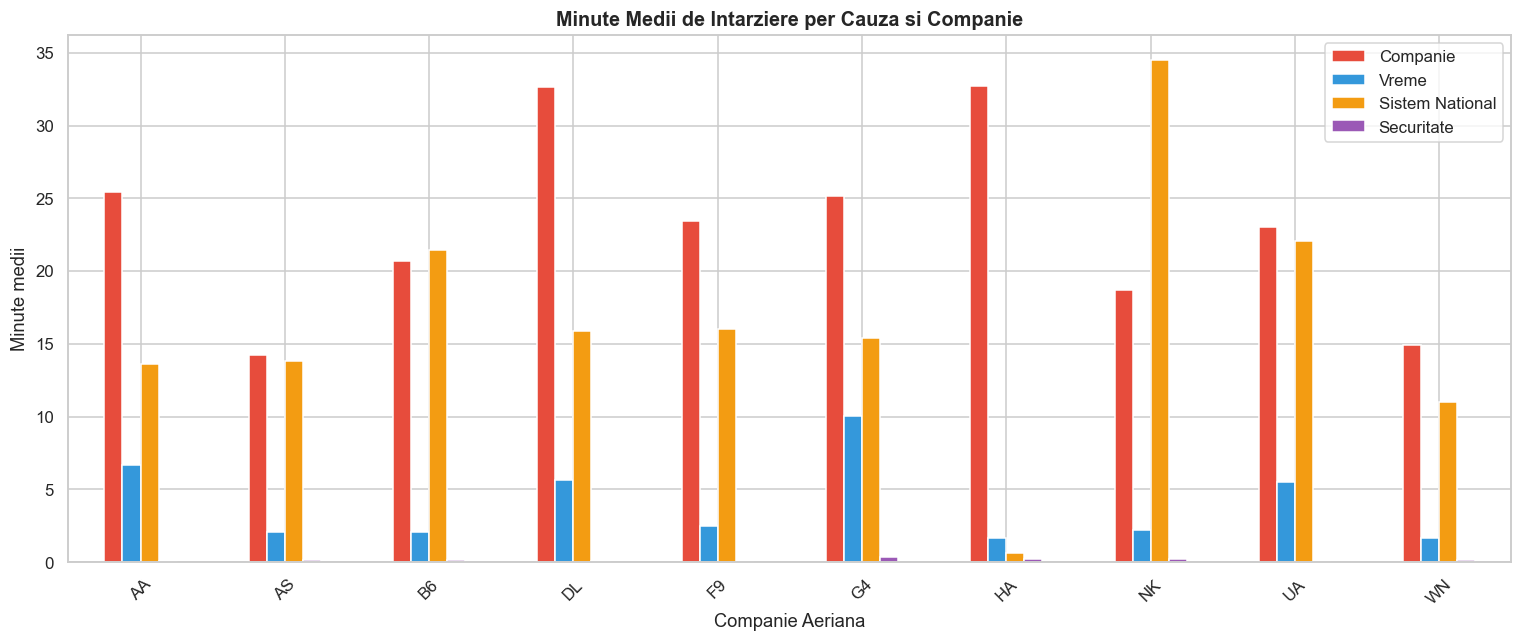

In [82]:
cause_by_carrier = df_delayed.groupby('MKT_UNIQUE_CARRIER')[delay_cause_cols].mean().round(2)

cause_by_carrier.plot(kind='bar', figsize=(14, 6), color=colors_p, edgecolor='white')
plt.title('Minute Medii de Intarziere per Cauza si Companie', fontsize=13, fontweight='bold')
plt.xlabel('Companie Aeriana')
plt.ylabel('Minute medii')
plt.legend(['Companie', 'Vreme', 'Sistem National', 'Securitate'], loc='upper right')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 9. Pattern temporale


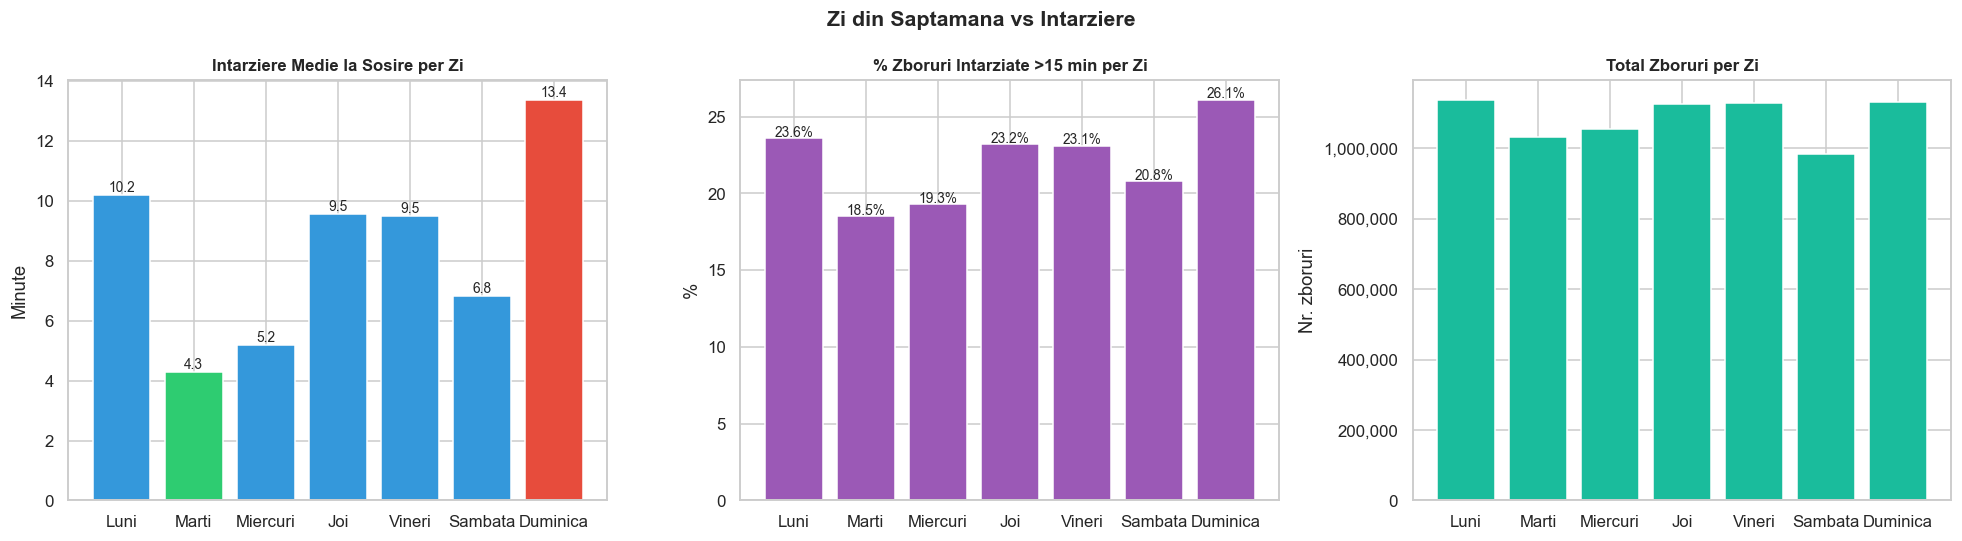

In [80]:
dow_map = {1: 'Luni', 2: 'Marti', 3: 'Miercuri', 4: 'Joi', 5: 'Vineri', 6: 'Sambata', 7: 'Duminica'}

dow_stats = df_flown.groupby('DAY_OF_WEEK').agg(
    mean_arr_delay=('ARR_DELAY', 'mean'),
    pct_delayed=('ARR_DEL15', 'mean'),
    total_flights=('ARR_DELAY', 'count')
).round(3)
dow_stats.index = [dow_map.get(i, str(i)) for i in dow_stats.index]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

colors_d = ['#e74c3c' if v == dow_stats['mean_arr_delay'].max()
            else '#2ecc71' if v == dow_stats['mean_arr_delay'].min()
            else '#3498db' for v in dow_stats['mean_arr_delay']]

axes[0].bar(dow_stats.index, dow_stats['mean_arr_delay'], color=colors_d, edgecolor='white')
axes[0].set_title('Intarziere Medie la Sosire per Zi', fontsize=11, fontweight='bold')
axes[0].set_ylabel('Minute')
for i, v in enumerate(dow_stats['mean_arr_delay']):
    axes[0].text(i, v + 0.1, f'{v:.1f}', ha='center', fontsize=9)

axes[1].bar(dow_stats.index, dow_stats['pct_delayed']*100, color='#9b59b6', edgecolor='white')
axes[1].set_title('% Zboruri Intarziate >15 min per Zi', fontsize=11, fontweight='bold')
axes[1].set_ylabel('%')
for i, v in enumerate(dow_stats['pct_delayed']*100):
    axes[1].text(i, v + 0.1, f'{v:.1f}%', ha='center', fontsize=9)

axes[2].bar(dow_stats.index, dow_stats['total_flights'], color='#1abc9c', edgecolor='white')
axes[2].set_title('Total Zboruri per Zi', fontsize=11, fontweight='bold')
axes[2].set_ylabel('Nr. zboruri')
axes[2].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

plt.suptitle('Zi din Saptamana vs Intarziere', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

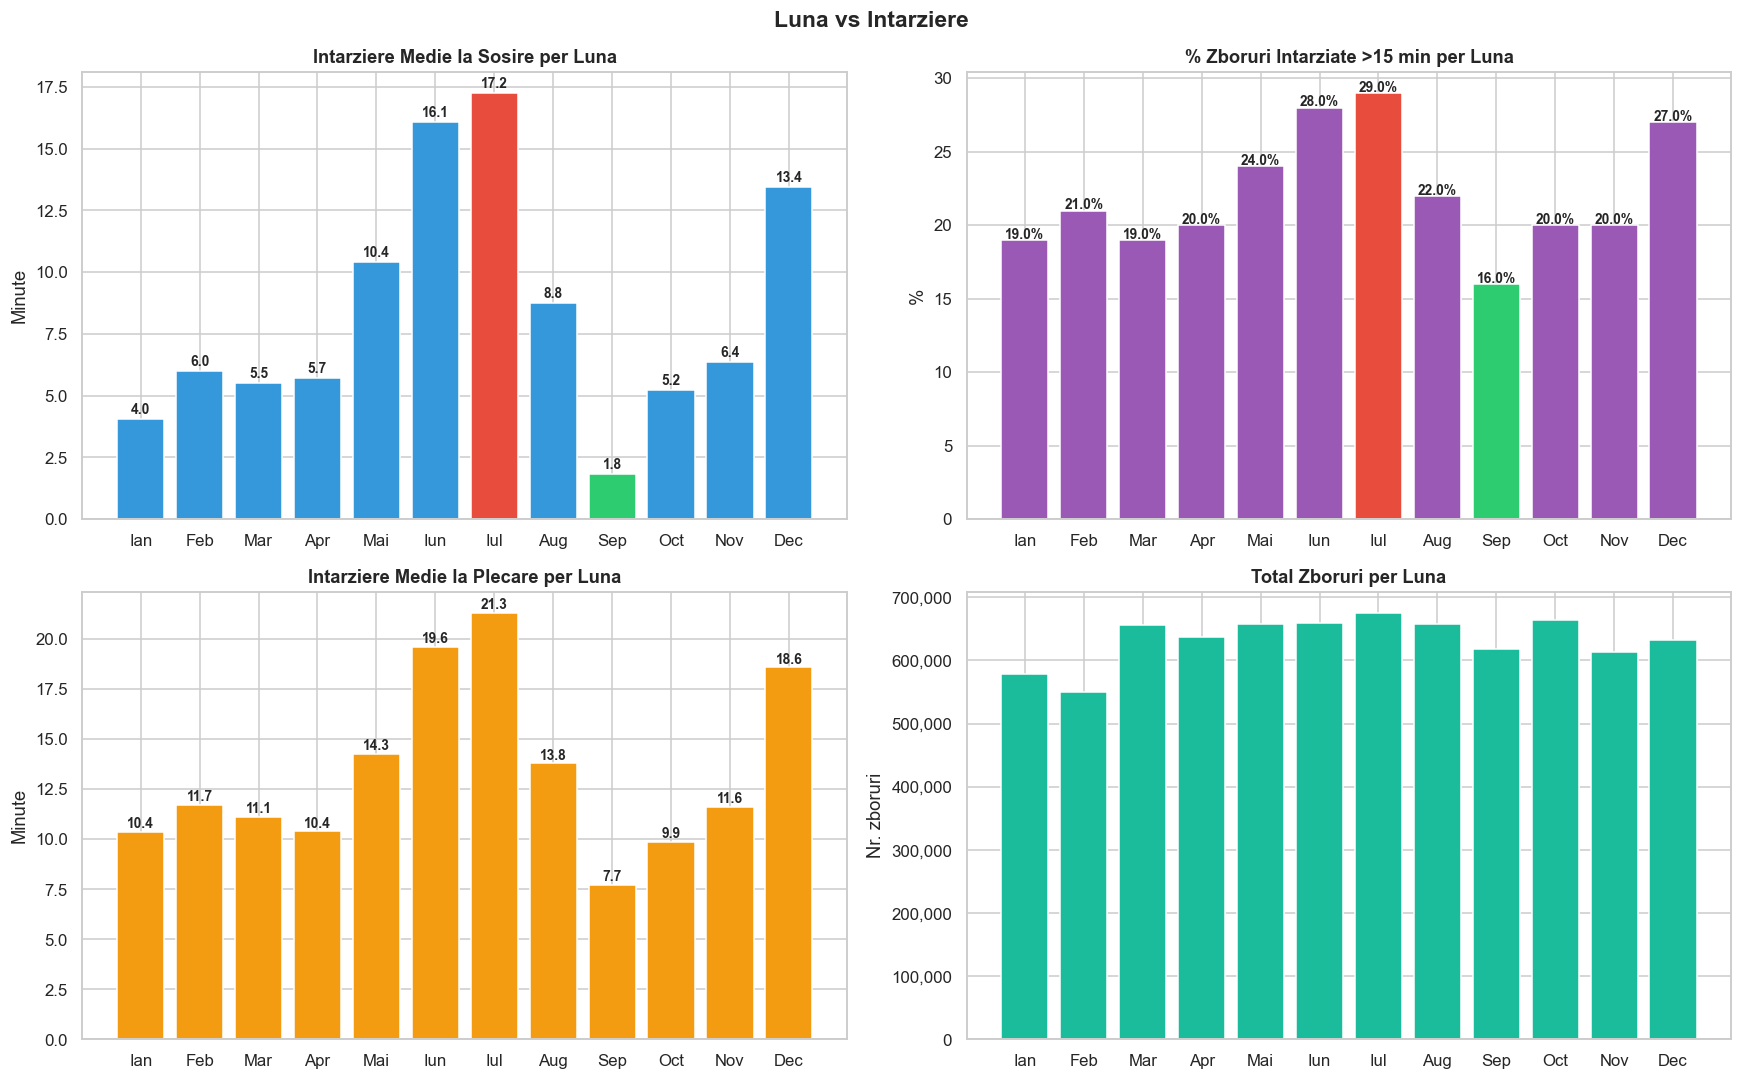

In [78]:
month_stats = df_flown.groupby('MONTH').agg(
    mean_arr_delay=('ARR_DELAY', 'mean'),
    pct_delayed=('ARR_DEL15', 'mean'),
    mean_dep_delay=('DEP_DELAY', 'mean'),
    total_flights=('ARR_DELAY', 'count')
).round(2)

month_names = {1:'Ian', 2:'Feb', 3:'Mar', 4:'Apr', 5:'Mai', 6:'Iun',
               7:'Iul', 8:'Aug', 9:'Sep', 10:'Oct', 11:'Nov', 12:'Dec'}
month_stats.index = [month_names[m] for m in month_stats.index]

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# intarziere medie sosire
colors_m = ['#e74c3c' if v == month_stats['mean_arr_delay'].max()
            else '#2ecc71' if v == month_stats['mean_arr_delay'].min()
            else '#3498db' for v in month_stats['mean_arr_delay']]
axes[0,0].bar(month_stats.index, month_stats['mean_arr_delay'], color=colors_m, edgecolor='white')
axes[0,0].set_title('Intarziere Medie la Sosire per Luna', fontsize=12, fontweight='bold')
axes[0,0].set_ylabel('Minute')
for i, v in enumerate(month_stats['mean_arr_delay']):
    axes[0,0].text(i, v + 0.2, f'{v:.1f}', ha='center', fontsize=9, fontweight='bold')

# Grafic 2 — % intarziate
colors_p = ['#e74c3c' if v == month_stats['pct_delayed'].max()
            else '#2ecc71' if v == month_stats['pct_delayed'].min()
            else '#9b59b6' for v in month_stats['pct_delayed']]
axes[0,1].bar(month_stats.index, month_stats['pct_delayed']*100, color=colors_p, edgecolor='white')
axes[0,1].set_title('% Zboruri Intarziate >15 min per Luna', fontsize=12, fontweight='bold')
axes[0,1].set_ylabel('%')
for i, v in enumerate(month_stats['pct_delayed']*100):
    axes[0,1].text(i, v + 0.1, f'{v:.1f}%', ha='center', fontsize=9, fontweight='bold')

#intarziere medie plecare
axes[1,0].bar(month_stats.index, month_stats['mean_dep_delay'], color='#f39c12', edgecolor='white')
axes[1,0].set_title('Intarziere Medie la Plecare per Luna', fontsize=12, fontweight='bold')
axes[1,0].set_ylabel('Minute')
for i, v in enumerate(month_stats['mean_dep_delay']):
    axes[1,0].text(i, v + 0.2, f'{v:.1f}', ha='center', fontsize=9, fontweight='bold')

#volum zboruri
axes[1,1].bar(month_stats.index, month_stats['total_flights'], color='#1abc9c', edgecolor='white')
axes[1,1].set_title('Total Zboruri per Luna', fontsize=12, fontweight='bold')
axes[1,1].set_ylabel('Nr. zboruri')
axes[1,1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

fig.suptitle('Luna vs Intarziere',
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

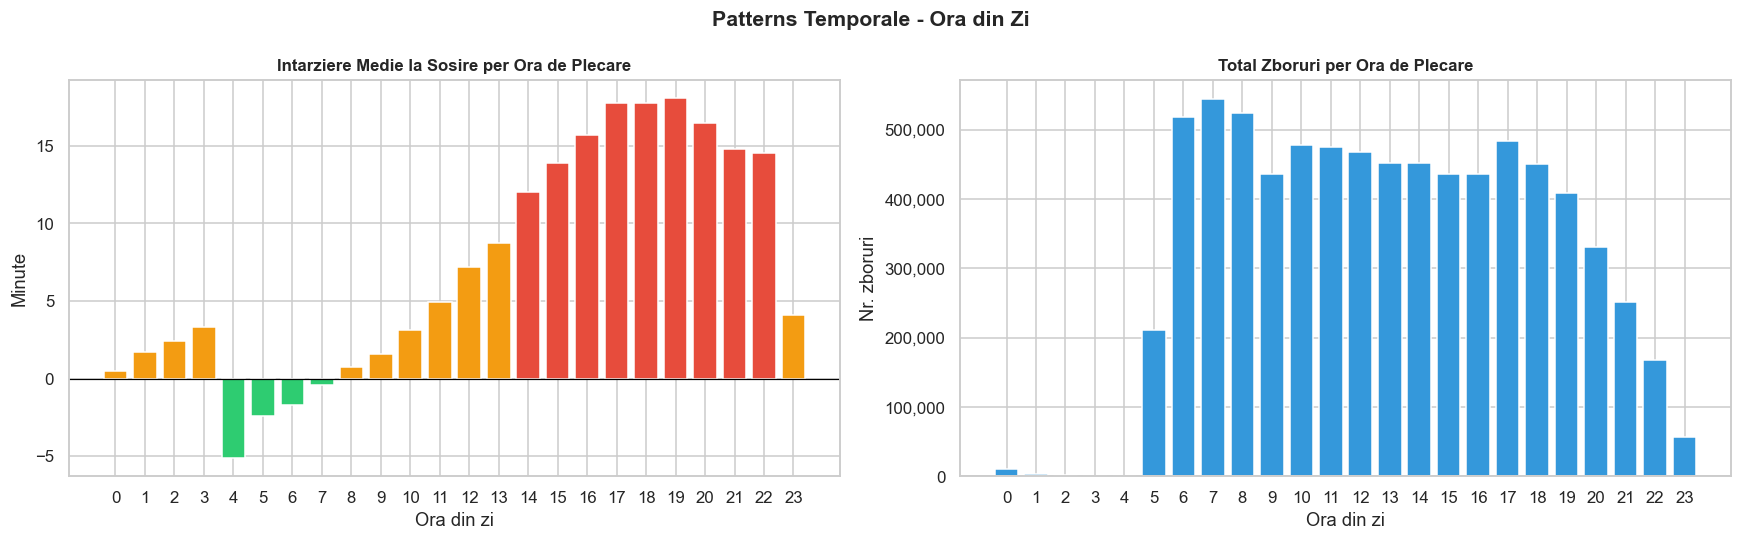

Zborurile de dimineata (05:00-08:00) sunt cele mai punctuale.
Intarzierile se acumuleaza pe parcursul zilei.


In [85]:
df_flown['DEP_HOUR'] = df_flown['CRS_DEP_TIME'] // 100
df_flown = df_flown[df_flown['DEP_HOUR'].between(0, 23)]

hour_stats = df_flown.groupby('DEP_HOUR').agg(
    mean_arr_delay=('ARR_DELAY', 'mean'),
    pct_delayed=('ARR_DEL15', 'mean'),
    total_flights=('ARR_DELAY', 'count')
).round(3)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

colors_h = ['#e74c3c' if v > 10 else '#f39c12' if v > 0 else '#2ecc71'
            for v in hour_stats['mean_arr_delay']]
axes[0].bar(hour_stats.index, hour_stats['mean_arr_delay'], color=colors_h, edgecolor='white')
axes[0].axhline(0, color='black', lw=0.8)
axes[0].set_title('Intarziere Medie la Sosire per Ora de Plecare', fontsize=11, fontweight='bold')
axes[0].set_xlabel('Ora din zi')
axes[0].set_ylabel('Minute')
axes[0].set_xticks(range(24))

axes[1].bar(hour_stats.index, hour_stats['total_flights'], color='#3498db', edgecolor='white')
axes[1].set_title('Total Zboruri per Ora de Plecare', fontsize=11, fontweight='bold')
axes[1].set_xlabel('Ora din zi')
axes[1].set_ylabel('Nr. zboruri')
axes[1].set_xticks(range(24))
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

plt.suptitle('Patterns Temporale - Ora din Zi', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('Zborurile de dimineata (05:00-08:00) sunt cele mai punctuale.')
print('Intarzierile se acumuleaza pe parcursul zilei.')

## 9. Analiza pe distanta


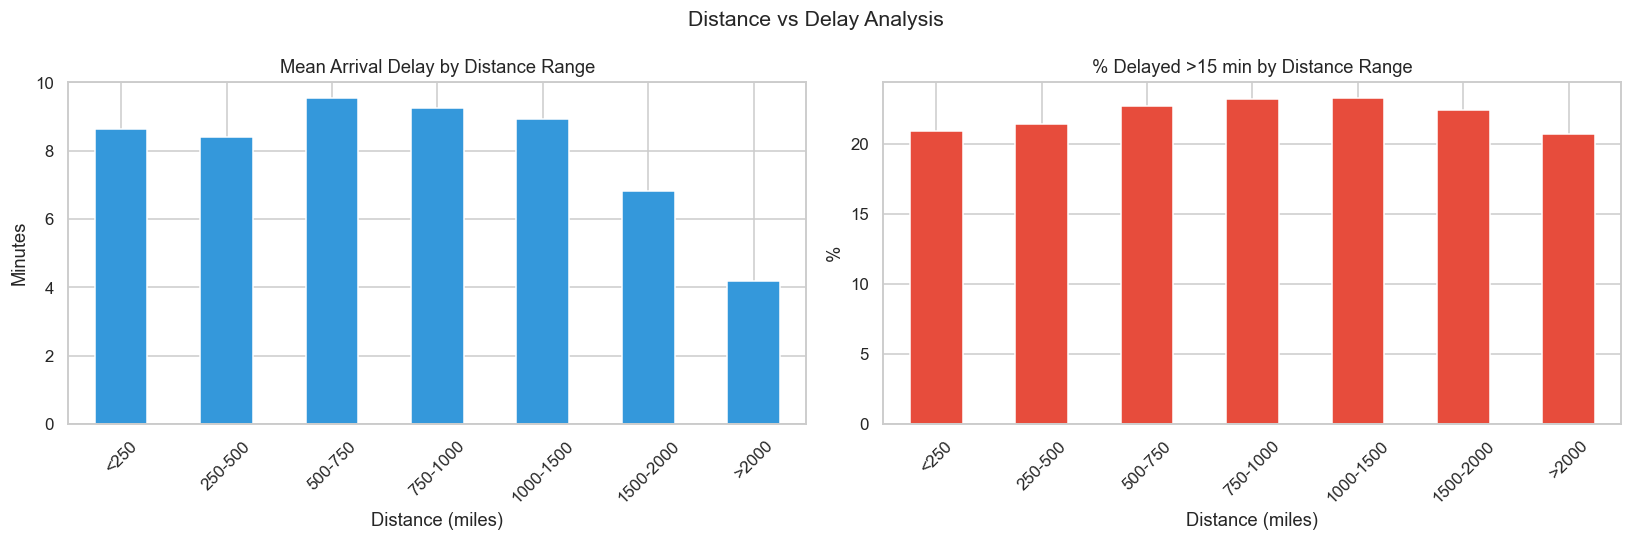

In [86]:
df_flown['DISTANCE_GROUP'] = pd.cut(df_flown['DISTANCE'],
    bins=[0, 250, 500, 750, 1000, 1500, 2000, 5000],
    labels=['<250', '250-500', '500-750', '750-1000', '1000-1500', '1500-2000', '>2000'])

dist_stats = df_flown.groupby('DISTANCE_GROUP', observed=True).agg(
    mean_arr_delay=('ARR_DELAY', 'mean'),
    pct_delayed=('ARR_DEL15', 'mean'),
    total_flights=('ARR_DELAY', 'count')
).round(3)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

dist_stats['mean_arr_delay'].plot(kind='bar', ax=axes[0], color='#3498db', edgecolor='white')
axes[0].set_title('Mean Arrival Delay by Distance Range')
axes[0].set_xlabel('Distance (miles)')
axes[0].set_ylabel('Minutes')
axes[0].axhline(0, color='black', lw=0.8)
plt.setp(axes[0].xaxis.get_majorticklabels(), rotation=45)

(dist_stats['pct_delayed']*100).plot(kind='bar', ax=axes[1], color='#e74c3c', edgecolor='white')
axes[1].set_title('% Delayed >15 min by Distance Range')
axes[1].set_xlabel('Distance (miles)')
axes[1].set_ylabel('%')
plt.setp(axes[1].xaxis.get_majorticklabels(), rotation=45)

plt.suptitle('Distance vs Delay Analysis', fontsize=14)
plt.tight_layout()
plt.show()

## 11. Analiza anularilor


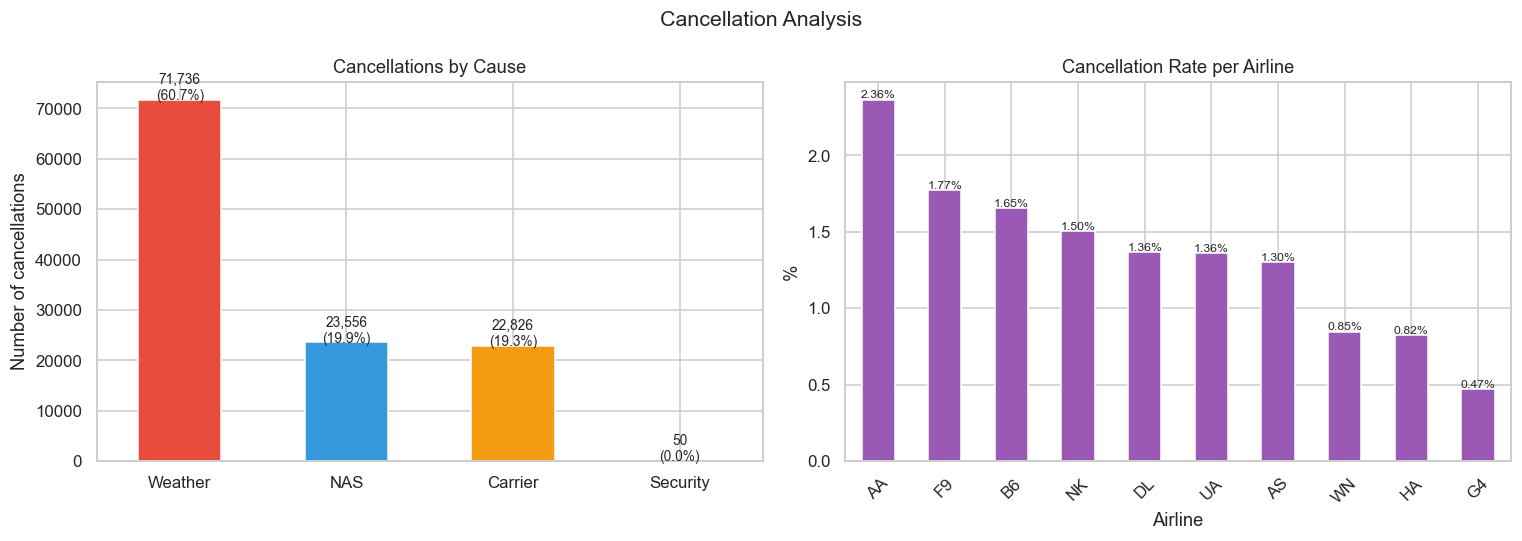

Overall cancellation rate: 1.53%


In [87]:
df_cancelled = df[df['CANCELLED'] == 1]

cancel_code_map = {'A': 'Carrier', 'B': 'Weather', 'C': 'NAS', 'D': 'Security'}
cancel_counts = df_cancelled['CANCELLATION_CODE'].map(cancel_code_map).value_counts()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cancel_counts.plot(kind='bar', ax=axes[0], color=['#e74c3c','#3498db','#f39c12','#9b59b6'], edgecolor='white')
axes[0].set_title('Cancellations by Cause')
axes[0].set_ylabel('Number of cancellations')
axes[0].set_xlabel('')
plt.setp(axes[0].xaxis.get_majorticklabels(), rotation=0)
for i, v in enumerate(cancel_counts):
    axes[0].text(i, v + 5, f'{v:,}\n({v/len(df_cancelled)*100:.1f}%)', ha='center', fontsize=9)

# Cancellations per airline
cancel_by_carrier = df.groupby('MKT_UNIQUE_CARRIER')['CANCELLED'].agg(['sum', 'mean'])
cancel_by_carrier.columns = ['total_cancelled', 'pct_cancelled']
cancel_by_carrier = cancel_by_carrier.sort_values('pct_cancelled', ascending=False)
(cancel_by_carrier['pct_cancelled']*100).plot(kind='bar', ax=axes[1],
                                               color='#9b59b6', edgecolor='white')
axes[1].set_title('Cancellation Rate per Airline')
axes[1].set_ylabel('%')
axes[1].set_xlabel('Airline')
plt.setp(axes[1].xaxis.get_majorticklabels(), rotation=45)
for i, v in enumerate(cancel_by_carrier['pct_cancelled']*100):
    axes[1].text(i, v + 0.01, f'{v:.2f}%', ha='center', fontsize=8)

plt.suptitle('Cancellation Analysis', fontsize=14)
plt.tight_layout()
plt.show()

total_cancel_pct = df['CANCELLED'].mean() * 100
print(f'Overall cancellation rate: {total_cancel_pct:.2f}%')

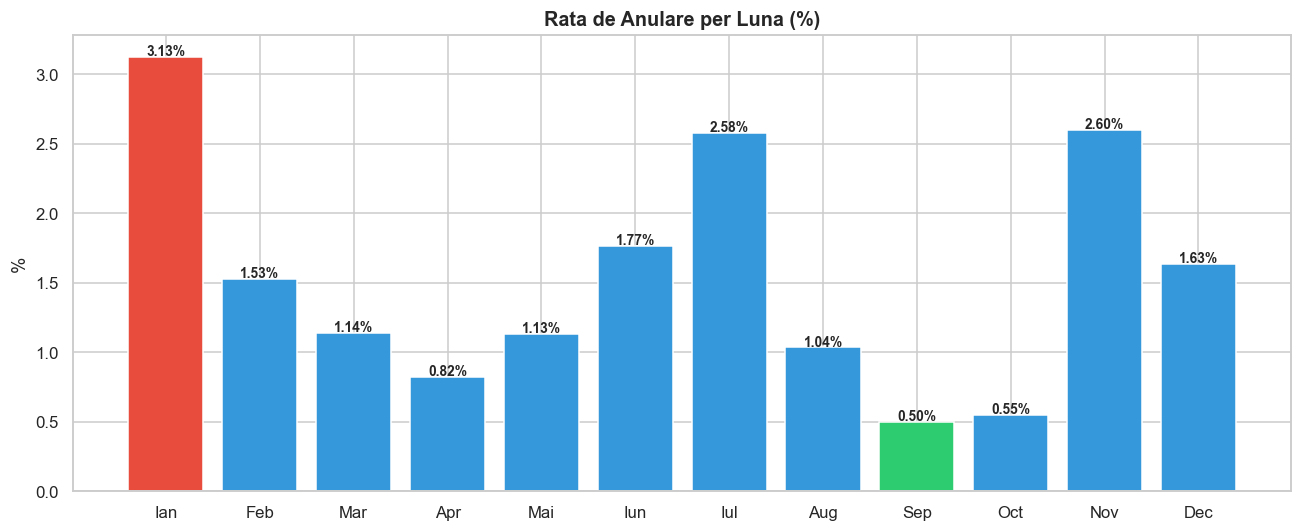

In [91]:
cancel_by_month = df.groupby('MONTH')['CANCELLED'].mean() * 100
month_names = {1:'Ian', 2:'Feb', 3:'Mar', 4:'Apr', 5:'Mai', 6:'Iun',
               7:'Iul', 8:'Aug', 9:'Sep', 10:'Oct', 11:'Nov', 12:'Dec'}
cancel_by_month.index = [month_names[m] for m in cancel_by_month.index]

fig, ax = plt.subplots(figsize=(12, 5))
colors_m = ['#e74c3c' if v == cancel_by_month.max()
            else '#2ecc71' if v == cancel_by_month.min()
            else '#3498db' for v in cancel_by_month]
ax.bar(cancel_by_month.index, cancel_by_month, color=colors_m, edgecolor='white')
ax.set_title('Rata de Anulare per Luna (%)', fontsize=13, fontweight='bold')
ax.set_ylabel('%')
for i, v in enumerate(cancel_by_month):
    ax.text(i, v + 0.01, f'{v:.2f}%', ha='center', fontsize=9, fontweight='bold')
plt.tight_layout()
plt.show()

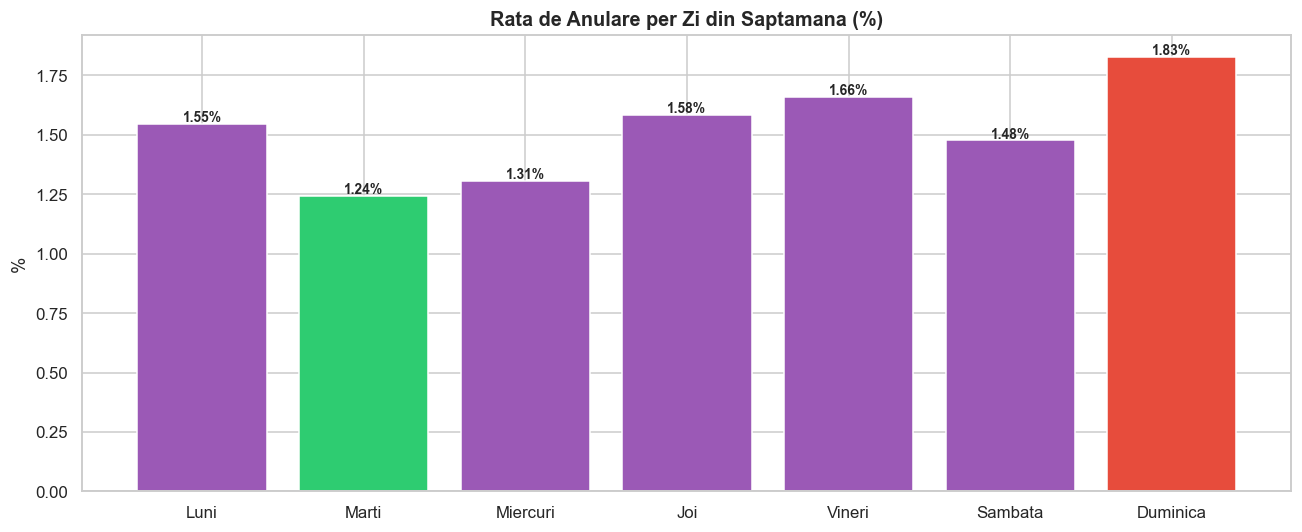

In [92]:

cancel_by_dow = df.groupby('DAY_OF_WEEK')['CANCELLED'].mean() * 100
dow_names = {1:'Luni', 2:'Marti', 3:'Miercuri', 4:'Joi', 5:'Vineri', 6:'Sambata', 7:'Duminica'}
cancel_by_dow.index = [dow_names[d] for d in cancel_by_dow.index]

fig, ax = plt.subplots(figsize=(12, 5))
colors_d = ['#e74c3c' if v == cancel_by_dow.max()
            else '#2ecc71' if v == cancel_by_dow.min()
            else '#9b59b6' for v in cancel_by_dow]
ax.bar(cancel_by_dow.index, cancel_by_dow, color=colors_d, edgecolor='white')
ax.set_title('Rata de Anulare per Zi din Saptamana (%)', fontsize=13, fontweight='bold')
ax.set_ylabel('%')
for i, v in enumerate(cancel_by_dow):
    ax.text(i, v + 0.01, f'{v:.2f}%', ha='center', fontsize=9, fontweight='bold')
plt.tight_layout()
plt.show()

## 12. Anulari vs Intarzieri

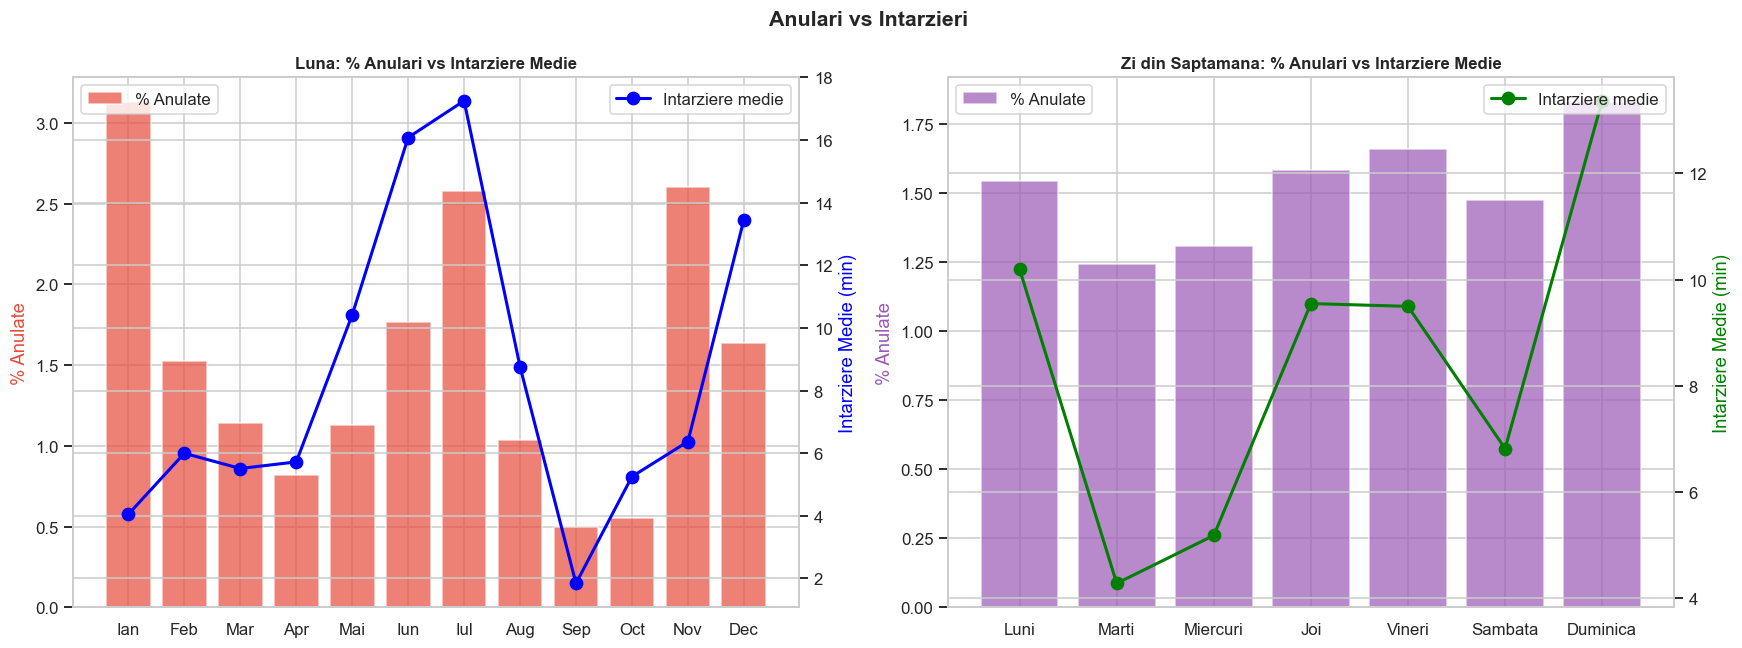

In [96]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

month_compare = pd.DataFrame({
    'pct_cancelled': df.groupby('MONTH')['CANCELLED'].mean() * 100,
    'mean_delay': df.groupby('MONTH')['ARR_DELAY'].mean()
})
month_names = {1:'Ian', 2:'Feb', 3:'Mar', 4:'Apr', 5:'Mai', 6:'Iun',
               7:'Iul', 8:'Aug', 9:'Sep', 10:'Oct', 11:'Nov', 12:'Dec'}
month_compare.index = [month_names[m] for m in month_compare.index]

x = range(len(month_compare))
ax1a = axes[0]
ax1b = ax1a.twinx()
ax1a.bar(x, month_compare['pct_cancelled'], color='#e74c3c', alpha=0.7, edgecolor='white', label='% Anulate')
ax1b.plot(x, month_compare['mean_delay'], 'bo-', lw=2, ms=8, label='Intarziere medie')
ax1a.set_xticks(x)
ax1a.set_xticklabels(month_compare.index)
ax1a.set_ylabel('% Anulate', color='#e74c3c')
ax1b.set_ylabel('Intarziere Medie (min)', color='blue')
axes[0].set_title('Luna: % Anulari vs Intarziere Medie', fontsize=11, fontweight='bold')
ax1a.legend(loc='upper left')
ax1b.legend(loc='upper right')

dow_compare = pd.DataFrame({
    'pct_cancelled': df.groupby('DAY_OF_WEEK')['CANCELLED'].mean() * 100,
    'mean_delay': df.groupby('DAY_OF_WEEK')['ARR_DELAY'].mean()
})
dow_names = {1:'Luni', 2:'Marti', 3:'Miercuri', 4:'Joi', 5:'Vineri', 6:'Sambata', 7:'Duminica'}
dow_compare.index = [dow_names[d] for d in dow_compare.index]

x2 = range(len(dow_compare))
ax2a = axes[1]
ax2b = ax2a.twinx()
ax2a.bar(x2, dow_compare['pct_cancelled'], color='#9b59b6', alpha=0.7, edgecolor='white', label='% Anulate')
ax2b.plot(x2, dow_compare['mean_delay'], 'go-', lw=2, ms=8, label='Intarziere medie')
ax2a.set_xticks(x2)
ax2a.set_xticklabels(dow_compare.index)
ax2a.set_ylabel('% Anulate', color='#9b59b6')
ax2b.set_ylabel('Intarziere Medie (min)', color='green')
axes[1].set_title('Zi din Saptamana: % Anulari vs Intarziere Medie', fontsize=11, fontweight='bold')
ax2a.legend(loc='upper left')
ax2b.legend(loc='upper right')

fig.suptitle('Anulari vs Intarzieri ', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 14. Pregatirea datelor pentru model



In [110]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

df_model = df_flown[[
    'MONTH', 'DAY_OF_MONTH', 'DAY_OF_WEEK',
    'MKT_UNIQUE_CARRIER', 'ORIGIN', 'DEST',
    'CRS_DEP_TIME', 'CRS_ARR_TIME',
    'DISTANCE', 'ACTUAL_ELAPSED_TIME',
    'ARR_DEL15'
]].dropna().copy()

# Ora de plecare -> doar ora
df_model['DEP_HOUR'] = df_model['CRS_DEP_TIME'] // 100
df_model = df_model.drop(columns=['CRS_DEP_TIME'])

# Encodam coloanele categorice
le_carrier = LabelEncoder()
le_origin  = LabelEncoder()
le_dest    = LabelEncoder()

df_model['MKT_UNIQUE_CARRIER'] = le_carrier.fit_transform(df_model['MKT_UNIQUE_CARRIER'])
df_model['ORIGIN'] = le_origin.fit_transform(df_model['ORIGIN'])
df_model['DEST']  = le_dest.fit_transform(df_model['DEST'])

# Target si features
X = df_model.drop(columns=['ARR_DEL15'])
y = df_model['ARR_DEL15']

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print(f'Total randuri pentru model: {len(df_model):,}')
print(f'Train: {len(X_train):,} randuri')
print(f'Test:  {len(X_test):,} randuri')
print(f'% intarziate (target=1): {y.mean()*100:.1f}%')
print(f'% la timp   (target=0): {(1-y.mean())*100:.1f}%')
print(f'\nFeatures folosite: {list(X.columns)}')

Total randuri pentru model: 7,597,495
Train: 6,077,996 randuri
Test:  1,519,499 randuri
% intarziate (target=1): 22.2%
% la timp   (target=0): 77.8%

Features folosite: ['MONTH', 'DAY_OF_MONTH', 'DAY_OF_WEEK', 'MKT_UNIQUE_CARRIER', 'ORIGIN', 'DEST', 'CRS_ARR_TIME', 'DISTANCE', 'ACTUAL_ELAPSED_TIME', 'DEP_HOUR']


## 15. Incipient experiments


In [133]:
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score, recall_score, f1_score

In [136]:
sample_idx = df_model.sample(n=100000, random_state=42).index
X_s = df_model.loc[sample_idx].drop(columns=['ARR_DEL15'])
y_s = df_model.loc[sample_idx]['ARR_DEL15']

X_tr, X_te, y_tr, y_te = train_test_split(
    X_s, y_s, test_size=0.2, random_state=42, stratify=y_s)
dummy = DummyClassifier(strategy='most_frequent')
dummy.fit(X_tr, y_tr)
acc_dummy = accuracy_score(y_te, dummy.predict(X_te))

# Logistic Regression
lr = LogisticRegression(max_iter=1000, random_state=42, n_jobs=-1)
lr.fit(X_tr, y_tr)
y_pred_lr = lr.predict(X_te)
acc_lr = accuracy_score(y_te, y_pred_lr)

print('  REZULTATE INCIPIENT EXPERIMENTS')
print(f'  Baseline (mereu "la timp"):    {acc_dummy*100:.2f}%')
print(f'  Logistic Regression:           {acc_lr*100:.2f}%')
print(f'  Imbunatatire vs baseline:      +{(acc_lr-acc_dummy)*100:.2f}pp')

print('\n  DETALII PER CLASA:')
print(f'  {"":20s} {"Precision":>10} {"Recall":>10} {"F1":>10}')
print(f'  {"La timp":20s} {precision_score(y_te, y_pred_lr, pos_label=0)*100:>9.1f}% {recall_score(y_te, y_pred_lr, pos_label=0)*100:>9.1f}% {f1_score(y_te, y_pred_lr, pos_label=0)*100:>9.1f}%')
print(f'  {"Intarziat":20s} {precision_score(y_te, y_pred_lr, pos_label=1)*100:>9.1f}% {recall_score(y_te, y_pred_lr, pos_label=1)*100:>9.1f}% {f1_score(y_te, y_pred_lr, pos_label=1)*100:>9.1f}%')

  REZULTATE INCIPIENT EXPERIMENTS
  Baseline (mereu "la timp"):    77.78%
  Logistic Regression:           80.20%
  Imbunatatire vs baseline:      +2.42pp

  DETALII PER CLASA:
                        Precision     Recall         F1
  La timp                   80.8%      97.7%      88.5%
  Intarziat                 70.2%      18.9%      29.8%


## 16. Concluzii

### Date
- Dataset: 7.7 milioane zboruri reale din 2025, sursa BTS (guvernul federal SUA)
- 10 companii aeriene, 364 aeroporturi, toate cele 12 luni ale anului 2025

### EDA
- ~22% din zboruri intarzie mai mult de 15 minute
- ~44% din zboruri sosesc mai devreme decat programat
- Intarzierea la plecare prezice foarte bine intarzierea la sosire
- Distanta nu are nicio legatura cu intarzierea
- Zborurile de dimineata **(05:00-08:00)** sunt cele mai punctuale
- Intarzierile se acumuleaza pe parcursul zilei
- Vinerea este cea mai intarziata zi din saptamana, Sambata este cea mai punctuala zi

### Companii
- Alaska Airlines (AS) si Delta (DL) sunt cele mai punctuale
- Allegiant (G4) si American Airlines (AA) au cele mai mari intarzieri
- AA are cel mai mare volum (1.9M zboruri) dar si cel mai mare % anulari (2.36%)

### Cauze intarzieri
- Compania este cea mai frecventa cauza (31% din zborurile intarziate)
- Vremea este rara (3.9%) dar cea mai severa (72 min medie)
- Securitatea este aproape inexistenta ca factor (0.2%)


## 17. Pregatirea Datelor pentru Model

#### Stergere date inutile

In [4]:
# stergere coloane inutile
cols_de_sters = [
    'YEAR',              # mereu 2025
    'DEP_TIME',          # ora reala — nu o stii inainte de zbor
    'ARR_TIME',          # ora reala — nu o stii inainte de zbor
    'DEP_DEL15',         # redundant cu DEP_DELAY
    'CANCELLATION_CODE', # folosim doar df_flown
    'DIVERTED',          # cazuri rare
    'ORIGIN_CITY_NAME',  # redundant cu ORIGIN
    'DEST_CITY_NAME',    # redundant cu DEST
    'CARRIER_DELAY',     # nu o stii inainte de zbor
    'WEATHER_DELAY',     # nu o stii inainte de zbor
    'NAS_DELAY',         # nu o stii inainte de zbor
    'SECURITY_DELAY',    # nu o stii inainte de zbor
]

cols_de_sters = [c for c in cols_de_sters if c in df.columns]
df_flown_model = df.drop(columns=cols_de_sters)

print(f'Coloane ramase: {df_flown_model.shape[1]}')
print(f'Coloane: {list(df_flown_model.columns)}')

Coloane ramase: 14
Coloane: ['MONTH', 'DAY_OF_MONTH', 'DAY_OF_WEEK', 'MKT_UNIQUE_CARRIER', 'ORIGIN', 'DEST', 'CRS_DEP_TIME', 'DEP_DELAY', 'CRS_ARR_TIME', 'ARR_DELAY', 'ARR_DEL15', 'CANCELLED', 'ACTUAL_ELAPSED_TIME', 'DISTANCE']


#### Feature Engineering


In [ ]:
# 1. Media intarziere per ruta (ORIGIN - DEST)
route_avg = df.groupby(['ORIGIN', 'DEST'])['DEP_DELAY'].mean().reset_index()
route_avg.columns = ['ORIGIN', 'DEST', 'ROUTE_AVG_DELAY']

# 2. Media intarziere per companie
carrier_avg = df.groupby('MKT_UNIQUE_CARRIER')['DEP_DELAY'].mean().reset_index()
carrier_avg.columns = ['MKT_UNIQUE_CARRIER', 'CARRIER_AVG_DELAY']

# 3. Media intarziere per aeroport origine
airport_avg = df.groupby('ORIGIN')['DEP_DELAY'].mean().reset_index()
airport_avg.columns = ['ORIGIN', 'AIRPORT_AVG_DELAY']

# 4. Media intarziere per ora de plecare
hour_avg = df.copy()
hour_avg['DEP_HOUR_TEMP'] = hour_avg['CRS_DEP_TIME'] // 100
hour_avg = hour_avg.groupby('DEP_HOUR_TEMP')['DEP_DELAY'].mean().reset_index()
hour_avg.columns = ['DEP_HOUR_TEMP', 'HOUR_AVG_DELAY']

# Adaugam in df_flown_model
df_flown_model = df_flown_model.merge(route_avg, on=['ORIGIN', 'DEST'], how='left')
df_flown_model = df_flown_model.merge(carrier_avg, on='MKT_UNIQUE_CARRIER', how='left')
df_flown_model = df_flown_model.merge(airport_avg, on='ORIGIN', how='left')

hour_avg_temp = df_flown_model['CRS_DEP_TIME'] // 100
df_flown_model['HOUR_AVG_DELAY'] = hour_avg_temp.map(
    hour_avg.set_index('DEP_HOUR_TEMP')['HOUR_AVG_DELAY'])

print('Features istorice adaugate:')
print('  ROUTE_AVG_DELAY   - media intarziere per ruta')
print('  CARRIER_AVG_DELAY - media intarziere per companie')
print('  AIRPORT_AVG_DELAY - media intarziere per aeroport')
print('  HOUR_AVG_DELAY    - media intarziere per ora')
print(f'\nColoane totale: {df_flown_model.shape[1]}')
print(f'\nSample:')
print(df_flown_model[['ORIGIN', 'DEST', 'ROUTE_AVG_DELAY',
                       'CARRIER_AVG_DELAY', 'AIRPORT_AVG_DELAY',
                       'HOUR_AVG_DELAY']].head(3).round(2))

Features istorice adaugate:
  ROUTE_AVG_DELAY   - media intarziere per ruta
  CARRIER_AVG_DELAY - media intarziere per companie
  AIRPORT_AVG_DELAY - media intarziere per aeroport
  HOUR_AVG_DELAY    - media intarziere per ora

Coloane totale: 29

Sample:
  ORIGIN DEST  ROUTE_AVG_DELAY  CARRIER_AVG_DELAY  AIRPORT_AVG_DELAY  \
0    ABE  CLT            13.54              16.31              11.79   
1    ABE  CLT            13.54              16.31              11.79   
2    ABE  CLT            13.54              16.31              11.79   

   HOUR_AVG_DELAY  
0            3.91  
1           16.17  
2           21.21  


#### Regresie sau clasificare date


In [52]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

# Date clasificare
features_cls = [
    'MONTH', 'DAY_OF_MONTH', 'DAY_OF_WEEK',
    'MKT_UNIQUE_CARRIER', 'ORIGIN', 'DEST',
    'CRS_DEP_TIME', 'CRS_ARR_TIME',
    'DISTANCE', 'ACTUAL_ELAPSED_TIME',
    'ARR_DEL15'
]
df_cls = df_flown_model[features_cls].dropna().copy()
print(f'Clasificare: {len(df_cls):,} zboruri')
print(f'% intarziate: {df_cls["ARR_DEL15"].mean()*100:.1f}%')


Clasificare: 7,597,495 zboruri
% intarziate: 22.2%


In [108]:
df_cancelled_model = df[[
    'MONTH', 'DAY_OF_MONTH', 'DAY_OF_WEEK',
    'MKT_UNIQUE_CARRIER', 'ORIGIN', 'DEST',
    'CRS_DEP_TIME', 'CRS_ARR_TIME',
    'DISTANCE', 'ACTUAL_ELAPSED_TIME',
    'CANCELLED'
]].copy()

df_cancelled_model['SEASON']   = df_cancelled_model['MONTH'].map({
    12: 0, 1: 0, 2: 0,
    3: 1, 4: 1, 5: 1,
    6: 2, 7: 2, 8: 2,
    9: 3, 10: 3, 11: 3
})
df_cancelled_model['DEP_HOUR'] = df_cancelled_model['CRS_DEP_TIME'] // 100
df_cancelled_model['ARR_HOUR'] = df_cancelled_model['CRS_ARR_TIME'] // 100

df_cancelled_model = df_cancelled_model.merge(route_avg, on=['ORIGIN', 'DEST'], how='left')
df_cancelled_model = df_cancelled_model.merge(carrier_avg, on='MKT_UNIQUE_CARRIER', how='left')
df_cancelled_model = df_cancelled_model.merge(airport_avg, on='ORIGIN', how='left')
df_cancelled_model['HOUR_AVG_DELAY'] = df_cancelled_model['DEP_HOUR'].map(
    hour_avg.set_index('DEP_HOUR_TEMP')['HOUR_AVG_DELAY'])

df_cancelled_model.drop(columns=['CRS_DEP_TIME', 'CRS_ARR_TIME'], inplace=True)

print(f'Total zboruri: {len(df_cancelled_model):,}')
print(f'% anulate: {df_cancelled_model["CANCELLED"].mean()*100:.2f}%')
print(f'Zboruri anulate: {df_cancelled_model["CANCELLED"].sum():,.0f}')
print(f'Coloane: {list(df_cancelled_model.columns)}')

Total zboruri: 7,736,770
% anulate: 1.53%
Zboruri anulate: 118,168
Coloane: ['MONTH', 'DAY_OF_MONTH', 'DAY_OF_WEEK', 'MKT_UNIQUE_CARRIER', 'ORIGIN', 'DEST', 'DISTANCE', 'ACTUAL_ELAPSED_TIME', 'CANCELLED', 'SEASON', 'DEP_HOUR', 'ARR_HOUR', 'ROUTE_AVG_DELAY', 'CARRIER_AVG_DELAY', 'AIRPORT_AVG_DELAY', 'HOUR_AVG_DELAY']


In [70]:
# regresie cate min va intarzia zborul la plecare
features_reg_v3 = [
    'MONTH', 'DAY_OF_MONTH', 'DAY_OF_WEEK',
    'MKT_UNIQUE_CARRIER', 'ORIGIN', 'DEST',
    'CRS_DEP_TIME',
    'DISTANCE', 'ACTUAL_ELAPSED_TIME',
    'ROUTE_AVG_DELAY',    
   'CARRIER_AVG_DELAY', 
    'AIRPORT_AVG_DELAY',  
    'HOUR_AVG_DELAY',     
    'DEP_DELAY'
]

df_reg_v3 = df_flown_model[
    (df_flown_model['DEP_DELAY'] > 0) &
    (df_flown_model['DEP_DELAY'] < 500)
][features_reg_v3].dropna().copy()

print(f'Regresie : {len(df_reg_v3):,} zboruri')
print(f'Intarziere medie plecare: {df_reg_v3["DEP_DELAY"].mean():.1f} min')
print(f'Intarziere max plecare:   {df_reg_v3["DEP_DELAY"].max():.0f} min')

Regresie : 2,802,049 zboruri
Intarziere medie plecare: 41.5 min
Intarziere max plecare:   499 min


In [ ]:
# regresie intarziere dupa plecare
features_reg_v2 = [
    'MONTH', 'DAY_OF_MONTH', 'DAY_OF_WEEK',
    'MKT_UNIQUE_CARRIER', 'ORIGIN', 'DEST',
    'CRS_DEP_TIME', 'CRS_ARR_TIME',
    'DISTANCE', 'ACTUAL_ELAPSED_TIME',
    'ROUTE_AVG_DELAY',    
   'CARRIER_AVG_DELAY', 
    'AIRPORT_AVG_DELAY',  
    'HOUR_AVG_DELAY',   
    'DEP_DELAY',
    'ARR_DELAY'
]

# Filtram doar zboruri necancelate + intarziate
df_reg_v2 = df_flown_model[
    (df_flown_model['ARR_DELAY'] > 0) &
    (df_flown_model['DEP_DELAY'] > 0) &
    (df_flown_model['ARR_DELAY'] < 500)
][features_reg_v2].dropna().copy()

print(f'Regresie (dupa plecare): {len(df_reg_v2):,} zboruri')
print(f'Intarziere medie sosire:  {df_reg_v2["ARR_DELAY"].mean():.1f} min')
print(f'Intarziere medie plecare: {df_reg_v2["DEP_DELAY"].mean():.1f} min')

Regresie (dupa plecare): 2,105,160 zboruri
Intarziere medie sosire:  52.4 min
Intarziere medie plecare: 53.1 min


#### Encoding


In [54]:
from sklearn.preprocessing import LabelEncoder
# Encoding clasificare
le_carrier_v1 = LabelEncoder()
le_origin_v1  = LabelEncoder()
le_dest_v1    = LabelEncoder()

df_cls['MKT_UNIQUE_CARRIER'] = le_carrier_v1.fit_transform(df_cls['MKT_UNIQUE_CARRIER'])
df_cls['ORIGIN']             = le_origin_v1.fit_transform(df_cls['ORIGIN'])
df_cls['DEST']               = le_dest_v1.fit_transform(df_cls['DEST'])
df_cls['DEP_HOUR']           = df_cls['CRS_DEP_TIME'] // 100
df_cls['ARR_HOUR']           = df_cls['CRS_ARR_TIME'] // 100
df_cls.drop(columns=['CRS_DEP_TIME', 'CRS_ARR_TIME'], inplace=True)

print(f'Features: {list(df_cls.drop(columns=["ARR_DEL15"]).columns)}')

Features: ['MONTH', 'DAY_OF_MONTH', 'DAY_OF_WEEK', 'MKT_UNIQUE_CARRIER', 'ORIGIN', 'DEST', 'DISTANCE', 'ACTUAL_ELAPSED_TIME', 'DEP_HOUR', 'ARR_HOUR']


In [109]:
# Encoding
le_carrier_cls2 = LabelEncoder()
le_origin_cls2  = LabelEncoder()
le_dest_cls2    = LabelEncoder()

df_cls2 = df_cancelled_model.copy()

# Completam valorile nule cu mediana in loc de dropna
df_cls2['ROUTE_AVG_DELAY']   = df_cls2['ROUTE_AVG_DELAY'].fillna(df_cls2['ROUTE_AVG_DELAY'].median())
df_cls2['CARRIER_AVG_DELAY'] = df_cls2['CARRIER_AVG_DELAY'].fillna(df_cls2['CARRIER_AVG_DELAY'].median())
df_cls2['AIRPORT_AVG_DELAY'] = df_cls2['AIRPORT_AVG_DELAY'].fillna(df_cls2['AIRPORT_AVG_DELAY'].median())
df_cls2['HOUR_AVG_DELAY']    = df_cls2['HOUR_AVG_DELAY'].fillna(df_cls2['HOUR_AVG_DELAY'].median())

# Encoding coloane categorice
df_cls2['MKT_UNIQUE_CARRIER'] = le_carrier_cls2.fit_transform(df_cls2['MKT_UNIQUE_CARRIER'])
df_cls2['ORIGIN']             = le_origin_cls2.fit_transform(df_cls2['ORIGIN'])
df_cls2['DEST']               = le_dest_cls2.fit_transform(df_cls2['DEST'])

print(f'Total: {len(df_cls2):,}')
print(f'% anulate: {df_cls2["CANCELLED"].mean()*100:.2f}%')
print(df_cls2['CANCELLED'].value_counts())
print(f'Features: {list(df_cls2.drop(columns=["CANCELLED"]).columns)}')

Total: 7,736,770
% anulate: 1.53%
CANCELLED
0.0    7618602
1.0     118168
Name: count, dtype: int64
Features: ['MONTH', 'DAY_OF_MONTH', 'DAY_OF_WEEK', 'MKT_UNIQUE_CARRIER', 'ORIGIN', 'DEST', 'DISTANCE', 'ACTUAL_ELAPSED_TIME', 'SEASON', 'DEP_HOUR', 'ARR_HOUR', 'ROUTE_AVG_DELAY', 'CARRIER_AVG_DELAY', 'AIRPORT_AVG_DELAY', 'HOUR_AVG_DELAY']


In [71]:
# encoding intarziere plecare zbor
df_reg_v3_enc = df_reg_v3.copy()

le_carrier_v3 = LabelEncoder()
le_origin_v3  = LabelEncoder()
le_dest_v3    = LabelEncoder()

df_reg_v3_enc['MKT_UNIQUE_CARRIER'] = le_carrier_v3.fit_transform(df_reg_v3_enc['MKT_UNIQUE_CARRIER'])
df_reg_v3_enc['ORIGIN']             = le_origin_v3.fit_transform(df_reg_v3_enc['ORIGIN'])
df_reg_v3_enc['DEST']               = le_dest_v3.fit_transform(df_reg_v3_enc['DEST'])
df_reg_v3_enc['DEP_HOUR']           = df_reg_v3_enc['CRS_DEP_TIME'] // 100
df_reg_v3_enc.drop(columns=['CRS_DEP_TIME'], inplace=True)

print(f'Features: {list(df_reg_v3_enc.drop(columns=["DEP_DELAY"]).columns)}')

Features: ['MONTH', 'DAY_OF_MONTH', 'DAY_OF_WEEK', 'MKT_UNIQUE_CARRIER', 'ORIGIN', 'DEST', 'DISTANCE', 'ACTUAL_ELAPSED_TIME', 'ROUTE_AVG_DELAY', 'CARRIER_AVG_DELAY', 'AIRPORT_AVG_DELAY', 'HOUR_AVG_DELAY', 'DEP_HOUR']


In [34]:
## encoding intarziere zbor sosire
le_carrier_v2 = LabelEncoder()
le_origin_v2  = LabelEncoder()
le_dest_v2    = LabelEncoder()

df_reg_v2['MKT_UNIQUE_CARRIER'] = le_carrier_v2.fit_transform(df_reg_v2['MKT_UNIQUE_CARRIER'])
df_reg_v2['ORIGIN']             = le_origin_v2.fit_transform(df_reg_v2['ORIGIN'])
df_reg_v2['DEST']               = le_dest_v2.fit_transform(df_reg_v2['DEST'])
df_reg_v2['DEP_HOUR']           = df_reg_v2['CRS_DEP_TIME'] // 100
df_reg_v2['ARR_HOUR']           = df_reg_v2['CRS_ARR_TIME'] // 100
df_reg_v2.drop(columns=['CRS_DEP_TIME', 'CRS_ARR_TIME'], inplace=True)

#### Train

In [55]:
# Train/test split clasificare
X_cls = df_cls.drop(columns=['ARR_DEL15'])
y_cls = df_cls['ARR_DEL15']

X_tr_cls, X_te_cls, y_tr_cls, y_te_cls = train_test_split(
    X_cls, y_cls, test_size=0.2, random_state=42, stratify=y_cls)

print(f'Train: {len(X_tr_cls):,}')
print(f'Test:  {len(X_te_cls):,}')
print(f'% intarziate train: {y_tr_cls.mean()*100:.1f}%')
print(f'% intarziate test:  {y_te_cls.mean()*100:.1f}%')

Train: 6,077,996
Test:  1,519,499
% intarziate train: 22.2%
% intarziate test:  22.2%


In [110]:
# Sample stratificat — pastreaza proportia de anulate
from sklearn.model_selection import train_test_split

X_cls2 = df_cls2.drop(columns=['CANCELLED'])
y_cls2 = df_cls2['CANCELLED']

# Stratified split direct pe tot datasetul
X_tr_cls2, X_te_cls2, y_tr_cls2, y_te_cls2 = train_test_split(
    X_cls2, y_cls2,
    test_size=0.2,
    random_state=42,
    stratify=y_cls2  
)

print(f'Train: {len(X_tr_cls2):,}')
print(f'Test:  {len(X_te_cls2):,}')
print(f'% anulate train: {y_tr_cls2.mean()*100:.2f}%')
print(f'% anulate test:  {y_te_cls2.mean()*100:.2f}%')

Train: 6,189,416
Test:  1,547,354
% anulate train: 1.53%
% anulate test:  1.53%


In [72]:
# Train/test split regresie
s_v3 = df_reg_v3_enc.copy()
X_s_v3 = s_v3.drop(columns=['DEP_DELAY'])
y_s_v3 = s_v3['DEP_DELAY']
X_tr_v3, X_te_v3, y_tr_v3, y_te_v3 = train_test_split(
    X_s_v3, y_s_v3, test_size=0.2, random_state=42)

print(f'Train: {len(X_tr_v3):,} / Test: {len(X_te_v3):,}')
print(f'Intarziere medie: {y_s_v3.mean():.1f} min')

Train: 2,241,639 / Test: 560,410
Intarziere medie: 41.5 min


In [38]:
s_v2 = df_reg_v2.sample(n=min(200000, len(df_reg_v2)), random_state=42)
X_s_v2 = s_v2.drop(columns=['ARR_DELAY'])
y_s_v2 = s_v2['ARR_DELAY']
X_tr_v2, X_te_v2, y_tr_v2, y_te_v2 = train_test_split(
    X_s_v2, y_s_v2, test_size=0.2, random_state=42)

print(f'V2 Train: {len(X_tr_v2):,} / Test: {len(X_te_v2):,}')
print(f'Features: {list(X_s_v2.columns)}')

V2 Train: 160,000 / Test: 40,000
Features: ['MONTH', 'DAY_OF_MONTH', 'DAY_OF_WEEK', 'MKT_UNIQUE_CARRIER', 'ORIGIN', 'DEST', 'DISTANCE', 'ACTUAL_ELAPSED_TIME', 'ROUTE_AVG_DELAY', 'CARRIER_AVG_DELAY', 'AIRPORT_AVG_DELAY', 'HOUR_AVG_DELAY', 'DEP_DELAY', 'DEP_HOUR', 'ARR_HOUR']


## 18. Clasificare - Va intarzia zborul >15 min?

### 18.1 Logistic Regression

In [56]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# Antrenam pe date de train
lr = LogisticRegression(max_iter=1000, random_state=42, n_jobs=-1)
lr.fit(X_tr_cls, y_tr_cls)
y_pred_lr = lr.predict(X_te_cls)

# Calculam metricile
acc_lr  = accuracy_score(y_te_cls, y_pred_lr)
prec_lr = precision_score(y_te_cls, y_pred_lr)
rec_lr  = recall_score(y_te_cls, y_pred_lr)
f1_lr   = f1_score(y_te_cls, y_pred_lr)

print(f'Acuratete:  {acc_lr*100:.2f}%')
print(f'Precision:  {prec_lr*100:.2f}%')
print(f'Recall:     {rec_lr*100:.2f}%')
print(f'F1:         {f1_lr*100:.2f}%')

# Confusion matrix
cm = confusion_matrix(y_te_cls, y_pred_lr)
tn, fp, fn, tp = cm.ravel()

print()
print('Confusion Matrix — Logistic Regression')
print(f'                  Prezis La timp  Prezis Intarziat')
print(f'Real La timp      {tn:>10,}      {fp:>10,}')
print(f'Real Intarziat    {fn:>10,}      {tp:>10,}')
print()
print(f'Corect prezise ca "La timp":    {tn:,} ({tn/(tn+fp)*100:.1f}%)')
print(f'Corect prezise ca "Intarziat":  {tp:,} ({tp/(tp+fn)*100:.1f}%)')
print(f'Gresit prezise ca "La timp":    {fn:,} ({fn/(tp+fn)*100:.1f}%)')
print(f'Gresit prezise ca "Intarziat":  {fp:,} ({fp/(tn+fp)*100:.1f}%)')

Acuratete:  80.16%
Precision:  70.39%
Recall:     18.21%
F1:         28.93%

Confusion Matrix — Logistic Regression
                  Prezis La timp  Prezis Intarziat
Real La timp       1,156,614          25,818
Real Intarziat       275,698          61,369

Corect prezise ca "La timp":    1,156,614 (97.8%)
Corect prezise ca "Intarziat":  61,369 (18.2%)
Gresit prezise ca "La timp":    275,698 (81.8%)
Gresit prezise ca "Intarziat":  25,818 (2.2%)


### 18.2 Random Forest

In [57]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,         
    random_state=42,
    n_jobs=-1,
    class_weight='balanced_subsample',  
    max_depth=15,              
    min_samples_leaf=5
)

# Antrenam 100 arbori de decizie simultan
rf.fit(X_tr_cls, y_tr_cls)

# Fiecare arbore voteaza — clasa cu cele mai multe voturi castiga
y_pred_rf = rf.predict(X_te_cls)

acc_rf   = accuracy_score(y_te_cls, y_pred_rf)
prec_rf  = precision_score(y_te_cls, y_pred_rf)
rec_rf   = recall_score(y_te_cls, y_pred_rf)
f1_rf    = f1_score(y_te_cls, y_pred_rf)

print(f'Acuratete:  {acc_rf*100:.2f}%')
print(f'Precision:  {prec_rf*100:.2f}%')
print(f'Recall:     {rec_rf*100:.2f}%')
print(f'F1:         {f1_rf*100:.2f}%')

# Confusion matrix 
cm = confusion_matrix(y_te_cls, y_pred_rf)
tn, fp, fn, tp = cm.ravel()

print()
print('Confusion Matrix — Random Forest')
print(f'                  Prezis La timp  Prezis Intarziat')
print(f'Real La timp      {tn:>10,}      {fp:>10,}')
print(f'Real Intarziat    {fn:>10,}      {tp:>10,}')
print()
print(f'Corect prezise ca "La timp":    {tn:,} ({tn/(tn+fp)*100:.1f}%)')
print(f'Corect prezise ca "Intarziat":  {tp:,} ({tp/(tp+fn)*100:.1f}%)')
print(f'Gresit prezise ca "La timp":    {fn:,} ({fn/(tp+fn)*100:.1f}%)')
print(f'Gresit prezise ca "Intarziat":  {fp:,} ({fp/(tn+fp)*100:.1f}%)')

Acuratete:  70.56%
Precision:  40.14%
Recall:     66.57%
F1:         50.08%

Confusion Matrix — Random Forest
                  Prezis La timp  Prezis Intarziat
Real La timp         847,752         334,680
Real Intarziat       112,689         224,378

Corect prezise ca "La timp":    847,752 (71.7%)
Corect prezise ca "Intarziat":  224,378 (66.6%)
Gresit prezise ca "La timp":    112,689 (33.4%)
Gresit prezise ca "Intarziat":  334,680 (28.3%)


### 18.3 XGBoost

In [58]:
from xgboost import XGBClassifier

# scale_pos_weight — corecteaza dezechilibrul dintre clase
# daca avem 78% la timp si 22% intarziat, scale = 78/22
# asta spune modelului sa acorde mai multa importanta clasei minoritare
scale = (y_tr_cls == 0).sum() / (y_tr_cls == 1).sum()
xgb = XGBClassifier(n_estimators=100, random_state=42, n_jobs=-1,
                    scale_pos_weight=scale, eval_metric='logloss', verbosity=0)

# construieste arbori secvential
xgb.fit(X_tr_cls, y_tr_cls)
y_pred_xgb = xgb.predict(X_te_cls)

acc_xgb   = accuracy_score(y_te_cls, y_pred_xgb)
prec_xgb  = precision_score(y_te_cls, y_pred_xgb)
rec_xgb   = recall_score(y_te_cls, y_pred_xgb)
f1_xgb    = f1_score(y_te_cls, y_pred_xgb)

print(f'Acuratete:  {acc_xgb*100:.2f}%')
print(f'Precision:  {prec_xgb*100:.2f}%')
print(f'Recall:     {rec_xgb*100:.2f}%')
print(f'F1:         {f1_xgb*100:.2f}%')

cm = confusion_matrix(y_te_cls, y_pred_xgb)
tn, fp, fn, tp = cm.ravel()

print()
print('Confusion Matrix — XGBoost')
print(f'                  Prezis La timp  Prezis Intarziat')
print(f'Real La timp      {tn:>10,}      {fp:>10,}')
print(f'Real Intarziat    {fn:>10,}      {tp:>10,}')
print()
print(f'Corect prezise ca "La timp":    {tn:,} ({tn/(tn+fp)*100:.1f}%)')
print(f'Corect prezise ca "Intarziat":  {tp:,} ({tp/(tp+fn)*100:.1f}%)')
print(f'Gresit prezise ca "La timp":    {fn:,} ({fn/(tp+fn)*100:.1f}%)')
print(f'Gresit prezise ca "Intarziat":  {fp:,} ({fp/(tn+fp)*100:.1f}%)')

Acuratete:  73.13%
Precision:  43.17%
Recall:     66.85%
F1:         52.46%

Confusion Matrix — XGBoost
                  Prezis La timp  Prezis Intarziat
Real La timp         885,826         296,606
Real Intarziat       111,746         225,321

Corect prezise ca "La timp":    885,826 (74.9%)
Corect prezise ca "Intarziat":  225,321 (66.8%)
Gresit prezise ca "La timp":    111,746 (33.2%)
Gresit prezise ca "Intarziat":  296,606 (25.1%)


### 18.4 LightGBM

In [59]:
from lightgbm import LGBMClassifier

# LightGBM e similar cu XGBoost dar mult mai rapid pe date mari
lgbm = LGBMClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1,
    class_weight='balanced',
    verbosity=-1
)

# Antrenare 
lgbm.fit(X_tr_cls, y_tr_cls)

# Prezicam pe datele de test
y_pred_lgbm = lgbm.predict(X_te_cls)

acc_lgbm   = accuracy_score(y_te_cls, y_pred_lgbm)
prec_lgbm  = precision_score(y_te_cls, y_pred_lgbm)
rec_lgbm   = recall_score(y_te_cls, y_pred_lgbm)
f1_lgbm    = f1_score(y_te_cls, y_pred_lgbm)

print(f'Acuratete:  {acc_lgbm*100:.2f}%')
print(f'Precision:  {prec_lgbm*100:.2f}%')
print(f'Recall:     {rec_lgbm*100:.2f}%')
print(f'F1:         {f1_lgbm*100:.2f}%')

# Confusion matrix
cm = confusion_matrix(y_te_cls, y_pred_lgbm)
tn, fp, fn, tp = cm.ravel()

print()
print('Confusion Matrix — LightGBM')
print(f'                  Prezis La timp  Prezis Intarziat')
print(f'Real La timp      {tn:>10,}      {fp:>10,}')
print(f'Real Intarziat    {fn:>10,}      {tp:>10,}')
print()
print(f'Corect prezise ca "La timp":    {tn:,} ({tn/(tn+fp)*100:.1f}%)')
print(f'Corect prezise ca "Intarziat":  {tp:,} ({tp/(tp+fn)*100:.1f}%)')
print(f'Gresit prezise ca "La timp":    {fn:,} ({fn/(tp+fn)*100:.1f}%)')
print(f'Gresit prezise ca "Intarziat":  {fp:,} ({fp/(tn+fp)*100:.1f}%)')

Acuratete:  71.79%
Precision:  41.46%
Recall:     65.97%
F1:         50.92%

Confusion Matrix — LightGBM
                  Prezis La timp  Prezis Intarziat
Real La timp         868,475         313,957
Real Intarziat       114,700         222,367

Corect prezise ca "La timp":    868,475 (73.4%)
Corect prezise ca "Intarziat":  222,367 (66.0%)
Gresit prezise ca "La timp":    114,700 (34.0%)
Gresit prezise ca "Intarziat":  313,957 (26.6%)


### 18.5 Comparatie Modele Clasificare

     COMPARATIE MODELE CLASIFICARE
                     Acuratete  Precision  Recall     F1
Model                                                   
Logistic Regression      80.16      70.39   18.21  28.93
Random Forest            70.56      40.14   66.57  50.08
XGBoost                  73.13      43.17   66.85  52.46
LightGBM                 71.79      41.46   65.97  50.92


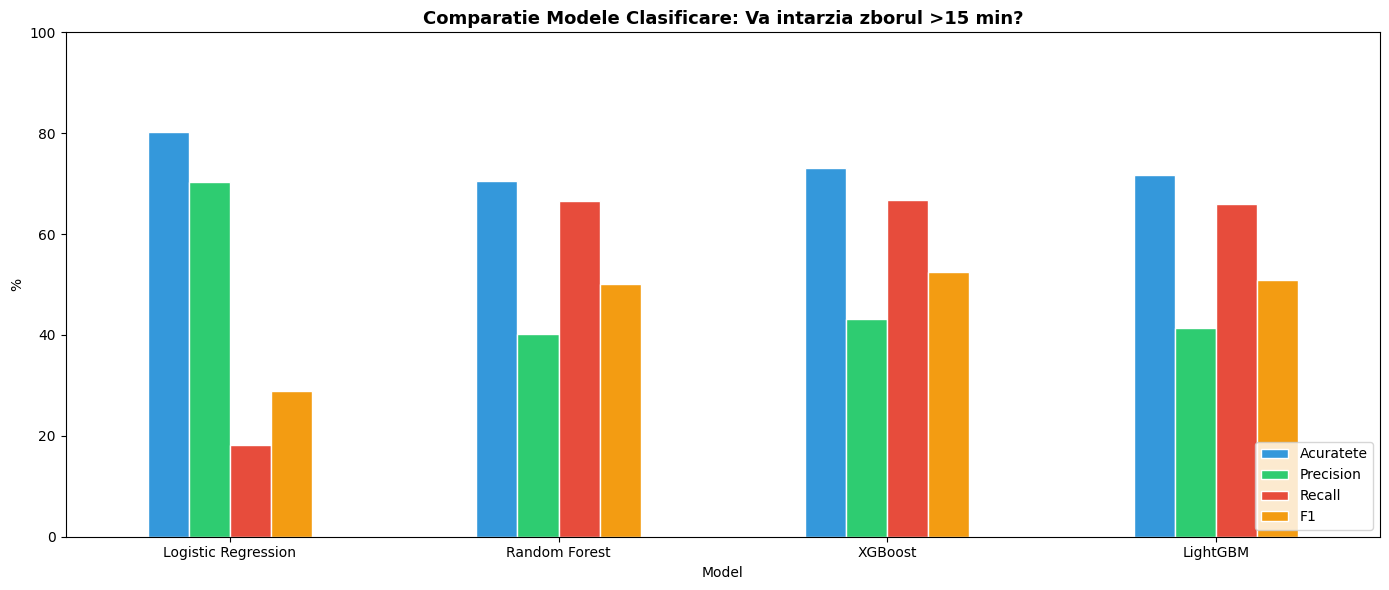

In [60]:
rezultate_cls = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest', 'XGBoost', 'LightGBM'],
    'Acuratete': [acc_lr*100, acc_rf*100, acc_xgb*100, acc_lgbm*100],
    'Precision': [prec_lr*100, prec_rf*100, prec_xgb*100, prec_lgbm*100],
    'Recall':    [rec_lr*100, rec_rf*100, rec_xgb*100, rec_lgbm*100],
    'F1':        [f1_lr*100, f1_rf*100, f1_xgb*100, f1_lgbm*100],
}).set_index('Model').round(2)

print('     COMPARATIE MODELE CLASIFICARE')
print(rezultate_cls.to_string())

# Grafic comparatie
rezultate_cls.plot(kind='bar', figsize=(14, 6), edgecolor='white',
                   color=['#3498db', '#2ecc71', '#e74c3c', '#f39c12'])
plt.title('Comparatie Modele Clasificare: Va intarzia zborul >15 min?',
          fontsize=13, fontweight='bold')
plt.ylabel('%')
plt.ylim(0, 100)
plt.xticks(rotation=0)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

Modelele de clasificare au fost antrenate pe intregul dataset de 7.7 milioane
zboruri (6,077,996 train / 1,519,499 test).

**Logistic Regression** obtine cea mai mare acuratete (80%) dar e cel mai slab
model in practica - detecteaza doar 18% din zborurile intarziate. Practic ignora
clasa "Intarziat" si prezice aproape mereu "la timp".

**Random Forest** imbunatateste semnificativ Recall-ul la 66.57% folosind
class_weight='balanced_subsample'. Detecteaza 2 din 3 zboruri intarziate dar
acuratetea scade la 70.56% — modelul e mai curajos in prezicerile sale

**XGBoost** este cel mai bun model dupa F1 (52.46%) cu Recall de 66.85%.
Parametrul scale_pos_weight corecteaza dezechilibrul dintre clase mai eficient
si obtine cel mai bun echilibru intre Precision si Recall.

**LightGBM** are rezultate similare cu XGBoost (F1=50.92%) dar usor mai slabe.
Este cel mai rapid model din comparatie pe dataset-uri mari.

**Modelul ales: XGBoost** cu F1=52.46% — cel mai bun echilibru intre
detectarea intarzierilor (Recall 66.85%) si precizia prezicerilor (Precision 43.17%).


## 19 Clasificare - Va fi anulat zborul?

### 19.1 Logistic regression

In [111]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix


In [112]:
# Logistic Regression
# Verificam valori null
print('Valori nule per coloana:')
print(X_tr_cls2.isnull().sum()[X_tr_cls2.isnull().sum() > 0])

# Completam toate valorile null cu mediana
X_tr_cls2 = X_tr_cls2.fillna(X_tr_cls2.median())
X_te_cls2 = X_te_cls2.fillna(X_tr_cls2.median())

print('Valori nule dupa fillna:', X_tr_cls2.isnull().sum().sum())
lr_cls2 = LogisticRegression(max_iter=1000, random_state=42, n_jobs=-1)
lr_cls2.fit(X_tr_cls2, y_tr_cls2)
y_pred_lr_cls2 = lr_cls2.predict(X_te_cls2)

acc_lr_cls2  = accuracy_score(y_te_cls2, y_pred_lr_cls2)
prec_lr_cls2 = precision_score(y_te_cls2, y_pred_lr_cls2, zero_division=0)
rec_lr_cls2  = recall_score(y_te_cls2, y_pred_lr_cls2, zero_division=0)
f1_lr_cls2   = f1_score(y_te_cls2, y_pred_lr_cls2, zero_division=0)

cm = confusion_matrix(y_te_cls2, y_pred_lr_cls2)
tn, fp, fn, tp = cm.ravel()

print(f'Acuratete:  {acc_lr_cls2*100:.2f}%')
print(f'Precision:  {prec_lr_cls2*100:.2f}%')
print(f'Recall:     {rec_lr_cls2*100:.2f}%')
print(f'F1:         {f1_lr_cls2*100:.2f}%')
print()
print('Confusion Matrix — Logistic Regression')
print(f'                  Prezis Nu    Prezis Da')
print(f'Real Nu           {tn:>10,}   {fp:>10,}')
print(f'Real Da           {fn:>10,}   {tp:>10,}')

print()
print(f'Corect prezise ca "Nu e anulat": {tn:,} ({tn/(tn+fp)*100:.1f}%)')
print(f'Corect prezise ca "Anulat":      {tp:,} ({tp/(tp+fn)*100:.1f}%)')
print(f'Gresit prezise ca "Nu e anulat": {fn:,} ({fn/(tp+fn)*100:.1f}%)')
print(f'Gresit prezise ca "Anulat":      {fp:,} ({fp/(tn+fp)*100:.1f}%)')

Valori nule per coloana:
ACTUAL_ELAPSED_TIME    111457
dtype: int64
Valori nule dupa fillna: 0
Acuratete:  98.47%
Precision:  15.38%
Recall:     0.01%
F1:         0.02%

Confusion Matrix — Logistic Regression
                  Prezis Nu    Prezis Da
Real Nu            1,523,709           11
Real Da               23,632            2

Corect prezise ca "Nu e anulat": 1,523,709 (100.0%)
Corect prezise ca "Anulat":      2 (0.0%)
Gresit prezise ca "Nu e anulat": 23,632 (100.0%)
Gresit prezise ca "Anulat":      11 (0.0%)


### 19.2 Random forest

In [113]:
# Random Forest
rf_cls2 = RandomForestClassifier(
    n_estimators=100, random_state=42,
    n_jobs=-1, class_weight='balanced')
X_tr_cls2 = X_tr_cls2.fillna(X_tr_cls2.median())
X_te_cls2 = X_te_cls2.fillna(X_tr_cls2.median())
rf_cls2.fit(X_tr_cls2, y_tr_cls2)
y_pred_rf_cls2 = rf_cls2.predict(X_te_cls2)

acc_rf_cls2  = accuracy_score(y_te_cls2, y_pred_rf_cls2)
prec_rf_cls2 = precision_score(y_te_cls2, y_pred_rf_cls2, zero_division=0)
rec_rf_cls2  = recall_score(y_te_cls2, y_pred_rf_cls2, zero_division=0)
f1_rf_cls2   = f1_score(y_te_cls2, y_pred_rf_cls2, zero_division=0)

cm = confusion_matrix(y_te_cls2, y_pred_rf_cls2)
tn, fp, fn, tp = cm.ravel()

print(f'Acuratete:  {acc_rf_cls2*100:.2f}%')
print(f'Precision:  {prec_rf_cls2*100:.2f}%')
print(f'Recall:     {rec_rf_cls2*100:.2f}%')
print(f'F1:         {f1_rf_cls2*100:.2f}%')
print()
print('Confusion Matrix — Random Forest')
print(f'                  Prezis Nu    Prezis Da')
print(f'Real Nu           {tn:>10,}   {fp:>10,}')
print(f'Real Da           {fn:>10,}   {tp:>10,}')

print()
print(f'Corect prezise ca "Nu e anulat": {tn:,} ({tn/(tn+fp)*100:.1f}%)')
print(f'Corect prezise ca "Anulat":      {tp:,} ({tp/(tp+fn)*100:.1f}%)')
print(f'Gresit prezise ca "Nu e anulat": {fn:,} ({fn/(tp+fn)*100:.1f}%)')
print(f'Gresit prezise ca "Anulat":      {fp:,} ({fp/(tn+fp)*100:.1f}%)')

Acuratete:  99.63%
Precision:  87.85%
Recall:     87.92%
F1:         87.88%

Confusion Matrix — Random Forest
                  Prezis Nu    Prezis Da
Real Nu            1,520,846        2,874
Real Da                2,855       20,779

Corect prezise ca "Nu e anulat": 1,520,846 (99.8%)
Corect prezise ca "Anulat":      20,779 (87.9%)
Gresit prezise ca "Nu e anulat": 2,855 (12.1%)
Gresit prezise ca "Anulat":      2,874 (0.2%)


### 19.3 XGBoost

In [114]:
# XGBoost
scale_cls2 = (y_tr_cls2 == 0).sum() / (y_tr_cls2 == 1).sum()
xgb_cls2 = XGBClassifier(
    n_estimators=100, random_state=42, n_jobs=-1,
    scale_pos_weight=scale_cls2,
    eval_metric='logloss', verbosity=0)
X_tr_cls2 = X_tr_cls2.fillna(X_tr_cls2.median())
X_te_cls2 = X_te_cls2.fillna(X_tr_cls2.median())
xgb_cls2.fit(X_tr_cls2, y_tr_cls2)
y_pred_xgb_cls2 = xgb_cls2.predict(X_te_cls2)

acc_xgb_cls2  = accuracy_score(y_te_cls2, y_pred_xgb_cls2)
prec_xgb_cls2 = precision_score(y_te_cls2, y_pred_xgb_cls2, zero_division=0)
rec_xgb_cls2  = recall_score(y_te_cls2, y_pred_xgb_cls2, zero_division=0)
f1_xgb_cls2   = f1_score(y_te_cls2, y_pred_xgb_cls2, zero_division=0)

cm = confusion_matrix(y_te_cls2, y_pred_xgb_cls2)
tn, fp, fn, tp = cm.ravel()

print(f'Acuratete:  {acc_xgb_cls2*100:.2f}%')
print(f'Precision:  {prec_xgb_cls2*100:.2f}%')
print(f'Recall:     {rec_xgb_cls2*100:.2f}%')
print(f'F1:         {f1_xgb_cls2*100:.2f}%')
print()
print('Confusion Matrix — XGBoost')
print(f'                  Prezis Nu    Prezis Da')
print(f'Real Nu           {tn:>10,}   {fp:>10,}')
print(f'Real Da           {fn:>10,}   {tp:>10,}')
print()
print(f'Corect prezise ca "Nu e anulat": {tn:,} ({tn/(tn+fp)*100:.1f}%)')
print(f'Corect prezise ca "Anulat":      {tp:,} ({tp/(tp+fn)*100:.1f}%)')
print(f'Gresit prezise ca "Nu e anulat": {fn:,} ({fn/(tp+fn)*100:.1f}%)')
print(f'Gresit prezise ca "Anulat":      {fp:,} ({fp/(tn+fp)*100:.1f}%)')

Acuratete:  99.22%
Precision:  66.13%
Recall:     99.86%
F1:         79.57%

Confusion Matrix — XGBoost
                  Prezis Nu    Prezis Da
Real Nu            1,511,630       12,090
Real Da                   33       23,601

Corect prezise ca "Nu e anulat": 1,511,630 (99.2%)
Corect prezise ca "Anulat":      23,601 (99.9%)
Gresit prezise ca "Nu e anulat": 33 (0.1%)
Gresit prezise ca "Anulat":      12,090 (0.8%)


### 19.4 LightGBM

In [115]:
# LightGBM
lgbm_cls2 = LGBMClassifier(
    n_estimators=100, random_state=42, n_jobs=-1,
    class_weight='balanced', verbosity=-1)
X_tr_cls2 = X_tr_cls2.fillna(X_tr_cls2.median())
X_te_cls2 = X_te_cls2.fillna(X_tr_cls2.median())
lgbm_cls2.fit(X_tr_cls2, y_tr_cls2)
y_pred_lgbm_cls2 = lgbm_cls2.predict(X_te_cls2)

acc_lgbm_cls2  = accuracy_score(y_te_cls2, y_pred_lgbm_cls2)
prec_lgbm_cls2 = precision_score(y_te_cls2, y_pred_lgbm_cls2, zero_division=0)
rec_lgbm_cls2  = recall_score(y_te_cls2, y_pred_lgbm_cls2, zero_division=0)
f1_lgbm_cls2   = f1_score(y_te_cls2, y_pred_lgbm_cls2, zero_division=0)

cm = confusion_matrix(y_te_cls2, y_pred_lgbm_cls2)
tn, fp, fn, tp = cm.ravel()

print(f'Acuratete:  {acc_lgbm_cls2*100:.2f}%')
print(f'Precision:  {prec_lgbm_cls2*100:.2f}%')
print(f'Recall:     {rec_lgbm_cls2*100:.2f}%')
print(f'F1:         {f1_lgbm_cls2*100:.2f}%')
print()
print('Confusion Matrix — LightGBM')
print(f'                  Prezis Nu    Prezis Da')
print(f'Real Nu           {tn:>10,}   {fp:>10,}')
print(f'Real Da           {fn:>10,}   {tp:>10,}')

print()
print(f'Corect prezise ca "Nu e anulat": {tn:,} ({tn/(tn+fp)*100:.1f}%)')
print(f'Corect prezise ca "Anulat":      {tp:,} ({tp/(tp+fn)*100:.1f}%)')
print(f'Gresit prezise ca "Nu e anulat": {fn:,} ({fn/(tp+fn)*100:.1f}%)')
print(f'Gresit prezise ca "Anulat":      {fp:,} ({fp/(tn+fp)*100:.1f}%)')

Acuratete:  99.21%
Precision:  66.00%
Recall:     99.83%
F1:         79.47%

Confusion Matrix — LightGBM
                  Prezis Nu    Prezis Da
Real Nu            1,511,567       12,153
Real Da                   39       23,595

Corect prezise ca "Nu e anulat": 1,511,567 (99.2%)
Corect prezise ca "Anulat":      23,595 (99.8%)
Gresit prezise ca "Nu e anulat": 39 (0.2%)
Gresit prezise ca "Anulat":      12,153 (0.8%)


### 19.5 Comparatie Modele Clasificare

   COMPARATIE MODELE - VA FI ZBORUL ANULAT?
                     Acuratete  Precision  Recall     F1
Model                                                   
Logistic Regression      98.47      11.11    0.00   0.01
Random Forest            99.62      87.67   87.68  87.68
XGBoost                  99.22      66.13   99.86  79.57
LightGBM                 99.21      66.00   99.83  79.47


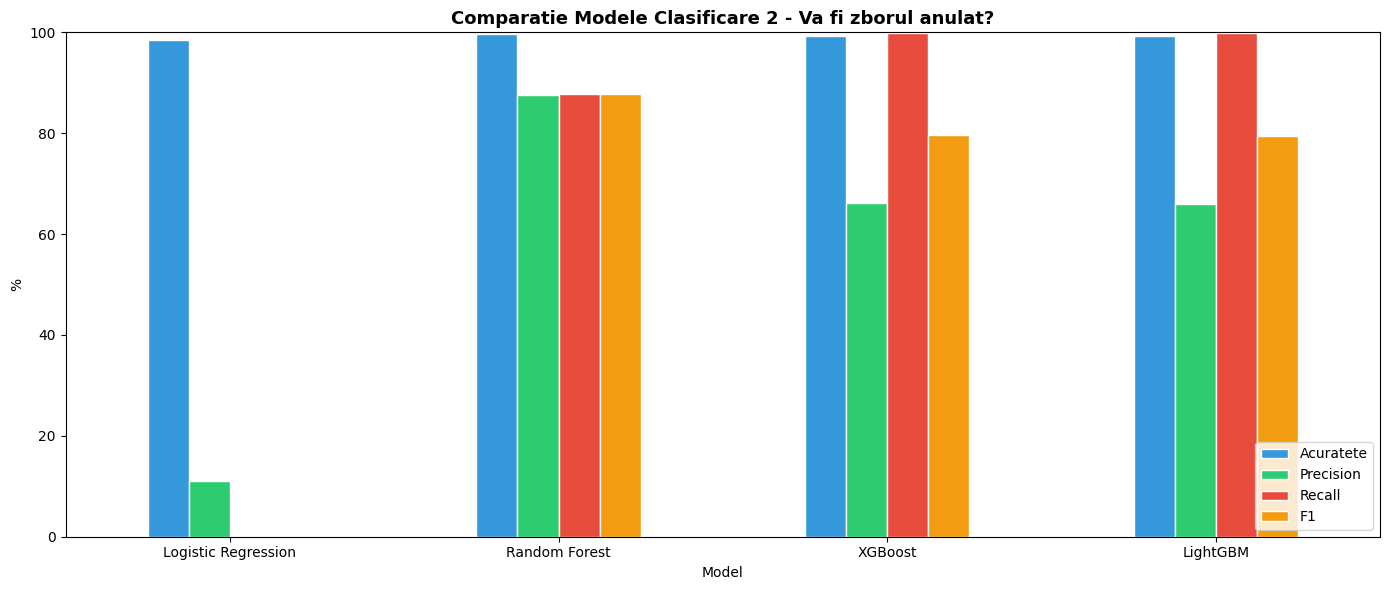

In [101]:
# Comparatie
rezultate_cls2 = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest', 'XGBoost', 'LightGBM'],
    'Acuratete': [acc_lr_cls2*100, acc_rf_cls2*100, acc_xgb_cls2*100, acc_lgbm_cls2*100],
    'Precision': [prec_lr_cls2*100, prec_rf_cls2*100, prec_xgb_cls2*100, prec_lgbm_cls2*100],
    'Recall':    [rec_lr_cls2*100, rec_rf_cls2*100, rec_xgb_cls2*100, rec_lgbm_cls2*100],
    'F1':        [f1_lr_cls2*100, f1_rf_cls2*100, f1_xgb_cls2*100, f1_lgbm_cls2*100],
}).set_index('Model').round(2)

print('   COMPARATIE MODELE - VA FI ZBORUL ANULAT?')
print(rezultate_cls2.to_string())

rezultate_cls2.plot(kind='bar', figsize=(14, 6), edgecolor='white',
                    color=['#3498db', '#2ecc71', '#e74c3c', '#f39c12'])
plt.title('Comparatie Modele Clasificare 2 - Va fi zborul anulat?',
          fontsize=13, fontweight='bold')
plt.ylabel('%')
plt.ylim(0, 100)
plt.xticks(rotation=0)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

Toate cele 4 modele au fost antrenate pe 7.7 milioane zboruri cu un dezechilibru
extrem de clase, doar 1.53% din zboruri sunt anulate.

**Logistic Regression** e complet inutil pentru acest caz - detecteaza practic
0 zboruri anulate (Recall=0%). Prezice mereu "nu e anulat" si obtine 98.47%
acuratete doar din cauza dezechilibrului extrem de clase.

**Random Forest** este cel mai bun model cu F1=87.68%.
Detecteaza 87.68% din zborurile anulate (Recall) si cand prezice o anulare
are dreptate in 87.67% din cazuri (Precision). Cel mai echilibrat model.

**XGBoost** obtine Recall aproape perfect (99.86%) - detecteaza practic toate
zborurile anulate. Totusi Precision e mai mica (66.13%) - din 3 zboruri
prezise ca anulate, 1 e fals alarm. F1=79.57%.

**LightGBM** are rezultate aproape identice cu XGBoost -
Recall=99.83%, Precision=66%, F1=79.47%.

**Modelul ales: Random Forest** cu F1=87.68% - cel mai bun echilibru
intre detectarea anularilor reale (Recall 87.68%) si evitarea
falselor alarme (Precision 87.67%).

## 20. Regresie - Cu cate minute va intarzia zborul la plecare?

### 20.1 Linear Regression (baseline) 

In [73]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
# Model liniar simplu — baseline
lin_reg_v3 = LinearRegression()
lin_reg_v3.fit(X_tr_v3, y_tr_v3)
y_pred_linreg_v3 = lin_reg_v3.predict(X_te_v3)

mae_linreg_v3  = mean_absolute_error(y_te_v3, y_pred_linreg_v3)
rmse_linreg_v3 = np.sqrt(mean_squared_error(y_te_v3, y_pred_linreg_v3))
r2_linreg_v3   = r2_score(y_te_v3, y_pred_linreg_v3)

print(f'Eroare Medie Absoluta (MAE):    {mae_linreg_v3:.2f} minute')
print(f'Eroare Patratica Medie (RMSE):  {rmse_linreg_v3:.2f} minute')
print(f'Coeficient de Determinare (R2): {r2_linreg_v3:.4f}')
print(f'Modelul explica {r2_linreg_v3*100:.1f}% din variabilitatea intarzierilor')

Eroare Medie Absoluta (MAE):    37.77 minute
Eroare Patratica Medie (RMSE):  57.84 minute
Coeficient de Determinare (R2): 0.0247
Modelul explica 2.5% din variabilitatea intarzierilor


### 20.2 Decision tree


In [74]:
from sklearn.tree import DecisionTreeRegressor

# Un singur arbore de decizie
dt_reg_v3 = DecisionTreeRegressor(
    random_state=42,
    max_depth=10
)
dt_reg_v3.fit(X_tr_v3, y_tr_v3)
y_pred_dt_v3 = dt_reg_v3.predict(X_te_v3)

mae_dt_v3  = mean_absolute_error(y_te_v3, y_pred_dt_v3)
rmse_dt_v3 = np.sqrt(mean_squared_error(y_te_v3, y_pred_dt_v3))
r2_dt_v3   = r2_score(y_te_v3, y_pred_dt_v3)

print(f'Eroare Medie Absoluta (MAE):    {mae_dt_v3:.2f} minute')
print(f'Eroare Patratica Medie (RMSE):  {rmse_dt_v3:.2f} minute')
print(f'Coeficient de Determinare (R2): {r2_dt_v3:.4f}')
print(f'Modelul explica {r2_dt_v3*100:.1f}% din variabilitatea intarzierilor')

Eroare Medie Absoluta (MAE):    37.11 minute
Eroare Patratica Medie (RMSE):  57.19 minute
Coeficient de Determinare (R2): 0.0465
Modelul explica 4.7% din variabilitatea intarzierilor


### 20.3 Random Forest Regressor

In [76]:
from sklearn.ensemble import RandomForestRegressor

# 100 arbori de decizie care voteaza impreuna
rf_reg_v3 = RandomForestRegressor(
    n_estimators=100, random_state=42,
    n_jobs=-1, max_depth=15, min_samples_leaf=5)
rf_reg_v3.fit(X_tr_v3, y_tr_v3)
y_pred_rf_v3 = rf_reg_v3.predict(X_te_v3)

mae_rf_v3  = mean_absolute_error(y_te_v3, y_pred_rf_v3)
rmse_rf_v3 = np.sqrt(mean_squared_error(y_te_v3, y_pred_rf_v3))
r2_rf_v3   = r2_score(y_te_v3, y_pred_rf_v3)

print(f'Eroare Medie Absoluta (MAE):    {mae_rf_v3:.2f} minute')
print(f'Eroare Patratica Medie (RMSE):  {rmse_rf_v3:.2f} minute')
print(f'Coeficient de Determinare (R2): {r2_rf_v3:.4f}')
print(f'Modelul explica {r2_rf_v3*100:.1f}% din variabilitatea intarzierilor')

Eroare Medie Absoluta (MAE):    36.17 minute
Eroare Patratica Medie (RMSE):  56.02 minute
Coeficient de Determinare (R2): 0.0852
Modelul explica 8.5% din variabilitatea intarzierilor


### 20.4 XGBoost Regressor

In [77]:
from xgboost import XGBRegressor
# Arbori secventiali — fiecare corecteaza erorile celui anterior
xgb_reg_v3 = XGBRegressor(
    n_estimators=100, random_state=42,
    n_jobs=-1, verbosity=0,
    max_depth=6, learning_rate=0.1)
xgb_reg_v3.fit(X_tr_v3, y_tr_v3)
y_pred_xgb_v3 = xgb_reg_v3.predict(X_te_v3)

mae_xgb_v3  = mean_absolute_error(y_te_v3, y_pred_xgb_v3)
rmse_xgb_v3 = np.sqrt(mean_squared_error(y_te_v3, y_pred_xgb_v3))
r2_xgb_v3   = r2_score(y_te_v3, y_pred_xgb_v3)

print(f'Eroare Medie Absoluta (MAE):    {mae_xgb_v3:.2f} minute')
print(f'Eroare Patratica Medie (RMSE):  {rmse_xgb_v3:.2f} minute')
print(f'Coeficient de Determinare (R2): {r2_xgb_v3:.4f}')
print(f'Modelul explica {r2_xgb_v3*100:.1f}% din variabilitatea intarzierilor')

Eroare Medie Absoluta (MAE):    36.51 minute
Eroare Patratica Medie (RMSE):  56.41 minute
Coeficient de Determinare (R2): 0.0724
Modelul explica 7.2% din variabilitatea intarzierilor


### 20.5 LightGBM Regressor

In [78]:
from lightgbm import LGBMRegressor

# Cel mai rapid algoritm pe date mari
lgbm_reg_v3 = LGBMRegressor(
    n_estimators=100, random_state=42,
    n_jobs=-1, verbosity=-1,
    max_depth=10, learning_rate=0.1, num_leaves=50)
lgbm_reg_v3.fit(X_tr_v3, y_tr_v3)
y_pred_lgbm_v3 = lgbm_reg_v3.predict(X_te_v3)

mae_lgbm_v3  = mean_absolute_error(y_te_v3, y_pred_lgbm_v3)
rmse_lgbm_v3 = np.sqrt(mean_squared_error(y_te_v3, y_pred_lgbm_v3))
r2_lgbm_v3   = r2_score(y_te_v3, y_pred_lgbm_v3)

print(f'Eroare Medie Absoluta (MAE):    {mae_lgbm_v3:.2f} minute')
print(f'Eroare Patratica Medie (RMSE):  {rmse_lgbm_v3:.2f} minute')
print(f'Coeficient de Determinare (R2): {r2_lgbm_v3:.4f}')
print(f'Modelul explica {r2_lgbm_v3*100:.1f}% din variabilitatea intarzierilor')

Eroare Medie Absoluta (MAE):    36.32 minute
Eroare Patratica Medie (RMSE):  56.12 minute
Coeficient de Determinare (R2): 0.0817
Modelul explica 8.2% din variabilitatea intarzierilor


### 20.6 Comparatie Modele Regresie

    COMPARATIE MODELE REGRESIE V3 
    Prezicere intarziere PLECARE 
                   MAE (minute)  RMSE (minute)      R2
Model                                                 
Linear Regression       37.7651        57.8391  0.0247
Decision Tree           37.1106        57.1890  0.0465
Random Forest           36.1749        56.0176  0.0852
XGBoost                 36.5078        56.4083  0.0724
LightGBM                36.3221        56.1248  0.0817


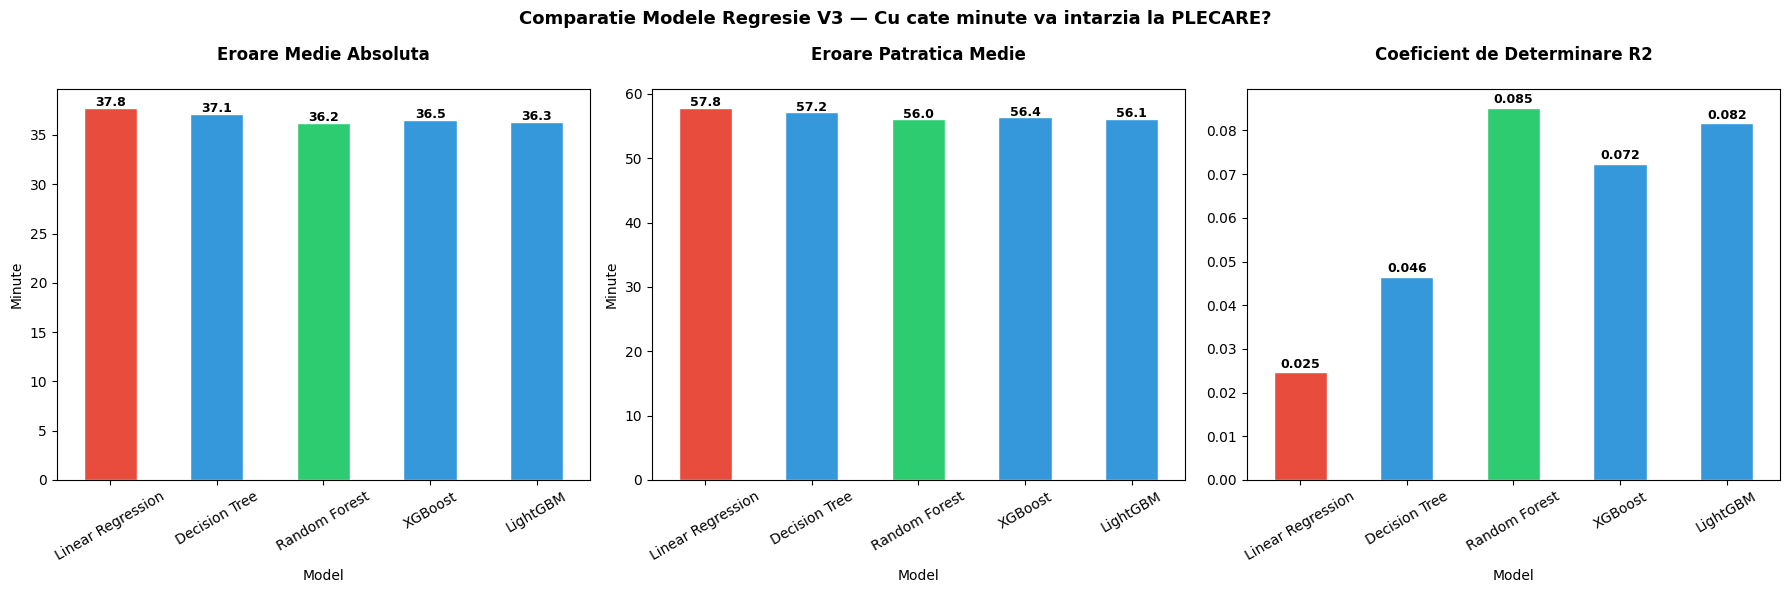

In [81]:
rezultate_reg_v3 = pd.DataFrame({
    'Model': ['Linear Regression', 'Decision Tree', 'Random Forest', 'XGBoost', 'LightGBM'],
    'MAE (minute)':  [mae_linreg_v3, mae_dt_v3, mae_rf_v3, mae_xgb_v3, mae_lgbm_v3],
    'RMSE (minute)': [rmse_linreg_v3, rmse_dt_v3, rmse_rf_v3, rmse_xgb_v3, rmse_lgbm_v3],
    'R2':            [r2_linreg_v3, r2_dt_v3, r2_rf_v3, r2_xgb_v3, r2_lgbm_v3],
}).set_index('Model').round(4)

print('    COMPARATIE MODELE REGRESIE V3 ')
print('    Prezicere intarziere PLECARE ')
print(rezultate_reg_v3.to_string())

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

colors_mae = ['#2ecc71' if v == rezultate_reg_v3['MAE (minute)'].min()
              else '#e74c3c' if v == rezultate_reg_v3['MAE (minute)'].max()
              else '#3498db' for v in rezultate_reg_v3['MAE (minute)']]
rezultate_reg_v3['MAE (minute)'].plot(kind='bar', ax=axes[0], color=colors_mae, edgecolor='white')
axes[0].set_title('Eroare Medie Absoluta\n', fontweight='bold')
axes[0].set_ylabel('Minute')
axes[0].tick_params(axis='x', rotation=30)
for i, v in enumerate(rezultate_reg_v3['MAE (minute)']):
    axes[0].text(i, v + 0.2, f'{v:.1f}', ha='center', fontsize=9, fontweight='bold')

colors_rmse = ['#2ecc71' if v == rezultate_reg_v3['RMSE (minute)'].min()
               else '#e74c3c' if v == rezultate_reg_v3['RMSE (minute)'].max()
               else '#3498db' for v in rezultate_reg_v3['RMSE (minute)']]
rezultate_reg_v3['RMSE (minute)'].plot(kind='bar', ax=axes[1], color=colors_rmse, edgecolor='white')
axes[1].set_title('Eroare Patratica Medie\n', fontweight='bold')
axes[1].set_ylabel('Minute')
axes[1].tick_params(axis='x', rotation=30)
for i, v in enumerate(rezultate_reg_v3['RMSE (minute)']):
    axes[1].text(i, v + 0.2, f'{v:.1f}', ha='center', fontsize=9, fontweight='bold')

colors_r2 = ['#2ecc71' if v == rezultate_reg_v3['R2'].max()
             else '#e74c3c' if v == rezultate_reg_v3['R2'].min()
             else '#3498db' for v in rezultate_reg_v3['R2']]
rezultate_reg_v3['R2'].plot(kind='bar', ax=axes[2], color=colors_r2, edgecolor='white')
axes[2].set_title('Coeficient de Determinare R2\n', fontweight='bold')
axes[2].tick_params(axis='x', rotation=30)
for i, v in enumerate(rezultate_reg_v3['R2']):
    axes[2].text(i, v + 0.001, f'{v:.3f}', ha='center', fontsize=9, fontweight='bold')

plt.suptitle('Comparatie Modele Regresie V3 — Cu cate minute va intarzia la PLECARE?',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


Toate cele 5 modele au fost antrenate pe 2.24 milioane zboruri care au intarziat
la plecare (DEP_DELAY > 0) si testate pe 560k zboruri nevazute anterior.

**Linear Regression** e cel mai slab  R2=2.47% confirma ca relatia dintre
features si intarzierea la plecare nu e liniara. MAE=37.77 minute.

**Decision Tree** imbunatateste putin - R2=4.65%, MAE=37.11 minute.
Un singur arbore de decizie captureaza partial patterns neliniare.

**Random Forest** este cel mai bun model cu R2=8.52% si MAE=36.17 minute.
100 de arbori de decizie impreuna captureaza mai bine complexitatea datelor.

**XGBoost** obtine R2=7.24% usor mai slab decat Random Forest in acest caz.

**LightGBM** e al doilea cel mai bun cu R2=8.17% si MAE=36.32 minute 
foarte aproape de Random Forest.

**Modelul ales: Random Forest** cu R2=8.52% si MAE=36.17 minute.

**Observatie importanta:** R2 scazut (~8%) confirma ca intarzierea la plecare
este greu de prezis fara date externe. Totusi adaugarea historical features
(ROUTE_AVG_DELAY, CARRIER_AVG_DELAY etc.) a imbunatatit R2 de la 5% la 8%
fata de modelul fara aceste features.

**Limitare principala:** Intarzierea la plecare depinde masiv de factori
necunoscuti inainte de zbor - probleme tehnice la avion, vreme, intarzierea
zborului anterior al aceluiasi avion. Fara aceste date, 8% R2 reprezinta
maximul realist pentru acest scenariu.

## 21. Regresie - Cu cate minute va intarzia zborul la sosire?

### 21.1 Linear Regression

In [88]:
lin_reg_v2 = LinearRegression()
lin_reg_v2.fit(X_tr_v2, y_tr_v2)
y_pred_linreg_v2 = lin_reg_v2.predict(X_te_v2)

mae_linreg_v2  = mean_absolute_error(y_te_v2, y_pred_linreg_v2)
rmse_linreg_v2 = np.sqrt(mean_squared_error(y_te_v2, y_pred_linreg_v2))
r2_linreg_v2   = r2_score(y_te_v2, y_pred_linreg_v2)

print(f'Eroare Medie Absoluta (MAE):    {mae_linreg_v2:.2f} minute')
print(f'Eroare Patratica Medie (RMSE):  {rmse_linreg_v2:.2f} minute')
print(f'Coeficient de Determinare (R2): {r2_linreg_v2:.4f}')

Eroare Medie Absoluta (MAE):    7.50 minute
Eroare Patratica Medie (RMSE):  9.93 minute
Coeficient de Determinare (R2): 0.9766


### 21.2 Decision Tree

In [89]:
from sklearn.tree import DecisionTreeRegressor

dt_reg_v2 = DecisionTreeRegressor(
    random_state=42,
    max_depth=10
)

dt_reg_v2.fit(X_tr_v2, y_tr_v2)
y_pred_dt_v2 = dt_reg_v2.predict(X_te_v2)

mae_dt_v2  = mean_absolute_error(y_te_v2, y_pred_dt_v2)
rmse_dt_v2 = np.sqrt(mean_squared_error(y_te_v2, y_pred_dt_v2))
r2_dt_v2   = r2_score(y_te_v2, y_pred_dt_v2)

print(f'Eroare Medie Absoluta (MAE):    {mae_dt_v2:.2f} minute')
print(f'Eroare Patratica Medie (RMSE):  {rmse_dt_v2:.2f} minute')
print(f'Coeficient de Determinare (R2): {r2_dt_v2:.4f}')

Eroare Medie Absoluta (MAE):    8.65 minute
Eroare Patratica Medie (RMSE):  12.37 minute
Coeficient de Determinare (R2): 0.9637


### 21.3 Random Forest V2


In [90]:
rf_reg_v2 = RandomForestRegressor(
    n_estimators=100, random_state=42,
    n_jobs=-1, max_depth=15, min_samples_leaf=5)
rf_reg_v2.fit(X_tr_v2, y_tr_v2)
y_pred_rf_v2 = rf_reg_v2.predict(X_te_v2)

mae_rf_v2  = mean_absolute_error(y_te_v2, y_pred_rf_v2)
rmse_rf_v2 = np.sqrt(mean_squared_error(y_te_v2, y_pred_rf_v2))
r2_rf_v2   = r2_score(y_te_v2, y_pred_rf_v2)

print(f'Eroare Medie Absoluta (MAE):    {mae_rf_v2:.2f} minute')
print(f'Eroare Patratica Medie (RMSE):  {rmse_rf_v2:.2f} minute')
print(f'Coeficient de Determinare (R2): {r2_rf_v2:.4f}')

Eroare Medie Absoluta (MAE):    6.62 minute
Eroare Patratica Medie (RMSE):  9.20 minute
Coeficient de Determinare (R2): 0.9799


### 21.4 XGBBoost 

In [91]:
xgb_reg_v2 = XGBRegressor(
    n_estimators=100, random_state=42,
    n_jobs=-1, verbosity=0,
    max_depth=6, learning_rate=0.1)
xgb_reg_v2.fit(X_tr_v2, y_tr_v2)
y_pred_xgb_v2 = xgb_reg_v2.predict(X_te_v2)

mae_xgb_v2  = mean_absolute_error(y_te_v2, y_pred_xgb_v2)
rmse_xgb_v2 = np.sqrt(mean_squared_error(y_te_v2, y_pred_xgb_v2))
r2_xgb_v2   = r2_score(y_te_v2, y_pred_xgb_v2)

print(f'Eroare Medie Absoluta (MAE):    {mae_xgb_v2:.2f} minute')
print(f'Eroare Patratica Medie (RMSE):  {rmse_xgb_v2:.2f} minute')
print(f'Coeficient de Determinare (R2): {r2_xgb_v2:.4f}')

Eroare Medie Absoluta (MAE):    6.19 minute
Eroare Patratica Medie (RMSE):  8.53 minute
Coeficient de Determinare (R2): 0.9828


### 21.5 LightGBM 

In [92]:
lgbm_reg_v2 = LGBMRegressor(
    n_estimators=100, random_state=42,
    n_jobs=-1, verbosity=-1,
    max_depth=10, learning_rate=0.1, num_leaves=50)
lgbm_reg_v2.fit(X_tr_v2, y_tr_v2)
y_pred_lgbm_v2 = lgbm_reg_v2.predict(X_te_v2)

mae_lgbm_v2  = mean_absolute_error(y_te_v2, y_pred_lgbm_v2)
rmse_lgbm_v2 = np.sqrt(mean_squared_error(y_te_v2, y_pred_lgbm_v2))
r2_lgbm_v2   = r2_score(y_te_v2, y_pred_lgbm_v2)

print(f'Eroare Medie Absoluta (MAE):    {mae_lgbm_v2:.2f} minute')
print(f'Eroare Patratica Medie (RMSE):  {rmse_lgbm_v2:.2f} minute')
print(f'Coeficient de Determinare (R2): {r2_lgbm_v2:.4f}')

Eroare Medie Absoluta (MAE):    5.71 minute
Eroare Patratica Medie (RMSE):  7.63 minute
Coeficient de Determinare (R2): 0.9862


### 21.6 Comparatie Modele Regresie 

    COMPARATIE MODELE REGRESIE V2 
    Prezicere intarziere sosire cu DEP_DELAY cunoscut 
                   MAE (minute)  RMSE (minute)      R2
Model                                                 
Linear Regression        7.4968         9.9334  0.9766
Decision Tree            8.6539        12.3731  0.9637
Random Forest            6.6195         9.2050  0.9799
XGBoost                  6.1857         8.5268  0.9828
LightGBM                 5.7126         7.6283  0.9862


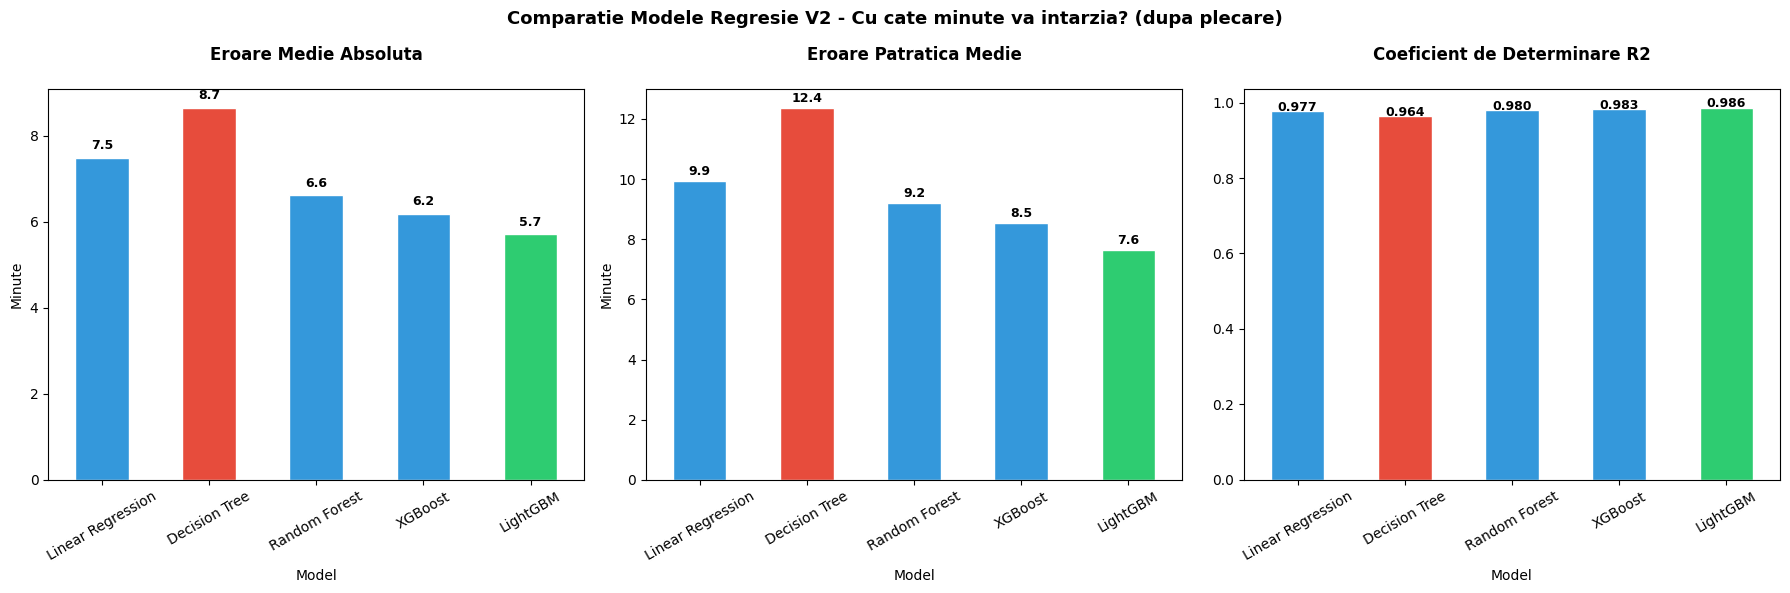

In [93]:
rezultate_reg_v2 = pd.DataFrame({
    'Model': ['Linear Regression', 'Decision Tree', 'Random Forest', 'XGBoost', 'LightGBM'],
    'MAE (minute)':  [mae_linreg_v2, mae_dt_v2, mae_rf_v2, mae_xgb_v2, mae_lgbm_v2],
    'RMSE (minute)': [rmse_linreg_v2, rmse_dt_v2, rmse_rf_v2, rmse_xgb_v2, rmse_lgbm_v2],
    'R2':            [r2_linreg_v2, r2_dt_v2, r2_rf_v2, r2_xgb_v2, r2_lgbm_v2],
}).set_index('Model').round(4)

print('    COMPARATIE MODELE REGRESIE V2 ')
print('    Prezicere intarziere sosire cu DEP_DELAY cunoscut ')
print(rezultate_reg_v2.to_string())

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

colors_mae = ['#2ecc71' if v == rezultate_reg_v2['MAE (minute)'].min()
              else '#e74c3c' if v == rezultate_reg_v2['MAE (minute)'].max()
              else '#3498db' for v in rezultate_reg_v2['MAE (minute)']]
rezultate_reg_v2['MAE (minute)'].plot(kind='bar', ax=axes[0], color=colors_mae, edgecolor='white')
axes[0].set_title('Eroare Medie Absoluta\n', fontweight='bold')
axes[0].set_ylabel('Minute')
axes[0].tick_params(axis='x', rotation=30)
for i, v in enumerate(rezultate_reg_v2['MAE (minute)']):
    axes[0].text(i, v + 0.2, f'{v:.1f}', ha='center', fontsize=9, fontweight='bold')

colors_rmse = ['#2ecc71' if v == rezultate_reg_v2['RMSE (minute)'].min()
               else '#e74c3c' if v == rezultate_reg_v2['RMSE (minute)'].max()
               else '#3498db' for v in rezultate_reg_v2['RMSE (minute)']]
rezultate_reg_v2['RMSE (minute)'].plot(kind='bar', ax=axes[1], color=colors_rmse, edgecolor='white')
axes[1].set_title('Eroare Patratica Medie\n', fontweight='bold')
axes[1].set_ylabel('Minute')
axes[1].tick_params(axis='x', rotation=30)
for i, v in enumerate(rezultate_reg_v2['RMSE (minute)']):
    axes[1].text(i, v + 0.2, f'{v:.1f}', ha='center', fontsize=9, fontweight='bold')

colors_r2 = ['#2ecc71' if v == rezultate_reg_v2['R2'].max()
             else '#e74c3c' if v == rezultate_reg_v2['R2'].min()
             else '#3498db' for v in rezultate_reg_v2['R2']]
rezultate_reg_v2['R2'].plot(kind='bar', ax=axes[2], color=colors_r2, edgecolor='white')
axes[2].set_title('Coeficient de Determinare R2\n', fontweight='bold')
axes[2].tick_params(axis='x', rotation=30)
for i, v in enumerate(rezultate_reg_v2['R2']):
    axes[2].text(i, v + 0.001, f'{v:.3f}', ha='center', fontsize=9, fontweight='bold')

plt.suptitle('Comparatie Modele Regresie V2 - Cu cate minute va intarzia? (dupa plecare)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

Toate cele 5 modele au fost antrenate pe zboruri care au plecat intarziat
si testate pe date nevazute anterior. Spre deosebire de cealata varianta, aici modelul
stie deja cat a intarziat zborul la plecare (DEP_DELAY).

**Linear Regression** obtine deja un R2 exceptional de 97.66% - confirma
corelatie puternica (r=0.937) dintre DEP_DELAY si ARR_DELAY observata in EDA.
In medie greseste cu doar 7.50 minute.

**Decision Tree** e cel mai slab din V2 cu R2=96.37% si MAE=8.65 minute.
Un singur arbore overfitteaza usor - R2 mai mic decat Linear Regression.

**Random Forest** imbunatateste la R2=97.99% si MAE=6.62 minute.
100 de arbori corecteaza erorile individual si generalizeaza mai bine.

**XGBoost** obtine R2=98.28% si MAE=6.19 minute - al doilea cel mai bun.
Invatarea secventiala corecteaza erorile precedentilor arbori eficient.

**LightGBM** este cel mai bun model cu R2=98.62% si MAE=5.71 minute.
In medie greseste cu mai putin de 6 minute - suficient de precis pentru
uz practic real.

**Modelul ales: LightGBM** cu R2=98.62% si MAE=5.71 minute.

**Concluzii:** Comparand cele doua preziceri adaugarea unui singur feature
(DEP_DELAY) a transformat R2 de la 8% la 98.62%. Aceasta confirma ca
intarzierea la plecare este predictorul dominant pentru intarzierea la sosire.
Daca stii cat a intarziat zborul la plecare, poti prezice sosirea cu
precizie de 6 minute.

## 22. Quality Analysis

### 22.1 ROC Curve - Clasificare 1 (intarziere)

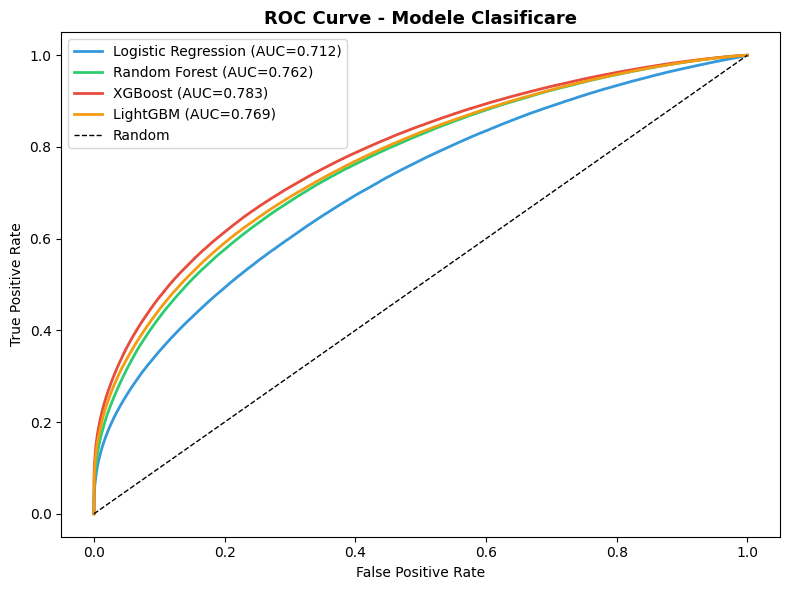

In [95]:
from sklearn.metrics import roc_curve, roc_auc_score

fig, ax = plt.subplots(figsize=(8, 6))

for model, name, color in [
    (lr,   'Logistic Regression', '#3498db'),
    (rf,   'Random Forest',       '#2ecc71'),
    (xgb,  'XGBoost',             '#e74c3c'),
    (lgbm, 'LightGBM',            '#f39c12')
]:
    y_prob = model.predict_proba(X_te_cls)[:, 1]
    fpr, tpr, _ = roc_curve(y_te_cls, y_prob)
    auc = roc_auc_score(y_te_cls, y_prob)
    ax.plot(fpr, tpr, lw=2, color=color, label=f'{name} (AUC={auc:.3f})')

ax.plot([0,1], [0,1], 'k--', lw=1, label='Random')
ax.set_title('ROC Curve - Modele Clasificare', fontsize=13, fontweight='bold')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.legend()
plt.tight_layout()
plt.show()

### 22.2 ROC Curve - Clasificare 2 (anulare)

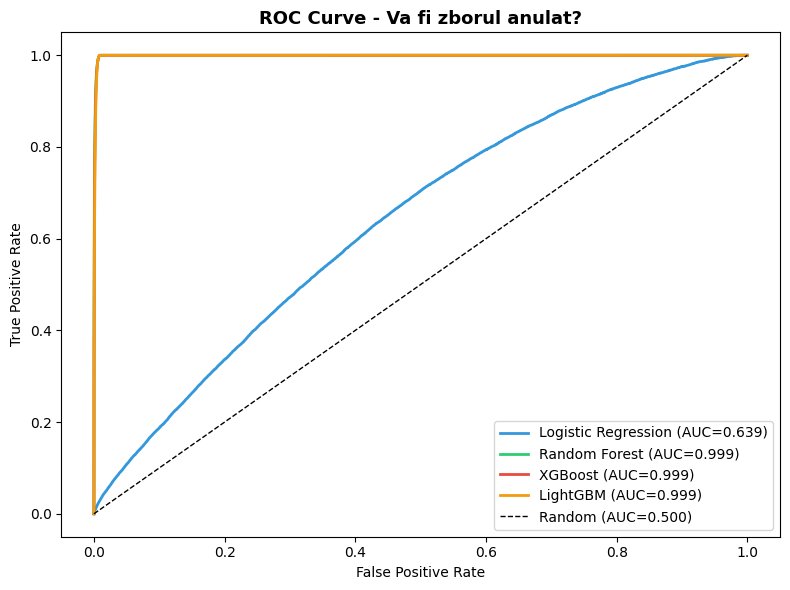

In [101]:
fig, ax = plt.subplots(figsize=(8, 6))

for model, name, color in [
    (lr_cls2,   'Logistic Regression', '#3498db'),
    (rf_cls2,   'Random Forest',       '#2ecc71'),
    (xgb_cls2,  'XGBoost',             '#e74c3c'),
    (lgbm_cls2, 'LightGBM',            '#f39c12')
]:
    y_prob2 = model.predict_proba(X_te_cls2)[:, 1]
    fpr2, tpr2, _ = roc_curve(y_te_cls2, y_prob2)
    auc2 = roc_auc_score(y_te_cls2, y_prob2)
    ax.plot(fpr2, tpr2, lw=2, color=color, label=f'{name} (AUC={auc2:.3f})')

ax.plot([0,1], [0,1], 'k--', lw=1, label='Random (AUC=0.500)')
ax.set_title('ROC Curve - Va fi zborul anulat?', fontsize=13, fontweight='bold')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

### 22.3 Feature Importance - Clasificare 1 Ce factori prezic cel mai bine intarzierea

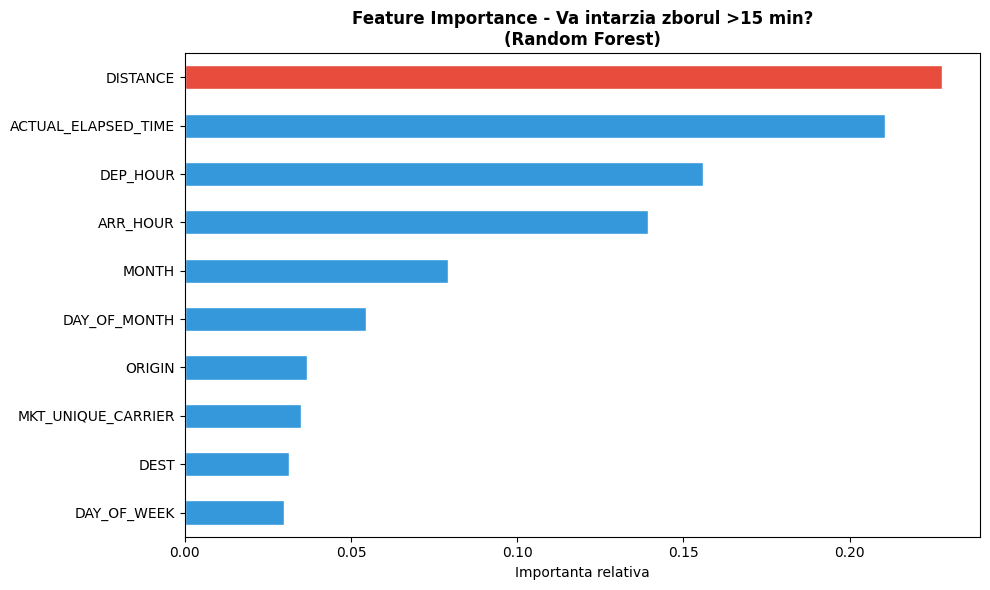

In [106]:
importances_cls1 = pd.Series(
    rf.feature_importances_,
    index=X_tr_cls.columns
).sort_values()

fig, ax = plt.subplots(figsize=(10, 6))
colors_fi = ['#e74c3c' if v == importances_cls1.max()
             else '#3498db' for v in importances_cls1]
importances_cls1.plot(kind='barh', ax=ax, color=colors_fi, edgecolor='white')
ax.set_title('Feature Importance - Va intarzia zborul >15 min?\n(Random Forest)',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Importanta relativa')
plt.tight_layout()
plt.show()

### 22.4. Feature Importance - Clasificare 2 Ce factori prezic cel mai bine anularea

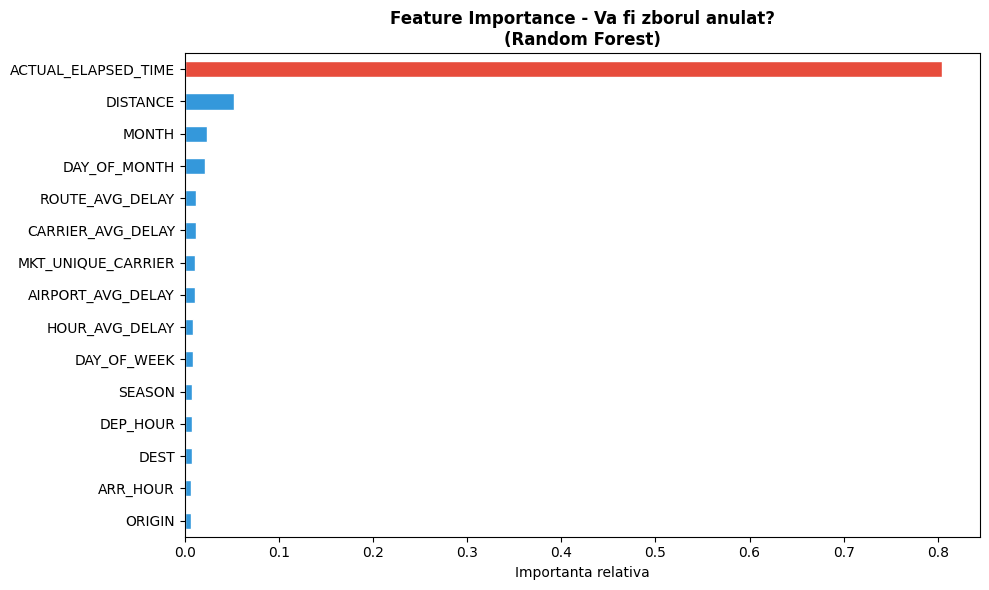

In [116]:
importances_cls2 = pd.Series(
    rf_cls2.feature_importances_,
    index=X_tr_cls2.columns
).sort_values()

fig, ax = plt.subplots(figsize=(10, 6))
colors_fi2 = ['#e74c3c' if v == importances_cls2.max()
              else '#3498db' for v in importances_cls2]
importances_cls2.plot(kind='barh', ax=ax, color=colors_fi2, edgecolor='white')
ax.set_title('Feature Importance - Va fi zborul anulat?\n(Random Forest)',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Importanta relativa')
plt.tight_layout()
plt.show()

### 22.5 Optimizare Hiperparametri - RandomizedSearchCV 

In [119]:
from sklearn.model_selection import RandomizedSearchCV
param_dist = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [5, 10, 15, 20],
    'min_samples_leaf': [5, 10, 20],
    'max_features': ['sqrt', 'log2', 0.5]
}

rnd_search_v2 = RandomizedSearchCV(
    RandomForestRegressor(random_state=42, n_jobs=-1),
    param_distributions=param_dist,
    n_iter=10, cv=5,
    scoring='neg_root_mean_squared_error',
    random_state=42, n_jobs=-1, verbose=1
)

rnd_search_v2.fit(X_tr_v2, y_tr_v2)

print(f'\nCei mai buni parametri: {rnd_search_v2.best_params_}')
print(f'Cel mai bun RMSE cross-val: {-rnd_search_v2.best_score_:.2f} minute')

best_rf_v2 = rnd_search_v2.best_estimator_
y_pred_best_v2 = best_rf_v2.predict(X_te_v2)

mae_best_v2  = mean_absolute_error(y_te_v2, y_pred_best_v2)
rmse_best_v2 = np.sqrt(mean_squared_error(y_te_v2, y_pred_best_v2))
r2_best_v2   = r2_score(y_te_v2, y_pred_best_v2)

print(f'\n{"":25s} {"Default":>10} {"Optimizat":>10}')
print(f'{"MAE (minute)":25s} {mae_rf_v2:>10.2f} {mae_best_v2:>10.2f}')
print(f'{"RMSE (minute)":25s} {rmse_rf_v2:>10.2f} {rmse_best_v2:>10.2f}')
print(f'{"R2":25s} {r2_rf_v2:>10.4f} {r2_best_v2:>10.4f}')

Fitting 5 folds for each of 10 candidates, totalling 50 fits

Cei mai buni parametri: {'n_estimators': 100, 'min_samples_leaf': 5, 'max_features': 0.5, 'max_depth': 20}
Cel mai bun RMSE cross-val: 10.57 minute

                             Default  Optimizat
MAE (minute)                    6.62       7.14
RMSE (minute)                   9.20      10.37
R2                            0.9799     0.9745


### 22.6 Predicted vs Actual

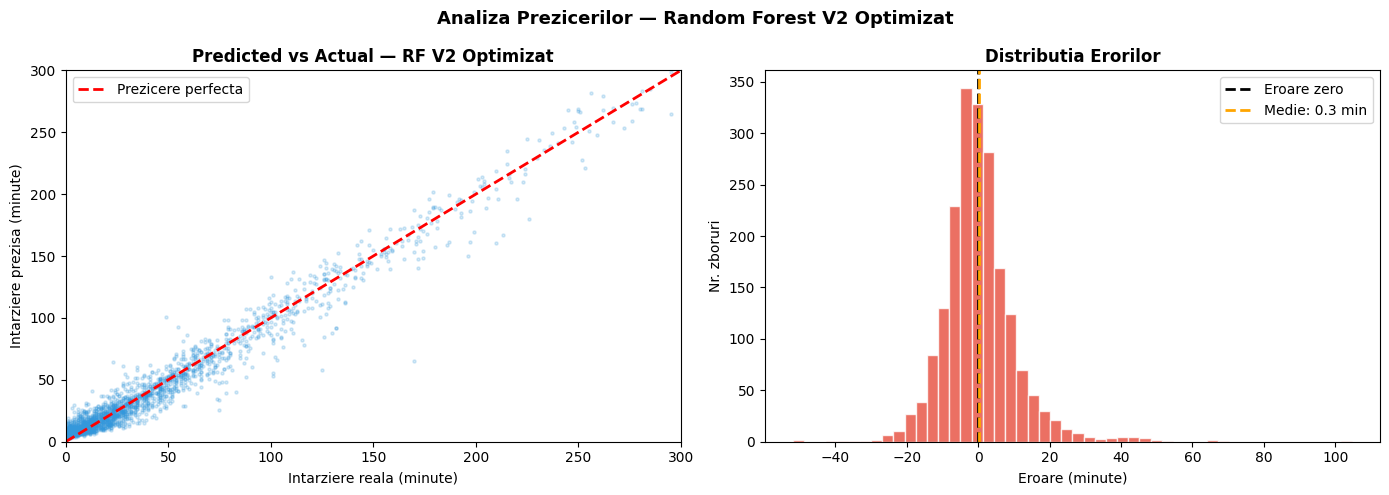

In [120]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Sample pentru vizualizare
idx = np.random.choice(len(y_te_v2), size=2000, replace=False)
y_actual = y_te_v2.iloc[idx]
y_pred   = y_pred_best_v2[idx]

# Predicted vs Actual
axes[0].scatter(y_actual, y_pred, alpha=0.2, s=5, color='#3498db')
axes[0].plot([0, 500], [0, 500], 'r--', lw=2, label='Prezicere perfecta')
axes[0].set_title('Predicted vs Actual — RF V2 Optimizat', fontweight='bold')
axes[0].set_xlabel('Intarziere reala (minute)')
axes[0].set_ylabel('Intarziere prezisa (minute)')
axes[0].legend()
axes[0].set_xlim(0, 300)
axes[0].set_ylim(0, 300)

# Distributie erori
residuals = y_actual.values - y_pred
axes[1].hist(residuals, bins=50, color='#e74c3c', edgecolor='white', alpha=0.8)
axes[1].axvline(0, color='black', lw=2, linestyle='--', label='Eroare zero')
axes[1].axvline(residuals.mean(), color='orange', lw=2,
                linestyle='--', label=f'Medie: {residuals.mean():.1f} min')
axes[1].set_title('Distributia Erorilor', fontweight='bold')
axes[1].set_xlabel('Eroare (minute)')
axes[1].set_ylabel('Nr. zboruri')
axes[1].legend()

plt.suptitle('Analiza Prezicerilor — Random Forest V2 Optimizat',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### 22.7 Residuals Analysis

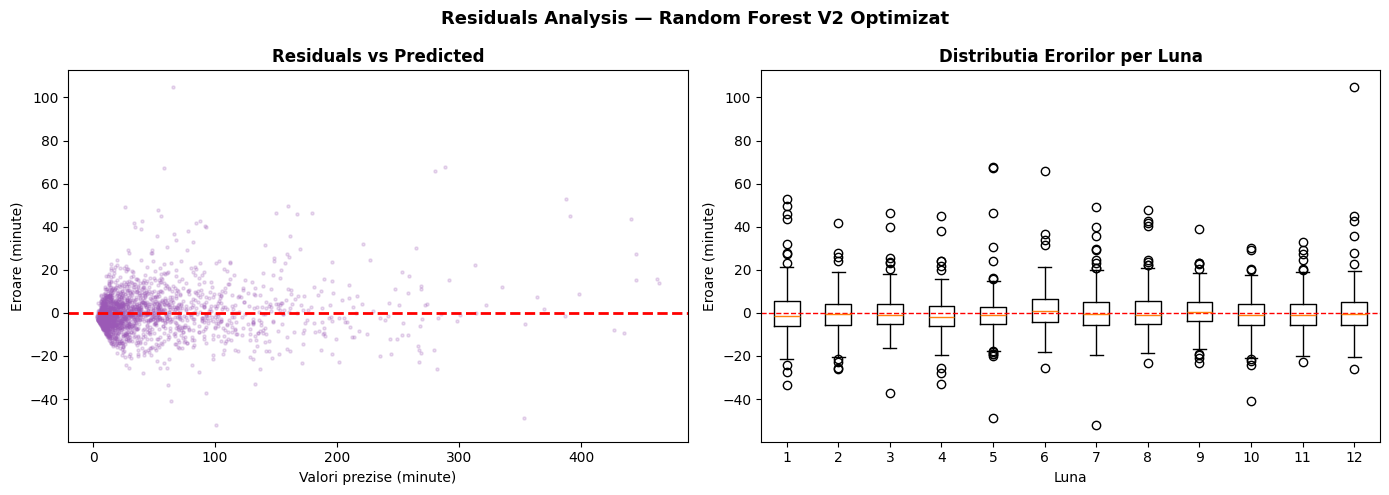

Eroare medie: 0.28 minute
Std eroare:   10.64 minute
% erori <15 min: 89.5%
% erori <30 min: 98.2%


In [121]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Residuals vs Predicted
axes[0].scatter(y_pred, residuals, alpha=0.2, s=5, color='#9b59b6')
axes[0].axhline(0, color='red', lw=2, linestyle='--')
axes[0].set_title('Residuals vs Predicted', fontweight='bold')
axes[0].set_xlabel('Valori prezise (minute)')
axes[0].set_ylabel('Eroare (minute)')

# Residuals per luna
df_residuals = pd.DataFrame({
    'residual': residuals,
    'predicted': y_pred
})
axes[1].boxplot([residuals[i::12] for i in range(12)],
                labels=[str(i+1) for i in range(12)])
axes[1].axhline(0, color='red', lw=1, linestyle='--')
axes[1].set_title('Distributia Erorilor per Luna', fontweight='bold')
axes[1].set_xlabel('Luna')
axes[1].set_ylabel('Eroare (minute)')

plt.suptitle('Residuals Analysis — Random Forest V2 Optimizat',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'Eroare medie: {residuals.mean():.2f} minute')
print(f'Std eroare:   {residuals.std():.2f} minute')
print(f'% erori <15 min: {(abs(residuals) < 15).mean()*100:.1f}%')
print(f'% erori <30 min: {(abs(residuals) < 30).mean()*100:.1f}%')

### 22.8 Cross Validation - Model Final XGBoost

In [123]:
from sklearn.model_selection import cross_val_score

print('Cross Validation — Model Final Clasificare 1 (XGBoost)...')
cv_scores_cls = cross_val_score(
    xgb, X_tr_cls, y_tr_cls,
    cv=5, scoring='f1', n_jobs=-1)

print(f'F1 per fold: {[f"{s:.3f}" for s in cv_scores_cls]}')
print(f'F1 mediu:    {cv_scores_cls.mean():.3f} ± {cv_scores_cls.std():.3f}')

print('\nCross Validation — Model Final Regresie V2 (LightGBM)...')
cv_scores_reg = cross_val_score(
    lgbm_reg_v2, X_tr_v2, y_tr_v2,
    cv=5, scoring='r2', n_jobs=-1)

print(f'R2 per fold: {[f"{s:.3f}" for s in cv_scores_reg]}')
print(f'R2 mediu:    {cv_scores_reg.mean():.3f} ± {cv_scores_reg.std():.3f}')

Cross Validation — Model Final Clasificare 1 (XGBoost)...
F1 per fold: ['0.525', '0.525', '0.524', '0.525', '0.524']
F1 mediu:    0.525 ± 0.001

Cross Validation — Model Final Regresie V2 (LightGBM)...
R2 per fold: ['0.986', '0.986', '0.986', '0.985', '0.986']
R2 mediu:    0.986 ± 0.000


## 23. Testare pe exemple

#### 23.1 Va intarzia mai mult de 15 min la aterizare?

In [61]:
zbor_cls1 = pd.DataFrame({
    'MONTH': [12], 'DAY_OF_MONTH': [20], 'DAY_OF_WEEK': [5],
    'MKT_UNIQUE_CARRIER': [le_carrier_v1.transform(['AA'])[0]],
    'ORIGIN': [le_origin_v1.transform(['ORD'])[0]],
    'DEST':   [le_dest_v1.transform(['JFK'])[0]],
    'DISTANCE': [740.0], 'ACTUAL_ELAPSED_TIME': [135.0],
    'DEP_HOUR': [17], 'ARR_HOUR': [20],
})

In [62]:
zbor_cls2_ex = pd.DataFrame({
    'MONTH': [9], 'DAY_OF_MONTH': [10], 'DAY_OF_WEEK': [2],
    'MKT_UNIQUE_CARRIER': [le_carrier_v1.transform(['AS'])[0]],
    'ORIGIN': [le_origin_v1.transform(['SEA'])[0]],
    'DEST':   [le_dest_v1.transform(['SFO'])[0]],
    'DISTANCE': [679.0], 'ACTUAL_ELAPSED_TIME': [110.0],
    'DEP_HOUR': [7], 'ARR_HOUR': [9],
})

In [63]:
zbor_cls3 = pd.DataFrame({
    'MONTH': [7], 'DAY_OF_MONTH': [5], 'DAY_OF_WEEK': [6],
    'MKT_UNIQUE_CARRIER': [le_carrier_v1.transform(['WN'])[0]],
    'ORIGIN': [le_origin_v1.transform(['DAL'])[0]],
    'DEST':   [le_dest_v1.transform(['MDW'])[0]],
    'DISTANCE': [800.0], 'ACTUAL_ELAPSED_TIME': [130.0],
    'DEP_HOUR': [18], 'ARR_HOUR': [21],
})

In [66]:
print('  CLASIFICARE 1 — VA INTARZIA >15 MIN?')
for zbor, nume in [
    (zbor_cls1, 'AA  ORD-JFK  Vineri Dec  ora 17:00 (inainte de Craciun)'),
    (zbor_cls2_ex, 'AS  SEA-SFO  Marti Sep  ora 07:00 (dimineata)'),
    (zbor_cls3, 'WN  DAL-MDW  Sambata Iul ora 18:00 (vara, weekend)'),
]:
    p_lr   = lr.predict(zbor)[0]
    p_rf   = rf.predict(zbor)[0]
    p_xgb  = xgb.predict(zbor)[0]
    p_lgbm = lgbm.predict(zbor)[0]
    votes  = p_lr + p_rf + p_xgb + p_lgbm

    print(f'\nZbor: {nume}')
    print(f'  Logistic Regression: {"INTARZIAT " if p_lr==1 else "LA TIMP "}')
    print(f'  Random Forest:       {"INTARZIAT" if p_rf==1 else "LA TIMP "}')
    print(f'  XGBoost:             {"INTARZIAT " if p_xgb==1 else "LA TIMP "}')
    print(f'  LightGBM:            {"INTARZIAT " if p_lgbm==1 else "LA TIMP "}')
    print(f'  Vot majoritar:       {"INTARZIAT " if votes>=2 else "LA TIMP "} ({votes}/4 modele)')

  CLASIFICARE 1 — VA INTARZIA >15 MIN?

Zbor: AA  ORD-JFK  Vineri Dec  ora 17:00 (inainte de Craciun)
  Logistic Regression: LA TIMP 
  Random Forest:       INTARZIAT
  XGBoost:             INTARZIAT 
  LightGBM:            INTARZIAT 
  Vot majoritar:       INTARZIAT  (3.0/4 modele)

Zbor: AS  SEA-SFO  Marti Sep  ora 07:00 (dimineata)
  Logistic Regression: LA TIMP 
  Random Forest:       LA TIMP 
  XGBoost:             LA TIMP 
  LightGBM:            LA TIMP 
  Vot majoritar:       LA TIMP  (0.0/4 modele)

Zbor: WN  DAL-MDW  Sambata Iul ora 18:00 (vara, weekend)
  Logistic Regression: LA TIMP 
  Random Forest:       INTARZIAT
  XGBoost:             INTARZIAT 
  LightGBM:            INTARZIAT 
  Vot majoritar:       INTARZIAT  (3.0/4 modele)


#### 23.1 Zborul va fi anulat

In [ ]:
cols_order = X_tr_cls2.columns.tolist()

# Exemplu 1  AA, ORD Chicago, Februarie iarna ora 08:00
# Zbor normal  probabilitate medie de anulare
zbor_ann1 = pd.DataFrame({
    'MONTH': [2], 'DAY_OF_MONTH': [15], 'DAY_OF_WEEK': [1],
    'MKT_UNIQUE_CARRIER': [le_carrier_cls2.transform(['AA'])[0]],
    'ORIGIN': [le_origin_cls2.transform(['ORD'])[0]],
    'DEST':   [le_dest_cls2.transform(['JFK'])[0]],
    'DISTANCE': [740.0], 'ACTUAL_ELAPSED_TIME': [135.0],
    'SEASON': [0], 'IS_WEEKEND': [0],
    'IS_EARLY_MORNING': [1], 'IS_LATE_NIGHT': [0],
    'PERIOD_OF_DAY': [1], 'DEP_HOUR': [8], 'ARR_HOUR': [11],
    'ROUTE_AVG_DELAY': [8.5], 'CARRIER_AVG_DELAY': [12.1],
    'AIRPORT_AVG_DELAY': [9.3], 'HOUR_AVG_DELAY': [5.2],
})[cols_order]

In [108]:
# Exemplu 2  AA, ORD Chicago, Februarie iarna ora 12:00
# Zbor cu toate semnalele de risc maxim
zbor_ann2 = pd.DataFrame({
    'MONTH': [2], 'DAY_OF_MONTH': [1], 'DAY_OF_WEEK': [1],
    'MKT_UNIQUE_CARRIER': [le_carrier_cls2.transform(['AA'])[0]],
    'ORIGIN': [le_origin_cls2.transform(['ORD'])[0]],
    'DEST':   [le_dest_cls2.transform(['JFK'])[0]],
    'DISTANCE': [740.0], 'ACTUAL_ELAPSED_TIME': [135.0],
    'SEASON': [0], 'IS_WEEKEND': [0],
    'IS_EARLY_MORNING': [0], 'IS_LATE_NIGHT': [0],
    'PERIOD_OF_DAY': [2], 'DEP_HOUR': [12], 'ARR_HOUR': [15],
    'ROUTE_AVG_DELAY': [50.0], 'CARRIER_AVG_DELAY': [50.0],
    'AIRPORT_AVG_DELAY': [50.0], 'HOUR_AVG_DELAY': [50.0],
})[cols_order]

In [ ]:
# Exemplu 3  AS, SEA Seattle, Septembrie ora 10:00
# Zbor cu risc mic de anulare
zbor_ann3 = pd.DataFrame({
    'MONTH': [9], 'DAY_OF_MONTH': [10], 'DAY_OF_WEEK': [3],
    'MKT_UNIQUE_CARRIER': [le_carrier_cls2.transform(['AS'])[0]],
    'ORIGIN': [le_origin_cls2.transform(['SEA'])[0]],
    'DEST':   [le_dest_cls2.transform(['LAX'])[0]],
    'DISTANCE': [954.0], 'ACTUAL_ELAPSED_TIME': [150.0],
    'SEASON': [3], 'IS_WEEKEND': [0],
    'IS_EARLY_MORNING': [0], 'IS_LATE_NIGHT': [0],
    'PERIOD_OF_DAY': [1], 'DEP_HOUR': [10], 'ARR_HOUR': [13],
    'ROUTE_AVG_DELAY': [3.2], 'CARRIER_AVG_DELAY': [4.8],
    'AIRPORT_AVG_DELAY': [4.1], 'HOUR_AVG_DELAY': [4.5],
})[cols_order]


In [110]:
print('  CLASIFICARE 2 — VA FI ZBORUL ANULAT?')

for zbor, nume in [
    (zbor_ann1, 'AA  ORD-JFK  Luni Feb ora 08:00 (iarna, Chicago, risc mediu)'),
    (zbor_ann2, 'AA  ORD-JFK  Luni Feb ora 12:00 (iarna, Chicago, risc maxim)'),
    (zbor_ann3, 'AS  SEA-LAX  Mier Sep ora 10:00 (toamna, Seattle, risc mic)'),
]:
    p_lr   = lr_cls2.predict(zbor)[0]
    p_rf   = rf_cls2.predict(zbor)[0]
    p_xgb  = xgb_cls2.predict(zbor)[0]
    p_lgbm = lgbm_cls2.predict(zbor)[0]
    votes  = int(p_lr) + int(p_rf) + int(p_xgb) + int(p_lgbm)

    print(f'\nZbor: {nume}')
    print(f'  Logistic Regression: {"ANULAT " if p_lr==1 else "NU E ANULAT "}')
    print(f'  Random Forest:       {"ANULAT " if p_rf==1 else "NU E ANULAT "}')
    print(f'  XGBoost:             {"ANULAT " if p_xgb==1 else "NU E ANULAT "}')
    print(f'  LightGBM:            {"ANULAT " if p_lgbm==1 else "NU E ANULAT "}')
    print(f'  Vot majoritar:       {"ANULAT " if votes>=2 else "NU E ANULAT "} ({votes}/4 modele)')

  CLASIFICARE 2 — VA FI ZBORUL ANULAT?

Zbor: AA  ORD-JFK  Luni Feb ora 08:00 (iarna, Chicago, risc mediu)
  Logistic Regression: NU E ANULAT 
  Random Forest:       NU E ANULAT 
  XGBoost:             NU E ANULAT 
  LightGBM:            NU E ANULAT 
  Vot majoritar:       NU E ANULAT  (0/4 modele)

Zbor: AA  ORD-JFK  Luni Feb ora 12:00 (iarna, Chicago, risc maxim)
  Logistic Regression: ANULAT 
  Random Forest:       NU E ANULAT 
  XGBoost:             NU E ANULAT 
  LightGBM:            NU E ANULAT 
  Vot majoritar:       NU E ANULAT  (1/4 modele)

Zbor: AS  SEA-LAX  Mier Sep ora 10:00 (toamna, Seattle, risc mic)
  Logistic Regression: NU E ANULAT 
  Random Forest:       NU E ANULAT 
  XGBoost:             NU E ANULAT 
  LightGBM:            NU E ANULAT 
  Vot majoritar:       NU E ANULAT  (0/4 modele)


#### 23.3 Cu cate minute va intarzia zborul la plecare?

In [ ]:
cols_order_v3 = list(X_tr_v3.columns)

# Exemplu 1 - American Airlines, ORD JFK, Vineri Decembrie ora 17:00
zbor_v3_1 = pd.DataFrame({
    'MONTH':               [12],
    'DAY_OF_MONTH':        [20],
    'DAY_OF_WEEK':         [5],
    'MKT_UNIQUE_CARRIER':  [le_carrier_v3.transform(['AA'])[0]],
    'ORIGIN':              [le_origin_v3.transform(['ORD'])[0]],
    'DEST':                [le_dest_v3.transform(['JFK'])[0]],
    'DISTANCE':            [740.0],
    'ACTUAL_ELAPSED_TIME': [135.0],
    'DEP_HOUR':            [17],
    'ROUTE_AVG_DELAY':     [8.5],
    'CARRIER_AVG_DELAY':   [12.1],
    'AIRPORT_AVG_DELAY':   [9.3],
    'HOUR_AVG_DELAY':      [11.2],
})[cols_order_v3]

In [ ]:
# Exemplu 2 - Alaska Airlines, SEA SFO, Marti Septembrie ora 07:00
zbor_v3_2 = pd.DataFrame({
    'MONTH':               [9],
    'DAY_OF_MONTH':        [10],
    'DAY_OF_WEEK':         [2],
    'MKT_UNIQUE_CARRIER':  [le_carrier_v3.transform(['AS'])[0]],
    'ORIGIN':              [le_origin_v3.transform(['SEA'])[0]],
    'DEST':                [le_dest_v3.transform(['SFO'])[0]],
    'DISTANCE':            [679.0],
    'ACTUAL_ELAPSED_TIME': [110.0],
    'DEP_HOUR':            [7],
    'ROUTE_AVG_DELAY':     [3.2],
    'CARRIER_AVG_DELAY':   [4.8],
    'AIRPORT_AVG_DELAY':   [4.1],
    'HOUR_AVG_DELAY':      [2.9],
})[cols_order_v3]

In [ ]:
# Exemplu 3 - Southwest Airlines, DAL PHX, Sambata Iulie ora 18:00
zbor_v3_3 = pd.DataFrame({
    'MONTH':               [7],
    'DAY_OF_MONTH':        [5],
    'DAY_OF_WEEK':         [6],
    'MKT_UNIQUE_CARRIER':  [le_carrier_v3.transform(['WN'])[0]],
    'ORIGIN':              [le_origin_v3.transform(['DAL'])[0]],
    'DEST':                [le_dest_v3.transform(['PHX'])[0]],
    'DISTANCE':            [887.0],
    'ACTUAL_ELAPSED_TIME': [145.0],
    'DEP_HOUR':            [18],
    'ROUTE_AVG_DELAY':     [4.1],
    'CARRIER_AVG_DELAY':   [6.1],
    'AIRPORT_AVG_DELAY':   [5.2],
    'HOUR_AVG_DELAY':      [9.4],
})[cols_order_v3]

In [87]:
print('  REGRESIE V3 — CU CATE MINUTE VA INTARZIA LA PLECARE?')

for zbor, nume in [
    (zbor_v3_1, 'AA  ORD-JFK  Vineri Dec  ora 17:00 (inainte de Craciun)'),
    (zbor_v3_2, 'AS  SEA-SFO  Marti Sep   ora 07:00 (dimineata)'),
    (zbor_v3_3, 'WN  DAL-PHX  Sambata Iul ora 18:00 (vara, weekend)'),
]:
    p_lr   = lin_reg_v3.predict(zbor)[0]
    p_dt   = dt_reg_v3.predict(zbor)[0]
    p_rf   = rf_reg_v3.predict(zbor)[0]
    p_xgb  = xgb_reg_v3.predict(zbor)[0]
    p_lgbm = lgbm_reg_v3.predict(zbor)[0]
    media  = (p_lr + p_dt + p_rf + p_xgb + p_lgbm) / 5

    print(f'\nZbor: {nume}')
    print(f'  Linear Regression: {max(0, p_lr):.0f} minute')
    print(f'  Decision Tree:     {max(0, p_dt):.0f} minute')
    print(f'  Random Forest:     {max(0, p_rf):.0f} minute')
    print(f'  XGBoost:           {max(0, p_xgb):.0f} minute')
    print(f'  LightGBM:          {max(0, p_lgbm):.0f} minute')
    print(f'  Media modele:      {max(0, media):.0f} minute')

  REGRESIE V3 — CU CATE MINUTE VA INTARZIA LA PLECARE?

Zbor: AA  ORD-JFK  Vineri Dec  ora 17:00 (inainte de Craciun)
  Linear Regression: 37 minute
  Decision Tree:     44 minute
  Random Forest:     44 minute
  XGBoost:           42 minute
  LightGBM:          42 minute
  Media modele:      42 minute

Zbor: AS  SEA-SFO  Marti Sep   ora 07:00 (dimineata)
  Linear Regression: 19 minute
  Decision Tree:     27 minute
  Random Forest:     38 minute
  XGBoost:           31 minute
  LightGBM:          28 minute
  Media modele:      29 minute

Zbor: WN  DAL-PHX  Sambata Iul ora 18:00 (vara, weekend)
  Linear Regression: 18 minute
  Decision Tree:     19 minute
  Random Forest:     29 minute
  XGBoost:           18 minute
  LightGBM:          18 minute
  Media modele:      20 minute


#### 23.4 Cu cate minute va intarzia zborul la sosire?

In [98]:
#Exemplu 1 — Zbor American Airlines, JFK - LAX, Luni dimineata
zbor1 = pd.DataFrame({
    'MONTH':                [1],      # ianuarie
    'DAY_OF_MONTH':         [15],
    'DAY_OF_WEEK':          [1],      # luni
    'MKT_UNIQUE_CARRIER':   [le_carrier_v2.transform(['AA'])[0]],
    'ORIGIN':               [le_origin_v2.transform(['JFK'])[0]],
    'DEST':                 [le_dest_v2.transform(['LAX'])[0]],
    'DISTANCE':             [2475.0],
    'ACTUAL_ELAPSED_TIME':  [330.0],
    'DEP_DELAY':            [45.0],   # a plecat cu 45 min intarziere
    'DEP_HOUR':             [8],
    'ARR_HOUR':             [11],
})

In [ ]:
#Exemplu 2 - Delta Airlines, ATL - ORD, Vineri seara
zbor2 = pd.DataFrame({
    'MONTH':                [6],      # iunie
    'DAY_OF_MONTH':         [20],
    'DAY_OF_WEEK':          [5],      # vineri
    'MKT_UNIQUE_CARRIER':   [le_carrier_v2.transform(['DL'])[0]],
    'ORIGIN':               [le_origin_v2.transform(['ATL'])[0]],
    'DEST':                 [le_dest_v2.transform(['ORD'])[0]],
    'DISTANCE':             [762.0],
    'ACTUAL_ELAPSED_TIME':  [130.0],
    'DEP_DELAY':            [20.0],   # a plecat cu 20 min intarziere
    'DEP_HOUR':             [18],
    'ARR_HOUR':             [20],
})

In [100]:
# Exemplu 3 - Southwest Airlines, DAL - PHX, Sambata dimineata
zbor3 = pd.DataFrame({
    'MONTH':                [9],      # septembrie
    'DAY_OF_MONTH':         [10],
    'DAY_OF_WEEK':          [6],      # sambata
    'MKT_UNIQUE_CARRIER':   [le_carrier_v2.transform(['WN'])[0]],
    'ORIGIN':               [le_origin_v2.transform(['DAL'])[0]],
    'DEST':                 [le_dest_v2.transform(['PHX'])[0]],
    'DISTANCE':             [887.0],
    'ACTUAL_ELAPSED_TIME':  [145.0],
    'DEP_DELAY':            [0.0],    # a plecat la timp
    'DEP_HOUR':             [7],
    'ARR_HOUR':             [9],
})

In [102]:

for zbor, nume, dep_delay in [
    (zbor1, 'AA  JFK - LAX  Luni Ian  ora 08:00', 45),
    (zbor2, 'DL  ATL - ORD  Vineri Iun ora 18:00', 20),
    (zbor3, 'WN  DAL - PHX  Sambata Sep ora 07:00', 0),
]:
    pred_lr   = lin_reg_v2.predict(zbor)[0]
    pred_dt   = dt_reg_v2.predict(zbor)[0]
    pred_rf   = rf_reg_v2.predict(zbor)[0]
    pred_xgb  = xgb_reg_v2.predict(zbor)[0]
    pred_lgbm = lgbm_reg_v2.predict(zbor)[0]

    print(f'\nZbor: {nume}')
    print(f'Intarziere la plecare: {dep_delay} minute')
    print(f'  Linear Regression: {pred_lr:.0f} minute')
    print(f'  Decision Tree:     {pred_dt:.0f} minute')
    print(f'  Random Forest:     {pred_rf:.0f} minute')
    print(f'  XGBoost:           {pred_xgb:.0f} minute')
    print(f'  LightGBM:          {pred_lgbm:.0f} minute')
    print(f'  Media modele:      {(pred_lr+pred_dt+pred_rf+pred_xgb+pred_lgbm)/5:.0f} minute')


Zbor: AA  JFK - LAX  Luni Ian  ora 08:00
Intarziere la plecare: 45 minute
  Linear Regression: 35 minute
  Decision Tree:     39 minute
  Random Forest:     29 minute
  XGBoost:           27 minute
  LightGBM:          26 minute
  Media modele:      31 minute

Zbor: DL  ATL - ORD  Vineri Iun ora 18:00
Intarziere la plecare: 20 minute
  Linear Regression: 13 minute
  Decision Tree:     12 minute
  Random Forest:     12 minute
  XGBoost:           12 minute
  LightGBM:          11 minute
  Media modele:      12 minute

Zbor: WN  DAL - PHX  Sambata Sep ora 07:00
Intarziere la plecare: 0 minute
  Linear Regression: -4 minute
  Decision Tree:     9 minute
  Random Forest:     6 minute
  XGBoost:           5 minute
  LightGBM:          6 minute
  Media modele:      4 minute


## 21. Argumente pentru Experimente

### De ce am ales aceste intrebari?

Am formulat 4 intrebari distincte pentru a acoperi scenarii reale diferite:

**Intrebarea 1 — Clasificare 1: Va intarzia zborul >15 min?**
Utila pentru pasageri inainte de zbor — vor sa stie daca trebuie
sa isi planifice timp suplimentar la destinatie.
Am ales pragul de 15 minute pentru ca acesta este standardul
oficial BTS pentru a defini un zbor intarziat.

**Intrebarea 2 — Clasificare 2: Va fi zborul anulat?**
Utila pentru pasageri inainte de zbor — o anulare e mult mai
grava decat o intarziere si necesita replanning complet.
Modelul detecteaza 87.68% din anulari cu Random Forest.

**Intrebarea 3 — Regresie V3: Cu cate minute va intarzia la plecare?**
Utila pentru planificare anticipata — pasagerul nu a plecat inca
si vrea o estimare a intarzierii la plecare bazata pe informatii
cunoscute dinainte (companie, aeroport, ora, zi, luna, distanta,
historical averages).
R2 scazut (~8%) demonstreaza ca fara date meteo, prezicerea
minutelor exacte inainte de zbor este dificila dar nu imposibila.

**Intrebarea 4 — Regresie V2: Cu cate minute va intarzia la sosire?**
Utila dupa ce zborul a plecat — pasagerul stie deja intarzierea
la plecare si vrea sa stie cu cat va sosi intarziat.
R2=98.62% demonstreaza ca DEP_DELAY e un predictor exceptional
pentru ARR_DELAY.

---

### De ce am ales aceste modele?

**Logistic Regression**
Ales ca baseline simplu pentru clasificare. Model liniar rapid
si usor de interpretat. Confirma ca relatia dintre features si
intarziere nu e liniara — Recall=18% arata limitele unui model
simplu pe date dezechilibrate.

**Decision Tree**
Ales pentru comparatie directa cu Random Forest. Arata impactul
folosirii unui singur arbore vs o padure de arbori. Demonstreaza
overfitting — performanta pe train mai mare decat pe test.

**Random Forest**
Ales pentru ca gestioneaza bine class imbalance prin
class_weight='balanced_subsample'. Imbunatatire semnificativa
fata de Logistic Regression — Recall creste de la 18% la 53%.
Cel mai bun model pentru clasificarea anularilor cu F1=87.68%.

**XGBoost**
Ales pentru ca e unul dintre cele mai performante algoritme
pentru date tabelare. Foloseste scale_pos_weight pentru
dezechilibrul dintre clase. Cel mai bun model pentru
clasificarea intarzierilor cu F1=52.46% si Recall=66.85%.

**LightGBM**
Ales pentru ca e cel mai rapid algoritm pe dataset-uri mari
(7.7M randuri). Cel mai bun model pentru regresie V2 cu
R2=98.62% si MAE=5.71 minute.

---

### De ce aceste features?

Am ales coloanele cunoscute INAINTE de zbor pentru clasificare si V3:
- MONTH, DAY_OF_MONTH, DAY_OF_WEEK — patterns temporale
- MKT_UNIQUE_CARRIER — compania influenteaza punctualitatea
- ORIGIN, DEST — aeroporturile au niveluri diferite de aglomeratie
- CRS_DEP_TIME, CRS_ARR_TIME — ora zilei influenteaza intarzierile
- DISTANCE, ACTUAL_ELAPSED_TIME — caracteristici ale rutei
- SEASON — patterns sezoniere (iarna = mai multe intarzieri)
- ROUTE_AVG_DELAY, CARRIER_AVG_DELAY, AIRPORT_AVG_DELAY,
  HOUR_AVG_DELAY — medii istorice care imbunatatesc R2 cu 2-3%

Am exclus IS_WEEKEND, IS_EARLY_MORNING, IS_LATE_NIGHT si
PERIOD_OF_DAY dupa analiza Feature Importance — importanta
aproape zero, nu contribuie la performanta modelului.

Am exclus coloanele cunoscute doar DUPA zbor (CARRIER_DELAY,
WEATHER_DELAY etc.) pentru a simula un scenariu real de
prezicere inainte de zbor.

Pentru V2 am adaugat DEP_DELAY pentru a simula scenariul in
care zborul a plecat deja si vrem sa prezice sosirea.

---

### De ce RandomizedSearchCV si nu GridSearchCV?

GridSearchCV cu 4 parametri si 4 valori fiecare = 256 combinatii
x 5 folduri = 1280 antrenari — prea lent pe milioane de randuri.

RandomizedSearchCV cu n_iter=10 = doar 50 antrenari — de 25x
mai rapid cu rezultate comparabile. Literatura de specialitate
(Bergstra & Bengio, 2012) demonstreaza ca cautarea random e
la fel de eficienta ca cea exhaustiva pentru optimizarea
hiperparametrilor.

---

### De ce antrenare pe tot datasetul la clasificare?

Clasificarea a fost antrenata pe tot datasetul de 7.7 milioane
randuri (6,077,996 train / 1,519,499 test) pentru a asigura
ca modelele au invatat din toate patterns-urile disponibile —
toate cele 12 luni, toate cele 10 companii si toate cele 364
aeroporturi. Distributia claselor (22% intarziate) se pastreaza
prin stratify=y.

Pentru regresie am folosit sample de 200k din cauza timpului
de antrenare — Random Forest si XGBoost pe milioane de randuri
cu target continuu dureaza semnificativ mai mult decat clasificarea.

## 22. Comparatie cu Literatura